In [64]:
# Stock Price Prediction System - Phase 1
# Binary Classification for Stock Movement Prediction

# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

# Machine Learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Cell: Import Additional Model Libraries
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator

# Suppress warnings
warnings.filterwarnings('ignore')

# Set styling for plots
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Display all columns
pd.set_option('display.max_columns', None)


In [12]:
# Cell 2: Data Loading Function (Run this cell if you need to download new data)
import yfinance as yf

def download_stock_data(ticker, start_date, end_date, save_path=None):
    """
    Download stock data using yfinance library
    
    Parameters:
    -----------
    ticker : str
        Stock ticker symbol (e.g., 'AAPL')
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    save_path : str, optional
        Path to save the CSV file
        
    Returns:
    --------
    pandas.DataFrame
        Stock price data
    """
    print(f"Downloading {ticker} data from {start_date} to {end_date}...")
    data = yf.download(ticker, start=start_date, end=end_date)
    
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        data.to_csv(save_path)
        print(f"Data saved to {save_path}")
    
    return data

# Example usage (uncomment to run)
ticker = 'AAPL'  # Apple stock
start_date = '2018-01-01'
end_date = '2025-03-24'
stock_data = download_stock_data(ticker, start_date, end_date, save_path='data/stock_data.csv')

[*********************100%***********************]  1 of 1 completed

Data saved to data/stock_data.csv


In [20]:
# Cell 3: Load and Examine the Data
# Load data from CSV (replace with your file path)
def load_data(file_path):
    """Load stock data from CSV file"""
    print(f"Loading data from {file_path}")
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    print(f"Loaded data shape: {df.shape}")
    return df

# Example: Load data
df = load_data('data/stock_data.csv')

# Alternatively, if you don't have a CSV file yet:
# ticker = 'AAPL'
# df = yf.download(ticker, start='2018-01-01', end='2023-01-01')

# Display the first few rows
print(df.head())

Loading data from data/stock_data.csv
Loaded data shape: (1817, 5)
                        Close                High                Low  \
Price                                                                  
Ticker                   AAPL                AAPL               AAPL   
Date                      NaN                 NaN                NaN   
2018-01-02  40.47984313964844   40.48924485609061  39.77486500606255   
2018-01-03   40.4727897644043   41.01797452323995  40.40934432017212   
2018-01-04  40.66078186035156  40.764179210026526  40.43753953848259   

                          Open     Volume  
Price                                      
Ticker                    AAPL       AAPL  
Date                       NaN        NaN  
2018-01-02   39.98636059756084  102223600  
2018-01-03   40.54328828814392  118071600  
2018-01-04  40.545634159903784   89738400  


In [30]:
# Cell: Load Stock Data
import yfinance as yf
import pandas as pd

# Define parameters
ticker = "AAPL"
start_date = "2018-01-01"
end_date = "2025-03-24"

# Download data directly from yfinance
print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date)
print(f"Downloaded data shape: {df.shape}")

# Cell: Clean Data
def clean_data(df):
    """Clean the data by handling missing values and outliers"""
    print("Cleaning data...")
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print(f"Missing values before cleaning:\n{missing_values}")
    
    # Forward-fill small missing values
    df.fillna(method='ffill', inplace=True)
    
    # Check if any missing values remain
    remaining_missing = df.isnull().sum().sum()
    if remaining_missing > 0:
        print(f"Warning: {remaining_missing} missing values remain after forward-fill")
    
    # Remove outliers
    if 'Volume' in df.columns:
        # No need to convert - yfinance data is already numeric
        volume_mean = df['Volume'].mean()
        volume_std = df['Volume'].std()
        outlier_threshold = volume_mean + 5 * volume_std
        outliers = df[df['Volume'] > outlier_threshold]
        if not outliers.empty:
            print(f"Removing {len(outliers)} volume outliers")
            df = df[df['Volume'] <= outlier_threshold]
    
    print(f"Data shape after cleaning: {df.shape}")
    return df

# Clean the data
df_cleaned = clean_data(df)

# Display the first few rows
print("\nCleaned Data Head:")
print(df_cleaned.head())

[*********************100%***********************]  1 of 1 completed

Downloaded data shape: (1815, 5)
Cleaning data...
Missing values before cleaning:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
Removing 1815 volume outliers
Data shape after cleaning: (1815, 5)

Cleaned Data Head:
Price           Close       High        Low       Open       Volume
Ticker           AAPL       AAPL       AAPL       AAPL         AAPL
Date                                                               
2018-01-02  40.479843  40.489245  39.774865  39.986361  102223600.0
2018-01-03  40.472790  41.017975  40.409344  40.543288  118071600.0
2018-01-04  40.660782  40.764179  40.437540  40.545634   89738400.0
2018-01-05  41.123722  41.210668  40.665487  40.757134   94640000.0
2018-01-08  40.970970  41.267060  40.872270  40.970970   82271200.0


In [36]:
# Cell 5: Exploratory Data Analysis
def plot_stock_data(df, ticker="Stock"):
    """Plot stock price and volume data"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Plot stock price
    ax1.plot(df.index, df['Close'], label='Close Price')
    ax1.set_title(f'{ticker} Stock Price', fontsize=15)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.grid(True)
    ax1.legend()
    
    # Plot volume
    ax2.bar(df.index, df['Volume'], label='Volume')
    ax2.set_title(f'{ticker} Trading Volume', fontsize=15)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Volume', fontsize=12)
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed

Downloaded data shape: (1259, 5)
Detected multi-level columns, flattening structure...
Cleaning data...
Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Removing 3 volume outliers
Data shape after cleaning: (1256, 5)
DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume']
DataFrame shape: (1256, 5)


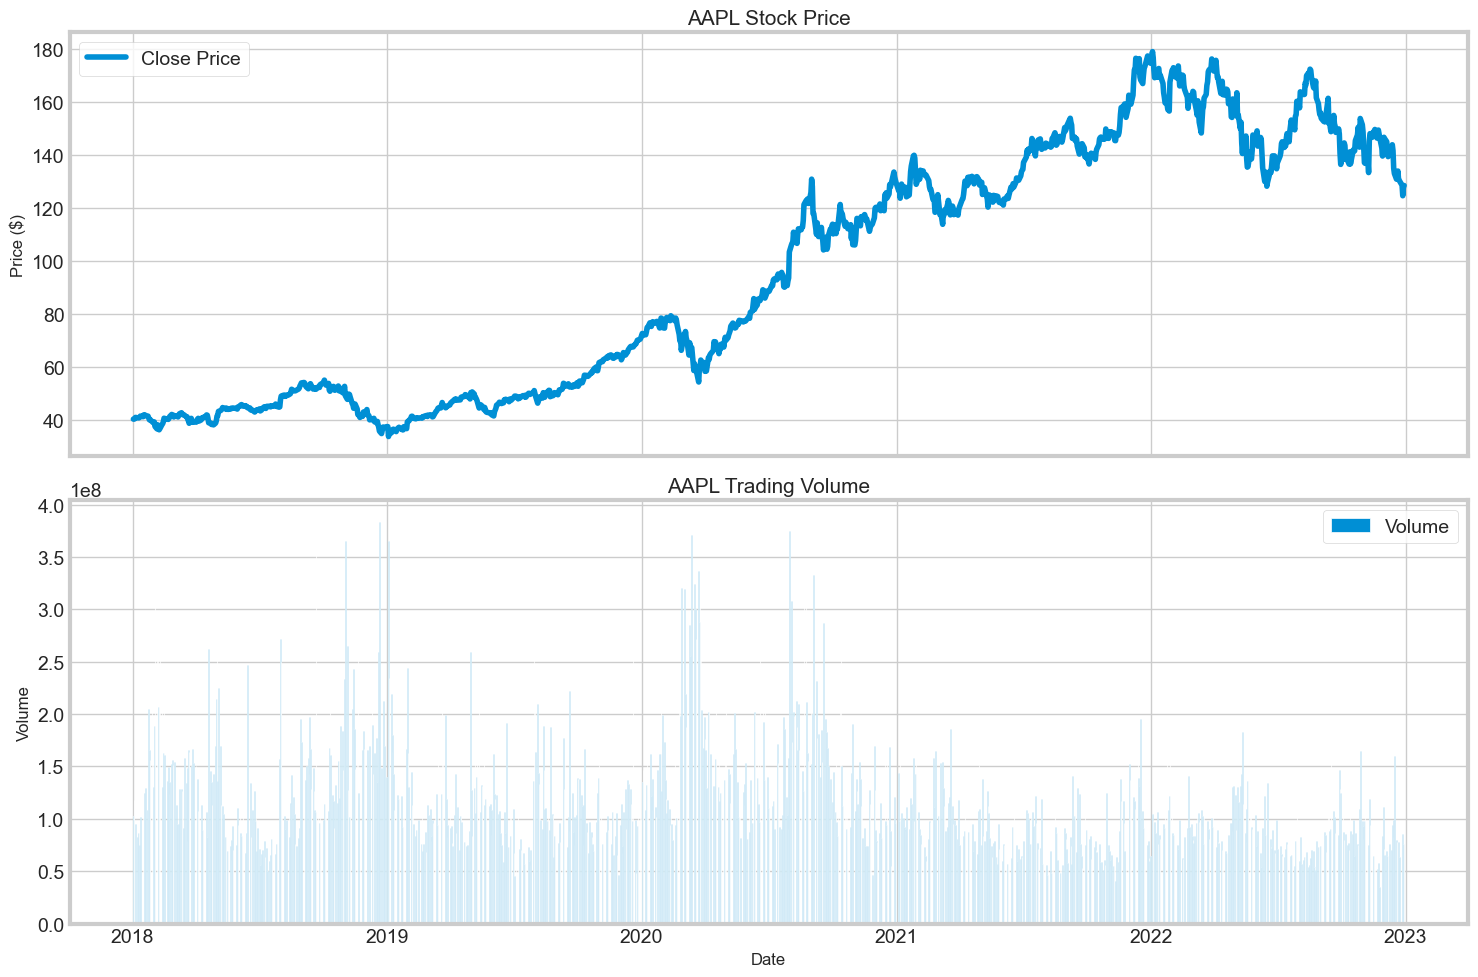

In [42]:
# Cell: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set styling for plots
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Cell: Load and Clean Stock Data
def load_stock_data(ticker, start_date, end_date):
    """Load stock data directly from yfinance"""
    print(f"Downloading {ticker} data from {start_date} to {end_date}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=True)
    print(f"Downloaded data shape: {df.shape}")
    
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Detected multi-level columns, flattening structure...")
        # If it's a multi-level columns dataframe, flatten it
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    return df

def clean_data(df):
    """Clean the data by handling missing values and outliers"""
    print("Cleaning data...")
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print(f"Missing values before cleaning:\n{missing_values}")
    
    # Forward-fill small missing values
    df.fillna(method='ffill', inplace=True)
    
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Flattening multi-level columns...")
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    # Remove outliers
    if 'Volume' in df.columns:
        try:
            volume_mean = df['Volume'].mean()
            volume_std = df['Volume'].std()
            outlier_threshold = volume_mean + 5 * volume_std
            outliers = df[df['Volume'] > outlier_threshold]
            if not outliers.empty:
                print(f"Removing {len(outliers)} volume outliers")
                df = df[df['Volume'] <= outlier_threshold]
        except Exception as e:
            print(f"Error processing Volume column: {e}")
            print("Skipping outlier removal")
    
    print(f"Data shape after cleaning: {df.shape}")
    return df

# Cell: Plot Stock Data
def plot_stock_data(df, ticker="Stock"):
    """Plot stock price and volume data"""
    # Check for multi-level columns and flatten if needed
    if isinstance(df.columns, pd.MultiIndex):
        print("Flattening multi-level columns before plotting...")
        df = df.copy()
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    
    # Ensure all required columns exist
    required_cols = ['Close', 'Volume']
    for col in required_cols:
        if col not in df.columns:
            print(f"Error: '{col}' column not found in data")
            return
    
    # Print column info for debugging
    print(f"DataFrame columns: {df.columns.tolist()}")
    print(f"DataFrame shape: {df.shape}")
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Plot stock price
    ax1.plot(df.index, df['Close'], label='Close Price')
    ax1.set_title(f'{ticker} Stock Price', fontsize=15)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.grid(True)
    ax1.legend()
    
    # Plot volume
    ax2.bar(df.index, df['Volume'], label='Volume')
    ax2.set_title(f'{ticker} Trading Volume', fontsize=15)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Volume', fontsize=12)
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage

# Load and clean data
ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2023-01-01'
df = load_stock_data(ticker, start_date, end_date)
df_cleaned = clean_data(df)

# Plot the cleaned data
plot_stock_data(df_cleaned, ticker=ticker)


In [46]:
# Cell 6: Feature Engineering - Technical Indicators
def calculate_moving_averages(df, windows=[5, 10, 20, 50, 200]):
    """Calculate simple moving averages"""
    for window in windows:
        df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()
    return df

def calculate_exponential_moving_averages(df, windows=[5, 10, 20, 50, 200]):
    """Calculate exponential moving averages"""
    for window in windows:
        df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
    return df

def calculate_returns(df, periods=[1, 5, 10, 20]):
    """Calculate returns over different periods"""
    for period in periods:
        df[f'Return_{period}d'] = df['Close'].pct_change(periods=period)
    return df

def calculate_rsi(df, window=14):
    """Calculate Relative Strength Index"""
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

def calculate_macd(df, fast=12, slow=26, signal=9):
    """Calculate MACD (Moving Average Convergence Divergence)"""
    ema_fast = df['Close'].ewm(span=fast, adjust=False).mean()
    ema_slow = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = ema_fast - ema_slow
    df['MACD_Signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    return df

def calculate_bollinger_bands(df, window=20, std_dev=2):
    """Calculate Bollinger Bands"""
    df['BB_Middle'] = df['Close'].rolling(window=window).mean()
    df['BB_Width'] = (df['Close'].rolling(window=window).std() * std_dev)
    df['BB_Upper'] = df['BB_Middle'] + df['BB_Width']
    df['BB_Lower'] = df['BB_Middle'] - df['BB_Width']
    return df

def calculate_price_volume_features(df):
    """Calculate price/volume-based features"""
    # Price change
    df['Price_Change'] = df['Close'] - df['Open']
    df['Price_Change_Pct'] = df['Price_Change'] / df['Open'] * 100
    
    # High-Low range
    df['HL_Range'] = df['High'] - df['Low']
    df['HL_Range_Pct'] = df['HL_Range'] / df['Open'] * 100
    
    # Volume features
    if 'Volume' in df.columns:
        df['Volume_Change'] = df['Volume'].pct_change()
        df['Volume_MA_5'] = df['Volume'].rolling(window=5).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_5']
    
    return df

# Cell 7: Define Target Variable
def define_target(df):
    """Define the binary target: 1 if next day's close is higher than today's, 0 otherwise"""
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    return df

# Cell 8: Create All Features and Target
def create_all_features(df):
    """Create all technical features and define target"""
    print("Generating technical features...")
    
    # Price-based indicators
    df = calculate_moving_averages(df)
    df = calculate_exponential_moving_averages(df)
    df = calculate_returns(df)
    df = calculate_rsi(df)
    df = calculate_macd(df)
    df = calculate_bollinger_bands(df)
    df = calculate_price_volume_features(df)
    
    # Define the target variable
    df = define_target(df)
    
    # Remove rows with NaN values (which occur at the beginning due to rolling calculations)
    df_cleaned = df.dropna()
    print(f"Dropped {len(df) - len(df_cleaned)} rows with NaN values")
    print(f"Final dataset shape: {df_cleaned.shape}")
    
    return df_cleaned

# Generate all features
df_features = create_all_features(df_cleaned)

# Display the first few rows with all features
df_features.head()

Generating technical features...
Dropped 199 rows with NaN values
Final dataset shape: (1557, 35)


,Close,High,Low,Open,Volume,MA_5,MA_10,MA_20,MA_50,MA_200,EMA_5,EMA_10,EMA_20,EMA_50,EMA_200,Return_1d,Return_5d,Return_10d,Return_20d,RSI,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_Width,BB_Upper,BB_Lower,Price_Change,Price_Change_Pct,HL_Range,HL_Range_Pct,Volume_Change,Volume_MA_5,Volume_Ratio,Target
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-17,52.5749,52.9196,52.1352,52.8388,91541600,52.1618,52.6852,52.9771,52.2242,44.8632,52.4602,52.6344,52.7368,51.6223,46.4817,-0.0043,0.0223,-0.0469,0.0135,46.1710,0.0620,0.2862,-0.2241,52.9771,2.1517,55.1289,50.8254,-0.2638,-0.4993,0.7844,1.4845,-0.2158,141058160.0000,0.6490,0
2018-10-18,51.3461,52.2303,50.6282,51.7834,130325200,52.2365,52.4007,52.9492,52.2700,44.9175,52.0889,52.4002,52.6044,51.6114,46.5301,-0.0234,0.0073,-0.0525,-0.0108,40.9125,-0.0497,0.2190,-0.2687,52.9492,2.2236,55.1728,50.7255,-0.4374,-0.8446,1.6020,3.0937,0.4237,124623680.0000,1.0457,1
2018-10-19,52.1281,52.5916,51.6812,51.8310,132314800,52.1034,52.2823,52.9406,52.3308,44.9758,52.1019,52.3507,52.5590,51.6317,46.5858,0.0152,-0.0126,-0.0222,-0.0033,42.8055,-0.0743,0.1604,-0.2347,52.9406,2.2355,55.1761,50.7052,0.2971,0.5732,0.9104,1.7564,0.0153,118816320.0000,1.1136,1
2018-10-22,52.4466,53.0907,52.0401,52.2422,115168400,52.2598,52.2082,52.9390,52.3902,45.0347,52.2168,52.3681,52.5483,51.6636,46.6442,0.0061,0.0151,-0.0139,-0.0006,42.0927,-0.0673,0.1148,-0.1821,52.9390,2.2370,55.1759,50.7020,0.2044,0.3913,1.0506,2.0110,-0.1296,117217200.0000,0.9825,1
2018-10-23,52.9410,53.0646,51.0323,51.3009,155071200,52.2873,52.1098,52.9454,52.4625,45.0938,52.4582,52.4723,52.5857,51.7137,46.7068,0.0094,0.0026,-0.0182,0.0024,41.3293,-0.0216,0.0875,-0.1092,52.9454,2.2362,55.1815,50.7092,1.6401,3.1970,2.0323,3.9615,0.3465,124884240.0000,1.2417,0


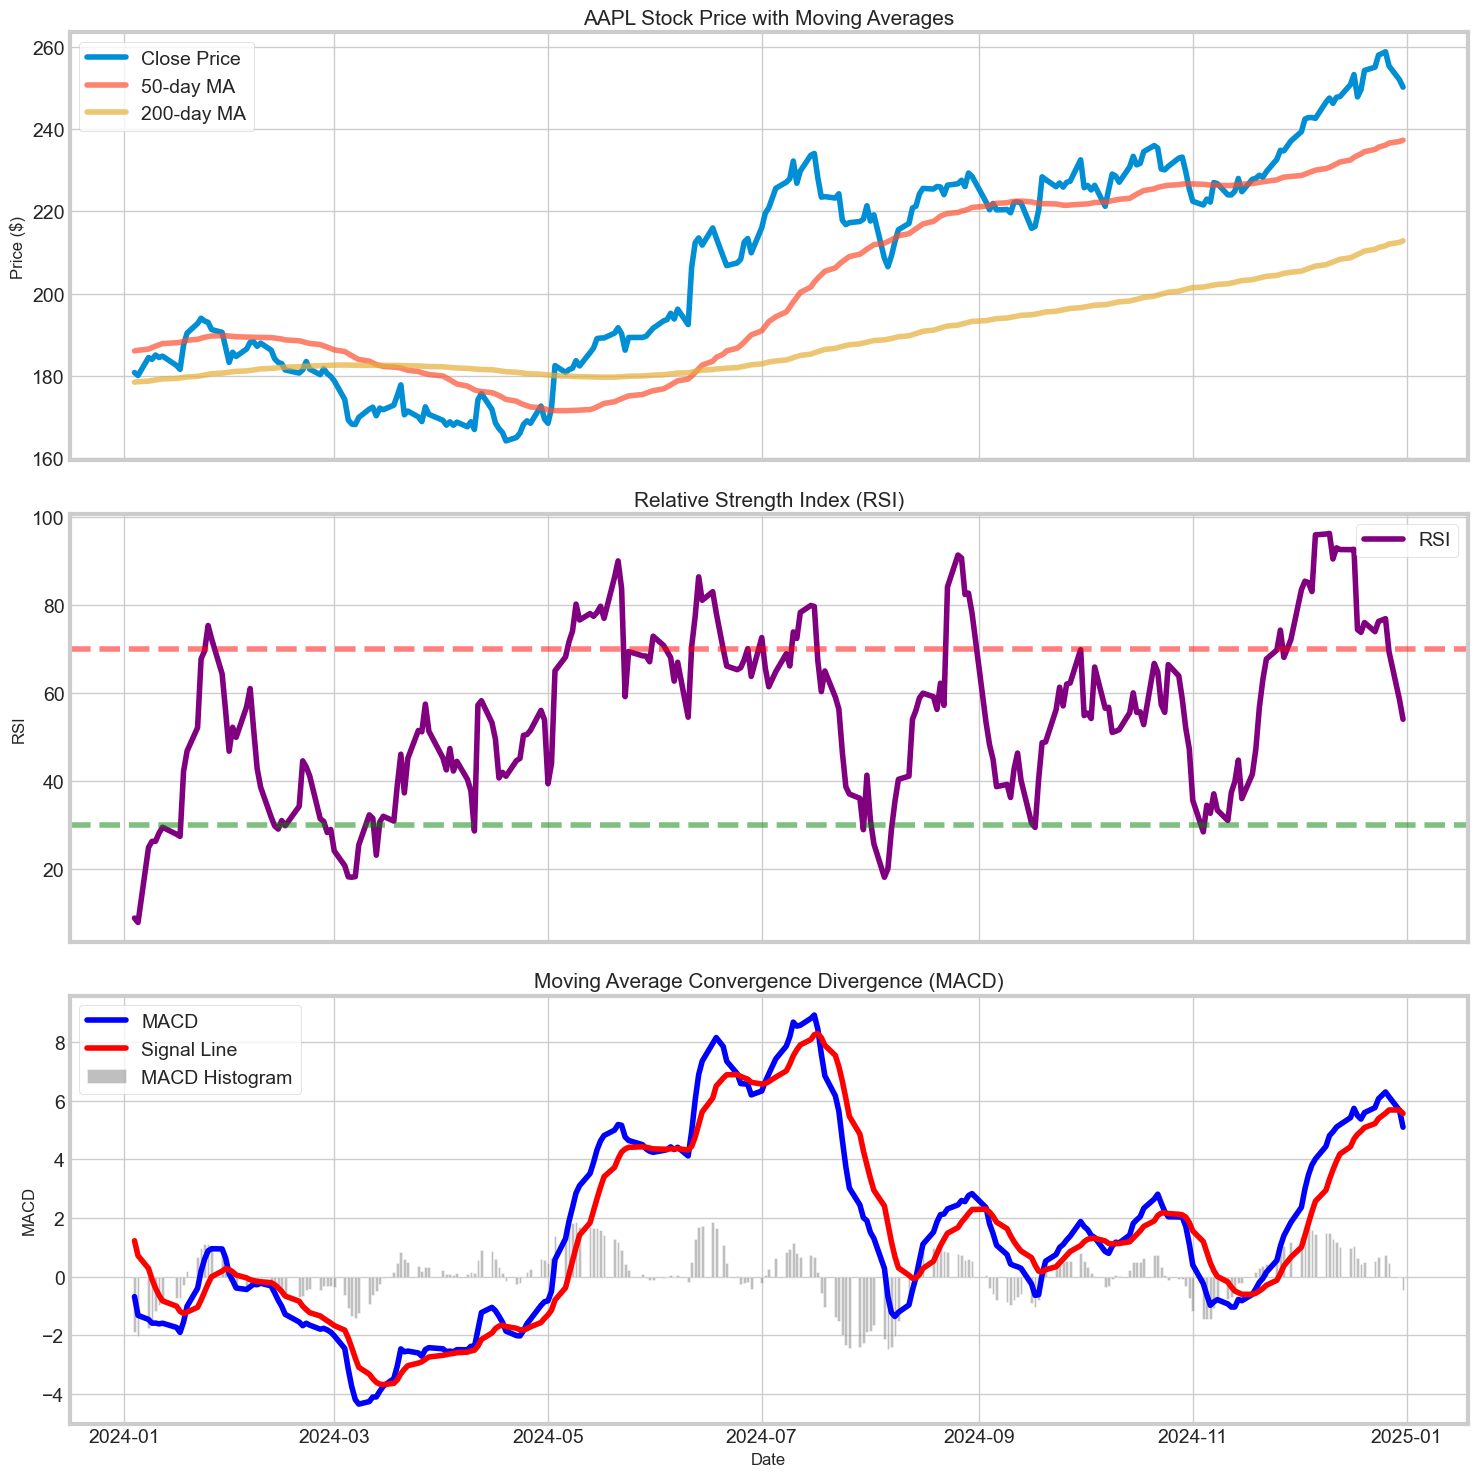

In [48]:
# Cell 9: Visualize Technical Indicators
def plot_technical_indicators(df, window=250, ticker="Stock"):
    """Plot some key technical indicators"""
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 15), sharex=True)
    
    # Check what data is available
    required_columns = ['Close', 'MA_50', 'MA_200', 'RSI', 'MACD', 'MACD_Signal']
    for col in required_columns:
        if col not in df.columns:
            print(f"Warning: {col} not found in data, skipping technical indicator plot")
            return
    
    # Use last 'window' days of data
    df_window = df.iloc[-window:].copy()
    
    # Plot stock price with moving averages
    ax1.plot(df_window.index, df_window['Close'], label='Close Price')
    ax1.plot(df_window.index, df_window['MA_50'], label='50-day MA', alpha=0.7)
    ax1.plot(df_window.index, df_window['MA_200'], label='200-day MA', alpha=0.7)
    ax1.set_title(f'{ticker} Stock Price with Moving Averages', fontsize=15)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.grid(True)
    ax1.legend()
    
    # Plot RSI
    ax2.plot(df_window.index, df_window['RSI'], color='purple', label='RSI')
    ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5)
    ax2.set_title('Relative Strength Index (RSI)', fontsize=15)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.grid(True)
    ax2.legend()
    
    # Plot MACD
    ax3.plot(df_window.index, df_window['MACD'], label='MACD', color='blue')
    ax3.plot(df_window.index, df_window['MACD_Signal'], label='Signal Line', color='red')
    ax3.bar(df_window.index, df_window['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.5)
    ax3.set_title('Moving Average Convergence Divergence (MACD)', fontsize=15)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.grid(True)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_technical_indicators(df_features, window=250, ticker="AAPL")

Target Distribution:
0 (Down): 718 samples (46.11%)
1 (Up): 839 samples (53.89%)


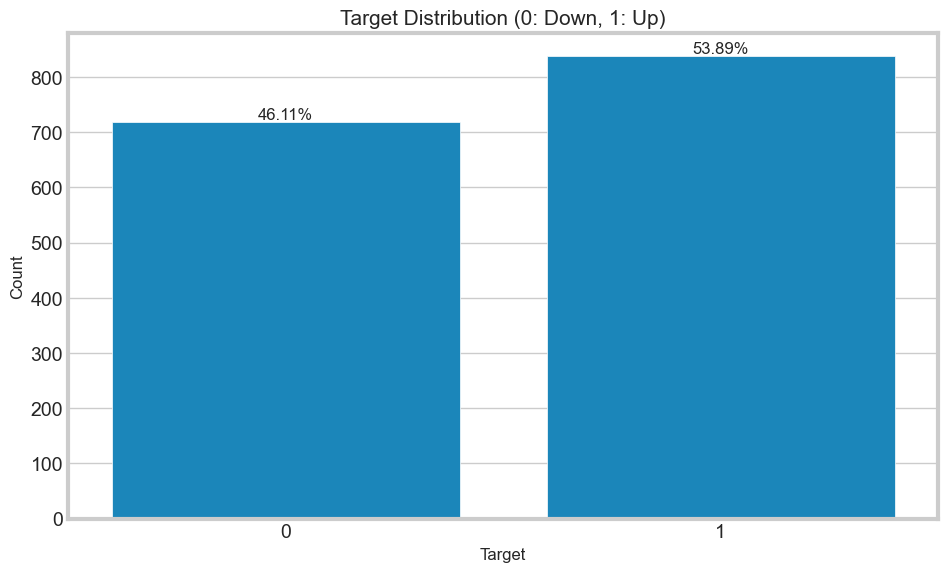

In [50]:
# Cell 10: Analyze Target Distribution
def analyze_target_distribution(df):
    """Analyze the distribution of the target variable"""
    target_counts = df['Target'].value_counts()
    target_pct = df['Target'].value_counts(normalize=True) * 100
    
    print("Target Distribution:")
    print(f"0 (Down): {target_counts[0]} samples ({target_pct[0]:.2f}%)")
    print(f"1 (Up): {target_counts[1]} samples ({target_pct[1]:.2f}%)")
    
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='Target', data=df)
    plt.title('Target Distribution (0: Down, 1: Up)', fontsize=15)
    plt.xlabel('Target', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add percentage labels
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 5,
                f'{target_pct[i]:.2f}%',
                ha="center", fontsize=12)
    
    plt.grid(True, axis='y')
    plt.show()

# Example usage
analyze_target_distribution(df_features)

In [52]:
# Cell 11: Prepare Data for Modeling
def prepare_data(df, feature_cols=None, target_col='Target', test_size=0.2):
    """Prepare data for modeling with chronological train-test split"""
    if feature_cols is None:
        # Use all columns except 'Target' and 'Close' (to avoid data leakage)
        feature_cols = [col for col in df.columns if col not in ['Target', 'Close']]
    
    # Make sure we have all required columns
    for col in feature_cols + [target_col]:
        if col not in df.columns:
            raise ValueError(f"Column {col} not found in the dataset")
    
    # Split data chronologically
    split_idx = int(len(df) * (1 - test_size))
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]
    
    print(f"Train set: {len(train_df)} samples ({train_df.index[0]} to {train_df.index[-1]})")
    print(f"Test set: {len(test_df)} samples ({test_df.index[0]} to {test_df.index[-1]})")
    
    # Extract features and target
    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].values
    X_test = test_df[feature_cols].values
    y_test = test_df[target_col].values
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, y_train, X_test_scaled, y_test, scaler, test_df, feature_cols

# Define feature columns - you can customize this list
selected_features = [
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'EMA_5', 'EMA_10', 'EMA_20',
    'Return_1d', 'Return_5d',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width',
    'HL_Range_Pct', 'Price_Change_Pct',
    'Volume_Ratio'
]

# Prepare data for modeling
X_train, y_train, X_test, y_test, scaler, test_df, feature_cols = prepare_data(
    df_features, feature_cols=selected_features
)

# Cell 12: Train Logistic Regression Model
def train_logistic_regression(X_train, y_train, C=1.0, max_iter=1000):
    """Train a logistic regression model"""
    print("Training Logistic Regression model...")
    model = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': np.abs(model.coef_[0])
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Train logistic regression model
lr_model, lr_feature_importance = train_logistic_regression(X_train, y_train)

# Display feature importance
print("Top 10 Important Features (Logistic Regression):")
lr_feature_importance.head(10)


Train set: 1245 samples (2018-10-17 00:00:00 to 2023-10-04 00:00:00)
Test set: 312 samples (2023-10-05 00:00:00 to 2024-12-31 00:00:00)
Training Logistic Regression model...
Top 10 Important Features (Logistic Regression):


,Feature,Importance
0,MA_5,0.1771
9,RSI,0.1766
7,Return_1d,0.1531
11,MACD_Signal,0.0892
10,MACD,0.0888
4,EMA_5,0.0860
13,BB_Width,0.0790
8,Return_5d,0.0773
3,MA_50,0.0684
14,HL_Range_Pct,0.0632


In [54]:
# Cell 13: Train Random Forest Model
def train_random_forest(X_train, y_train, n_estimators=100, max_depth=5):
    """Train a random forest model"""
    print("Training Random Forest model...")
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Train random forest model
rf_model, rf_feature_importance = train_random_forest(X_train, y_train)

# Display feature importance
print("Top 10 Important Features (Random Forest):")
rf_feature_importance.head(10)

Training Random Forest model...
Top 10 Important Features (Random Forest):


,Feature,Importance
16,Volume_Ratio,0.0922
7,Return_1d,0.0856
13,BB_Width,0.0836
15,Price_Change_Pct,0.0813
9,RSI,0.0667
8,Return_5d,0.0629
10,MACD,0.0621
3,MA_50,0.0579
11,MACD_Signal,0.0559
14,HL_Range_Pct,0.0551



Evaluating Logistic Regression...
Accuracy: 0.4679
F1 Score: 0.5489
Confusion Matrix:
[[ 45  93]
 [ 73 101]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.33      0.35       138
           1       0.52      0.58      0.55       174

    accuracy                           0.47       312
   macro avg       0.45      0.45      0.45       312
weighted avg       0.46      0.47      0.46       312



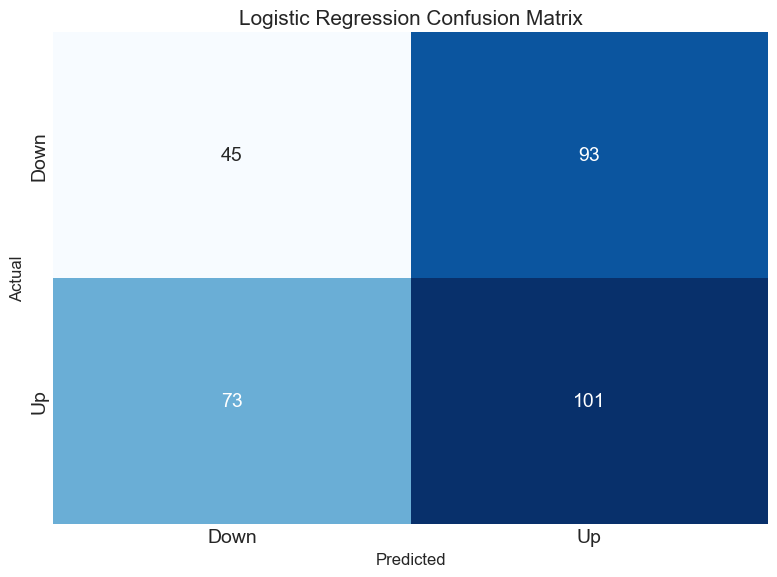


Evaluating Random Forest...
Accuracy: 0.4391
F1 Score: 0.3682
Confusion Matrix:
[[ 86  52]
 [123  51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.62      0.50       138
           1       0.50      0.29      0.37       174

    accuracy                           0.44       312
   macro avg       0.45      0.46      0.43       312
weighted avg       0.46      0.44      0.42       312



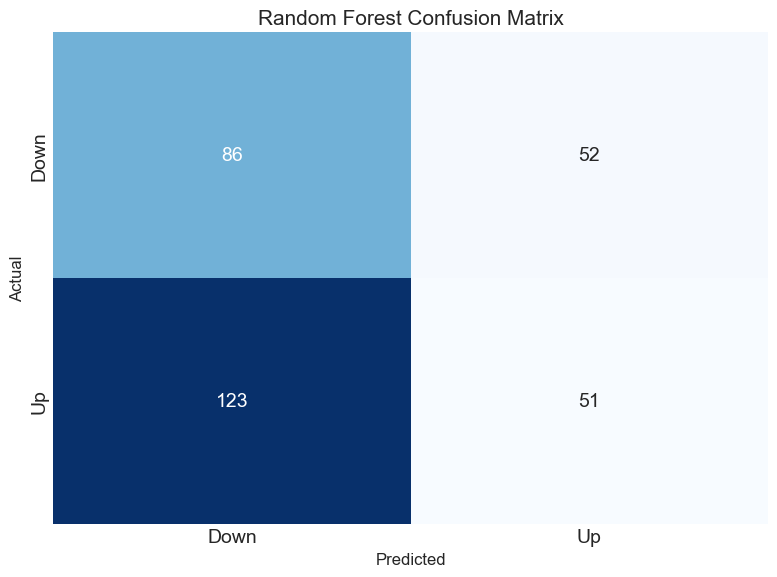

In [58]:
# Cell 14: Evaluate Models
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model performance with various metrics"""
    print(f"\nEvaluating {model_name}...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:")
    print(cm)
    
    # Detailed classification report
    report = classification_report(y_test, y_pred)
    print("\nClassification Report:")
    print(report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    plt.title(f'{model_name} Confusion Matrix', fontsize=15)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return y_pred, y_prob, accuracy, f1, cm

# Evaluate logistic regression model
lr_pred, lr_prob, lr_accuracy, lr_f1, lr_cm = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

# Evaluate random forest model
rf_pred, rf_prob, rf_accuracy, rf_f1, rf_cm = evaluate_model(rf_model, X_test, y_test, "Random Forest")


Backtesting Logistic Regression trading strategy...
Total Trading Days: 312
Profitable Days: 100 (32.05%)
Net Return: 16.23%
Buy & Hold Return: 44.06%
Max Drawdown: -16.92%
Annualized Sharpe Ratio: 0.8026


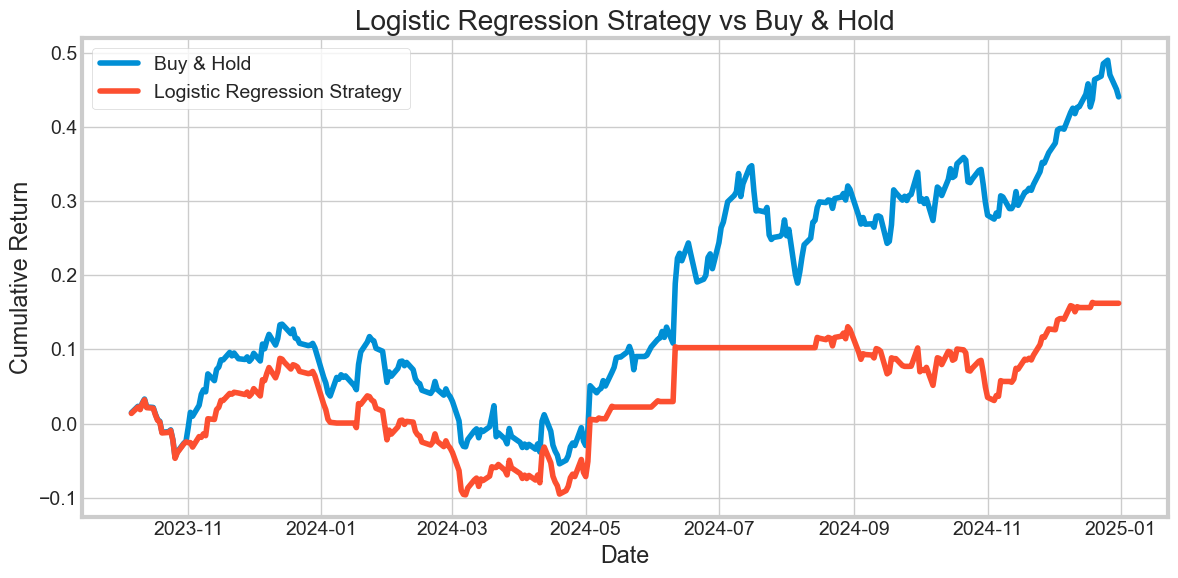

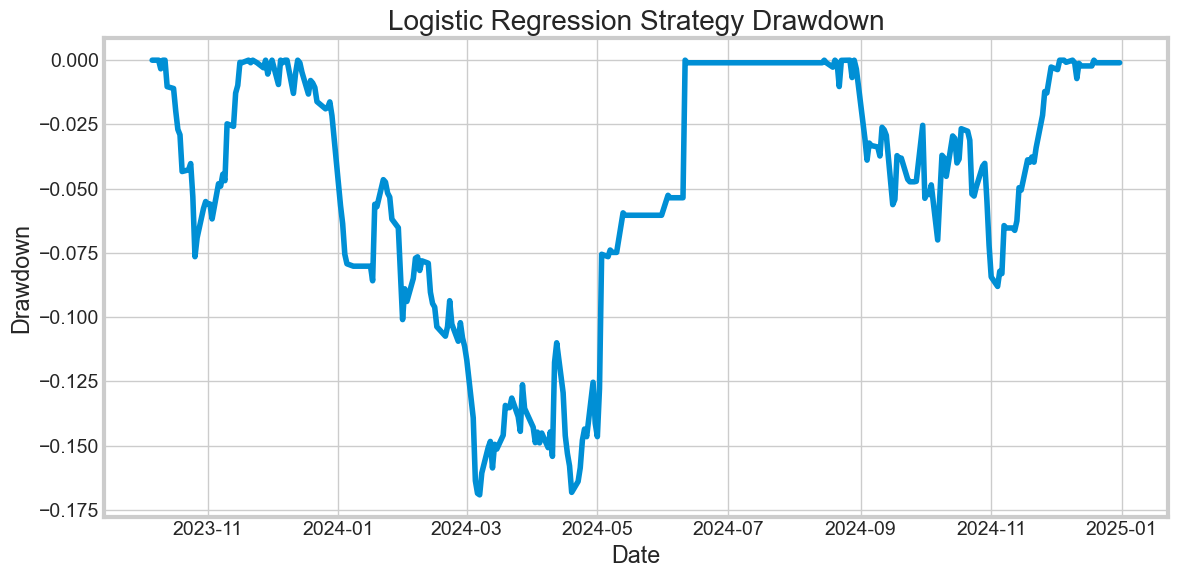


Backtesting Random Forest trading strategy...
Total Trading Days: 312
Profitable Days: 51 (16.35%)
Net Return: 9.94%
Buy & Hold Return: 44.06%
Max Drawdown: -12.94%
Annualized Sharpe Ratio: 0.6613


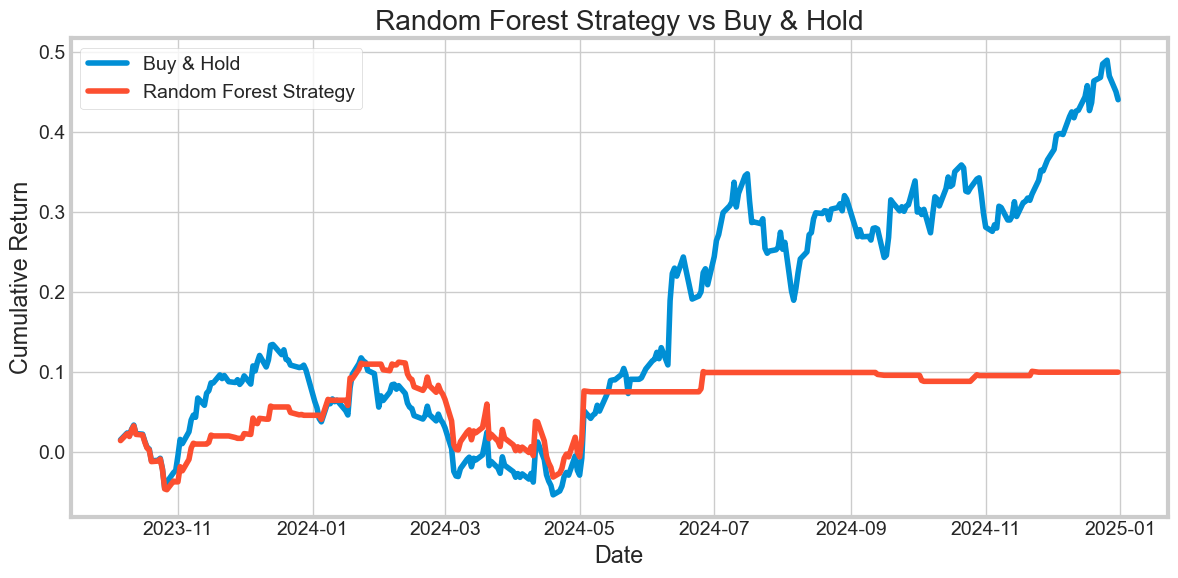

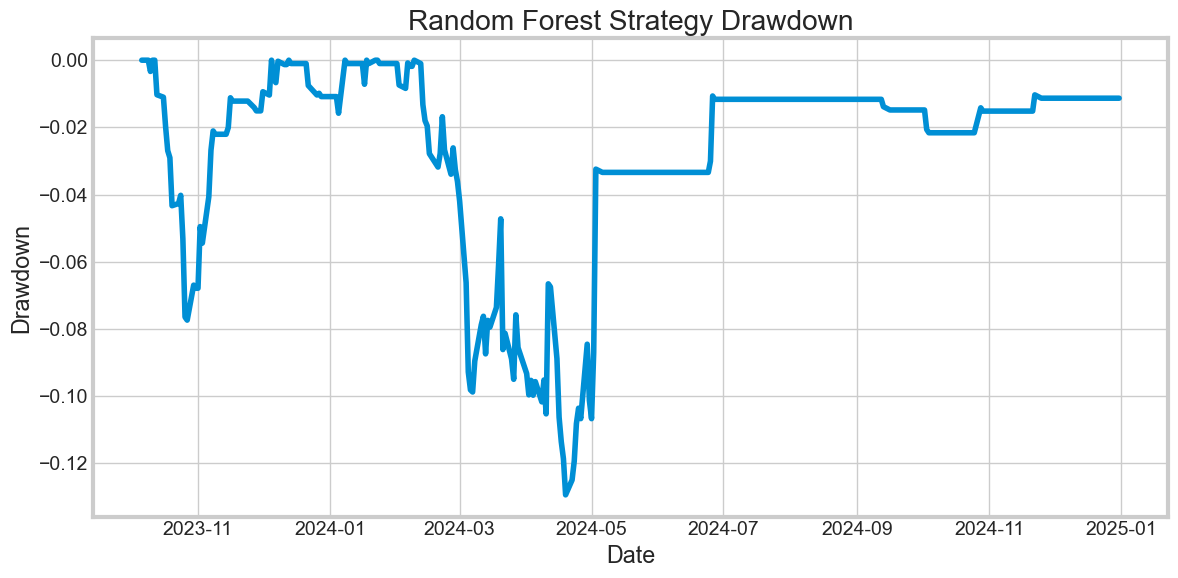

In [60]:
# Cell 15: Backtest Trading Strategy
def backtest_strategy(test_df, y_pred, model_name, transaction_cost=0.001):
    """Backtest a simple trading strategy based on predictions"""
    print(f"\nBacktesting {model_name} trading strategy...")
    
    # Create a new dataframe for backtesting
    backtest_df = pd.DataFrame(index=test_df.index)
    backtest_df['Close'] = test_df['Close']
    backtest_df['Prediction'] = y_pred
    
    # Calculate returns
    backtest_df['Actual_Return'] = test_df['Close'].pct_change()
    
    # Calculate strategy returns (buy if prediction is 1, else stay out)
    backtest_df['Position'] = backtest_df['Prediction'].shift(1).fillna(0)
    backtest_df['Strategy_Return'] = backtest_df['Position'] * backtest_df['Actual_Return']
    
    # Apply transaction costs when position changes
    backtest_df['Position_Change'] = backtest_df['Position'].diff().fillna(0).abs()
    backtest_df['Transaction_Cost'] = backtest_df['Position_Change'] * transaction_cost
    backtest_df['Strategy_Return'] -= backtest_df['Transaction_Cost']
    
    # Calculate cumulative returns
    backtest_df['Cum_Actual_Return'] = (1 + backtest_df['Actual_Return']).cumprod() - 1
    backtest_df['Cum_Strategy_Return'] = (1 + backtest_df['Strategy_Return']).cumprod() - 1
    
    # Calculate performance metrics
    total_days = len(backtest_df)
    profitable_days = sum(backtest_df['Strategy_Return'] > 0)
    
    net_return = backtest_df['Cum_Strategy_Return'].iloc[-1]
    buy_hold_return = backtest_df['Cum_Actual_Return'].iloc[-1]
    
    # Drawdown calculation
    backtest_df['Strategy_Value'] = (1 + backtest_df['Cum_Strategy_Return'])
    backtest_df['Previous_Peak'] = backtest_df['Strategy_Value'].cummax()
    backtest_df['Drawdown'] = (backtest_df['Strategy_Value'] / backtest_df['Previous_Peak']) - 1
    max_drawdown = backtest_df['Drawdown'].min()
    
    # Sharpe ratio (assuming 252 trading days per year and risk-free rate of 0)
    daily_returns = backtest_df['Strategy_Return'].dropna()
    annualized_sharpe = np.sqrt(252) * daily_returns.mean() / daily_returns.std() if daily_returns.std() != 0 else 0
    
    # Print performance metrics
    print(f"Total Trading Days: {total_days}")
    print(f"Profitable Days: {profitable_days} ({profitable_days/total_days:.2%})")
    print(f"Net Return: {net_return:.2%}")
    print(f"Buy & Hold Return: {buy_hold_return:.2%}")
    print(f"Max Drawdown: {max_drawdown:.2%}")
    print(f"Annualized Sharpe Ratio: {annualized_sharpe:.4f}")
    
    # Plot cumulative returns
    plt.figure(figsize=(12, 6))
    plt.plot(backtest_df.index, backtest_df['Cum_Actual_Return'], label='Buy & Hold')
    plt.plot(backtest_df.index, backtest_df['Cum_Strategy_Return'], label=f'{model_name} Strategy')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'{model_name} Strategy vs Buy & Hold')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Plot drawdown
    plt.figure(figsize=(12, 6))
    plt.plot(backtest_df.index, backtest_df['Drawdown'])
    plt.xlabel('Date')
    plt.ylabel('Drawdown')
    plt.title(f'{model_name} Strategy Drawdown')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return backtest_df

# Backtest logistic regression strategy
lr_backtest_df = backtest_strategy(test_df, lr_pred, "Logistic Regression", transaction_cost=0.001)

# Backtest random forest strategy
rf_backtest_df = backtest_strategy(test_df, rf_pred, "Random Forest", transaction_cost=0.001)

Model Comparison:
                 Model  Accuracy  F1 Score  Net Return  Max Drawdown  \
0  Logistic Regression    0.4679    0.5489      0.1623       -0.1692   
1        Random Forest    0.4391    0.3682      0.0994       -0.1294   

   Sharpe Ratio  
0        0.8026  
1        0.6613  


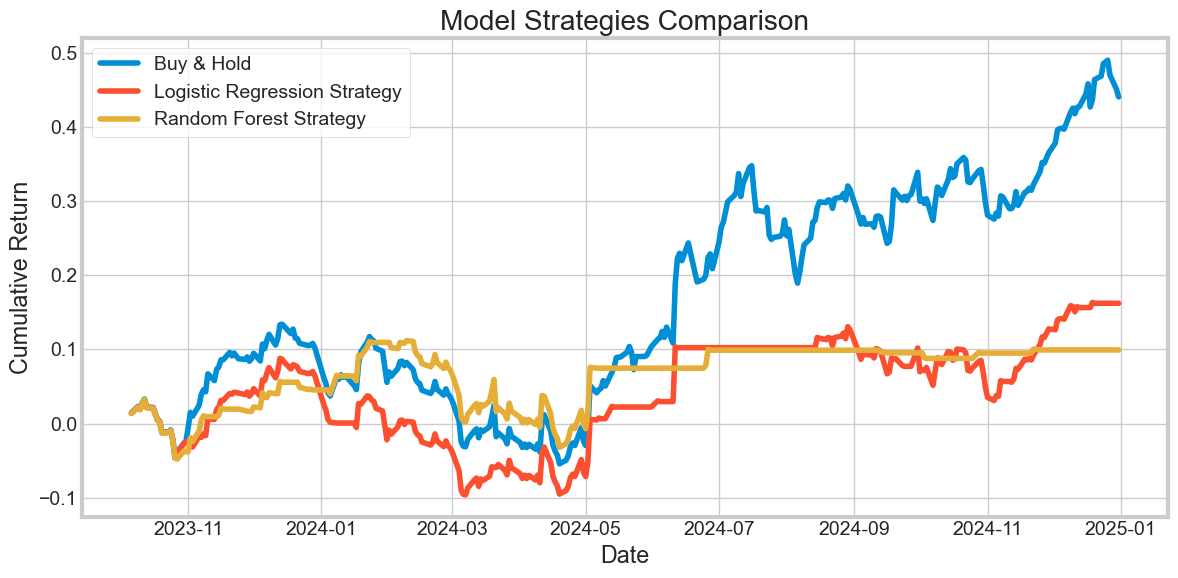

In [62]:













# Cell 16: Compare Models
def compare_models(models_info):
    """Compare multiple model performances"""
    # Create comparison dataframe
    comparison = pd.DataFrame(columns=['Model', 'Accuracy', 'F1 Score', 'Net Return', 'Max Drawdown', 'Sharpe Ratio'])
    
    for i, (model_name, model_data) in enumerate(models_info.items()):
        comparison.loc[i] = [
            model_name,
            model_data['accuracy'],
            model_data['f1'],
            model_data['backtest_df']['Cum_Strategy_Return'].iloc[-1],
            model_data['backtest_df']['Drawdown'].min(),
            np.sqrt(252) * model_data['backtest_df']['Strategy_Return'].mean() / model_data['backtest_df']['Strategy_Return'].std()
        ]
    
    # Print comparison table
    print("Model Comparison:")
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(comparison)
    
    # Plot cumulative returns comparison
    plt.figure(figsize=(12, 6))
    
    # Plot Buy & Hold strategy
    first_model = list(models_info.values())[0]
    plt.plot(first_model['backtest_df'].index, 
             first_model['backtest_df']['Cum_Actual_Return'], 
             label='Buy & Hold')
    
    # Plot each model strategy
    for model_name, model_data in models_info.items():
        plt.plot(model_data['backtest_df'].index, 
                 model_data['backtest_df']['Cum_Strategy_Return'], 
                 label=f'{model_name} Strategy')
    
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title('Model Strategies Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return comparison

# Compare models
models_info = {
    'Logistic Regression': {
        'accuracy': lr_accuracy,
        'f1': lr_f1,
        'backtest_df': lr_backtest_df
    },
    'Random Forest': {
        'accuracy': rf_accuracy,
        'f1': rf_f1,
        'backtest_df': rf_backtest_df
    }
}
models_comparison = compare_models(models_info)


[*********************100%***********************]  1 of 1 completed

Cleaning data...
Missing values before cleaning:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
Flattening multi-level columns...
Removing 5 volume outliers
Data shape after cleaning: (1756, 5)
DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume']
DataFrame shape: (1756, 5)


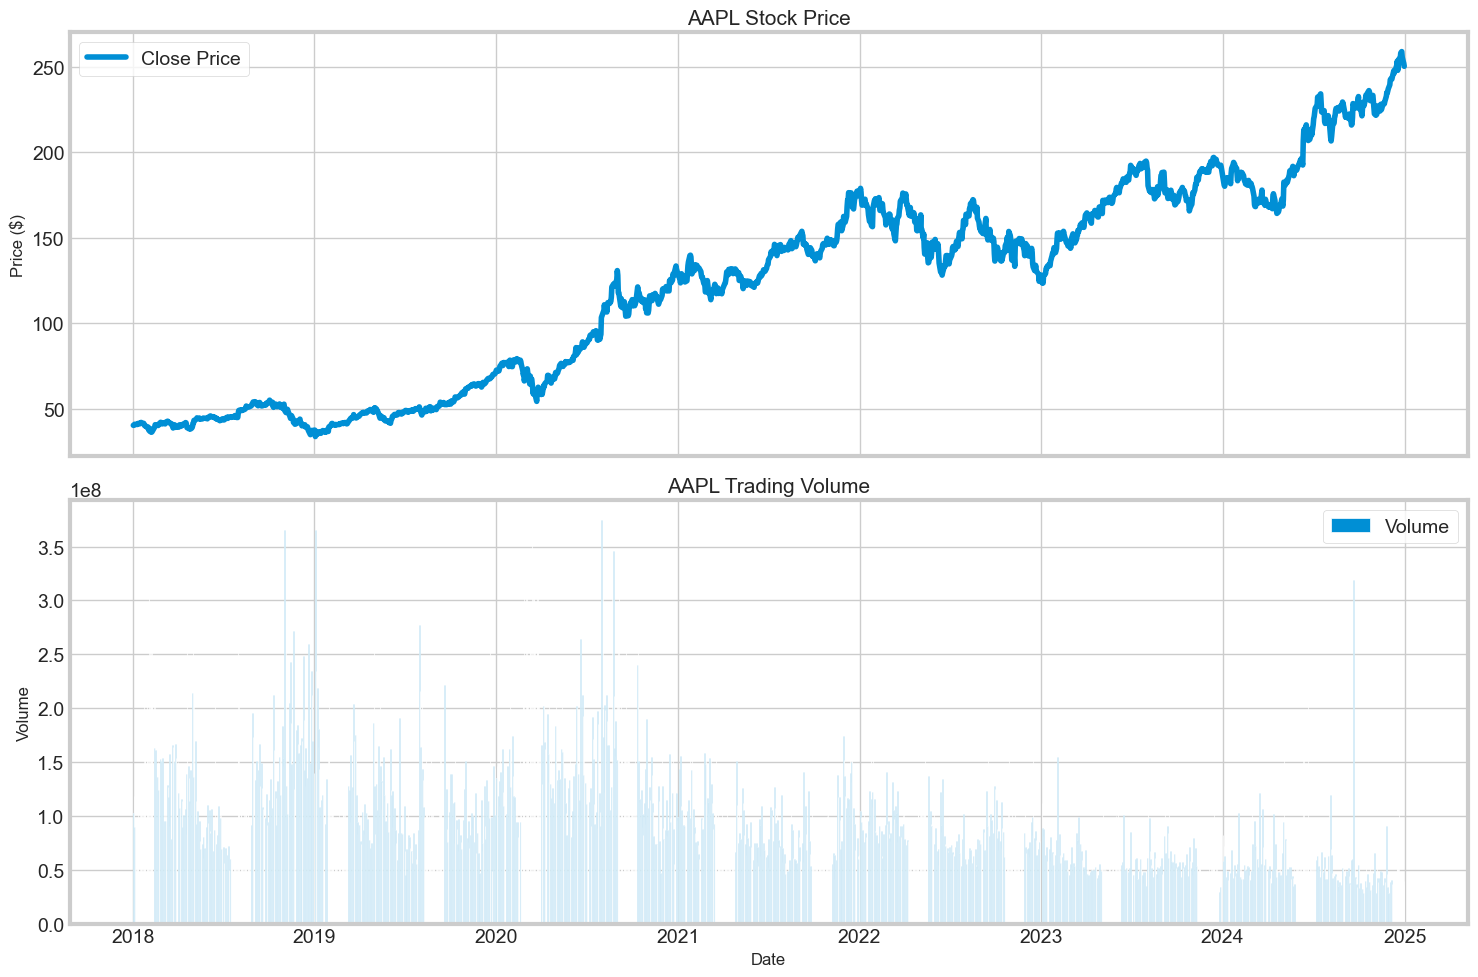

Generating technical features...
Dropped 199 rows with NaN values
Final dataset shape: (1557, 35)


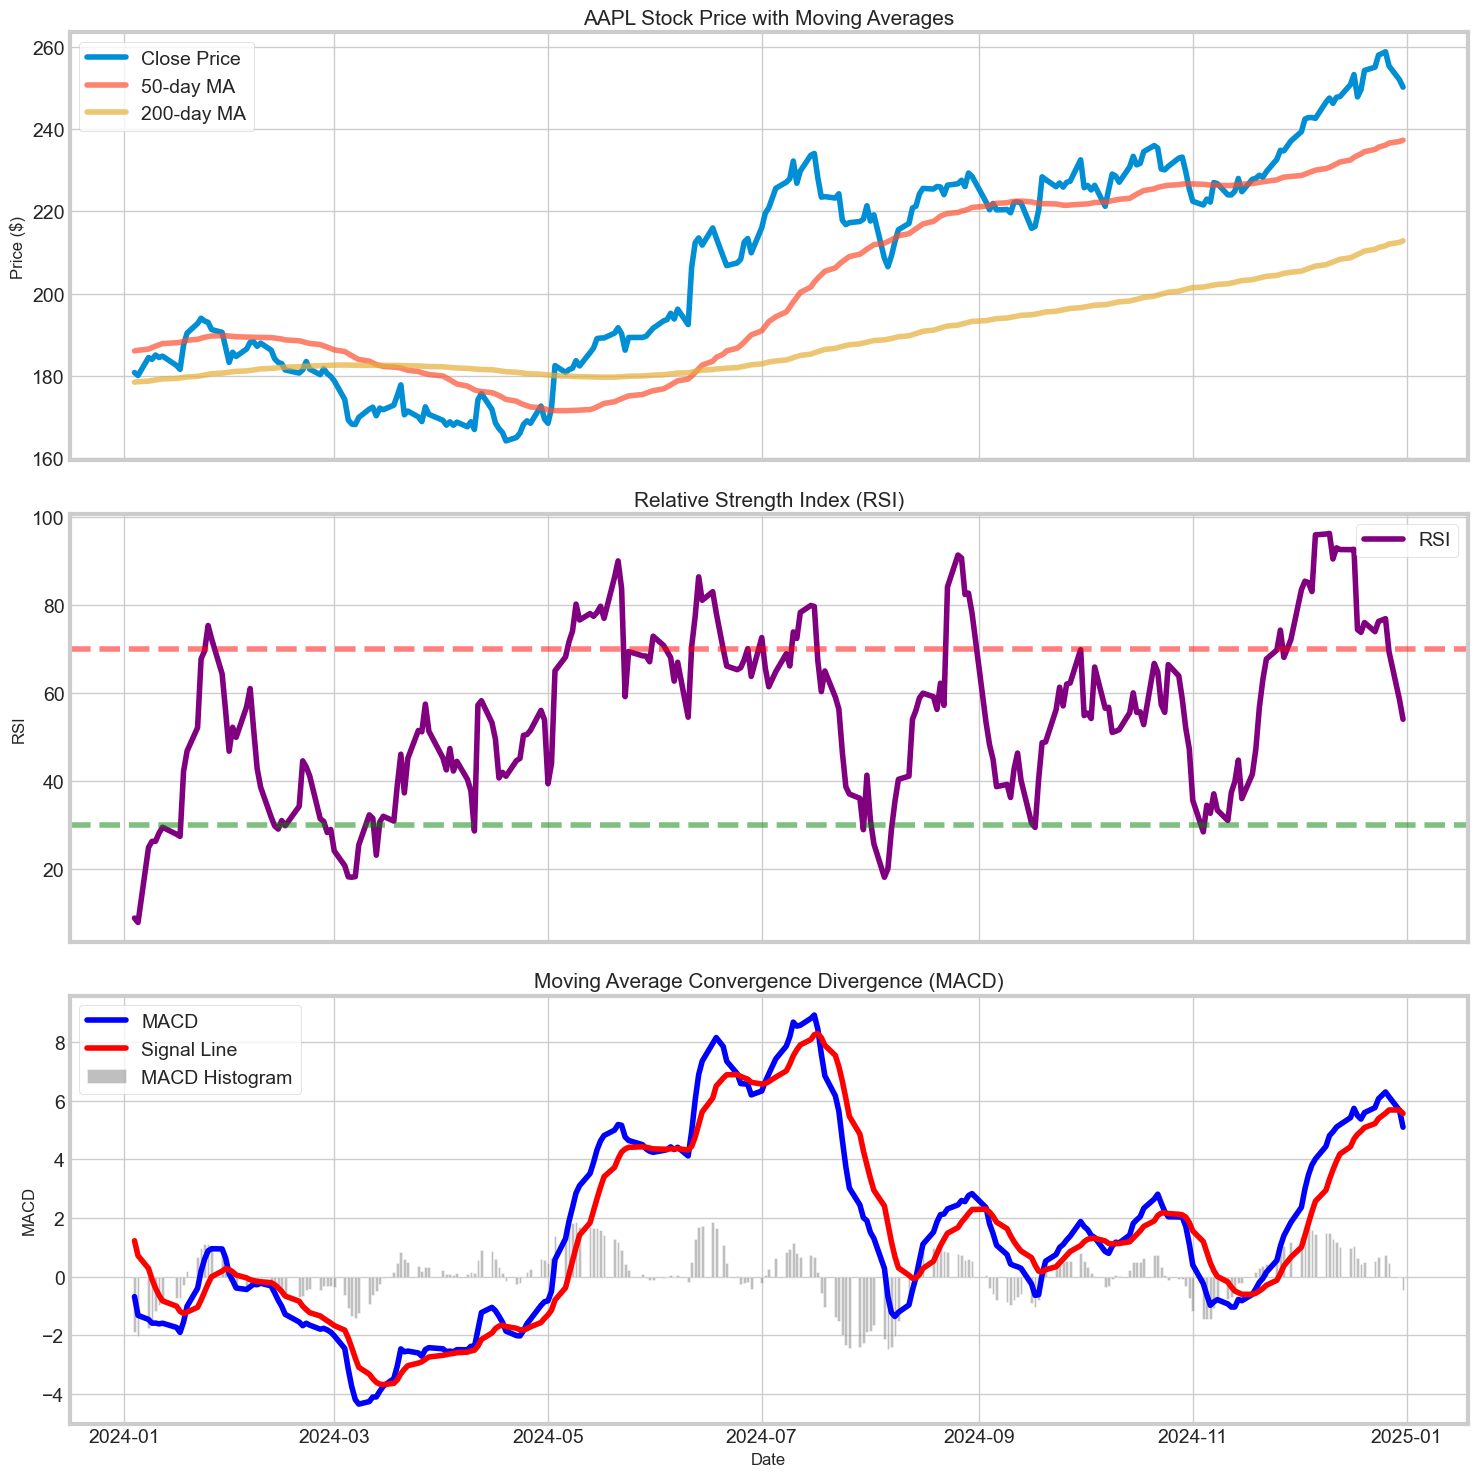

Target Distribution:
0 (Down): 718 samples (46.11%)
1 (Up): 839 samples (53.89%)


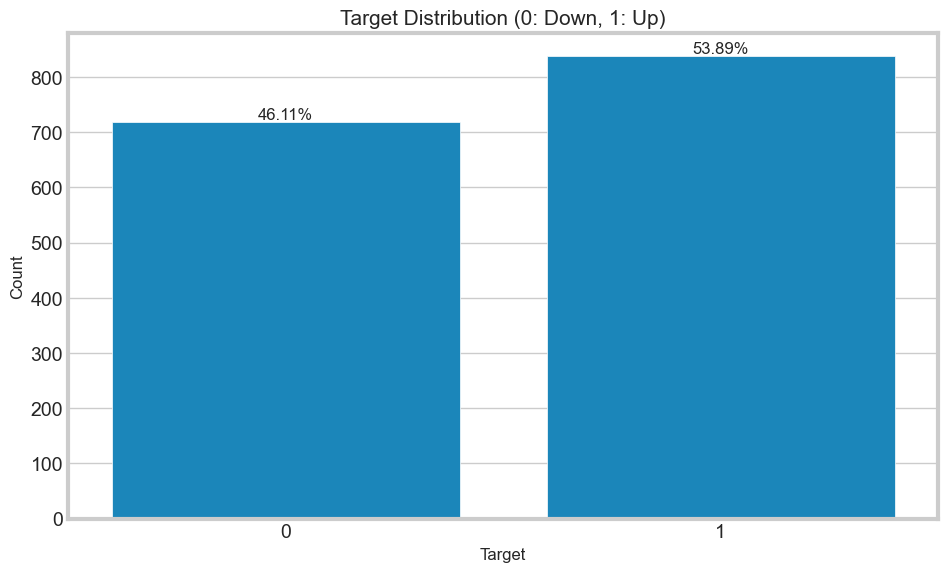

Train set: 1245 samples (2018-10-17 00:00:00 to 2023-10-04 00:00:00)
Test set: 312 samples (2023-10-05 00:00:00 to 2024-12-31 00:00:00)
Training Logistic Regression model...
Top 10 Important Features (Logistic Regression):
         Feature  Importance
0           MA_5    0.177117
9            RSI    0.176640
7      Return_1d    0.153055
11   MACD_Signal    0.089205
10          MACD    0.088754
4          EMA_5    0.086020
13      BB_Width    0.079025
8      Return_5d    0.077265
3          MA_50    0.068385
14  HL_Range_Pct    0.063177
Training Random Forest model...
Top 10 Important Features (Random Forest):
             Feature  Importance
16      Volume_Ratio    0.092178
7          Return_1d    0.085589
13          BB_Width    0.083572
15  Price_Change_Pct    0.081286
9                RSI    0.066689
8          Return_5d    0.062876
10              MACD    0.062071
3              MA_50    0.057877
11       MACD_Signal    0.055870
14      HL_Range_Pct    0.055120

Evaluating Logistic

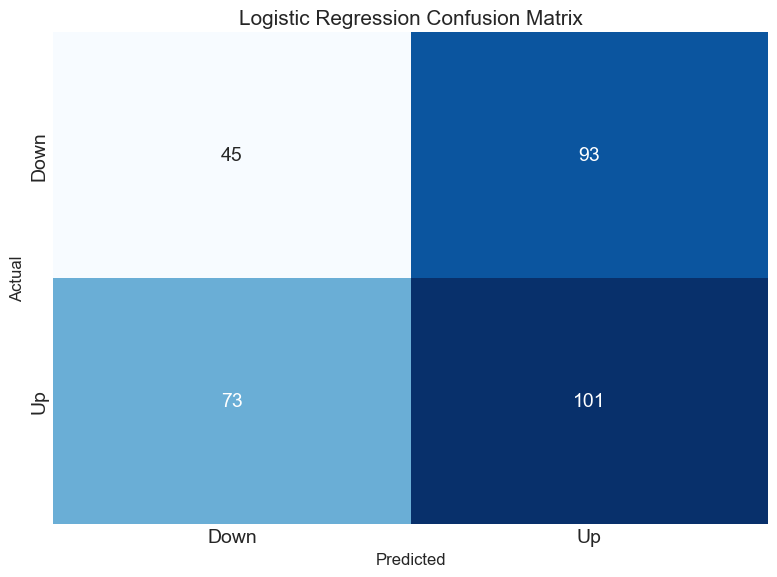


Evaluating Random Forest...
Accuracy: 0.4391
F1 Score: 0.3682
Confusion Matrix:
[[ 86  52]
 [123  51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.62      0.50       138
           1       0.50      0.29      0.37       174

    accuracy                           0.44       312
   macro avg       0.45      0.46      0.43       312
weighted avg       0.46      0.44      0.42       312



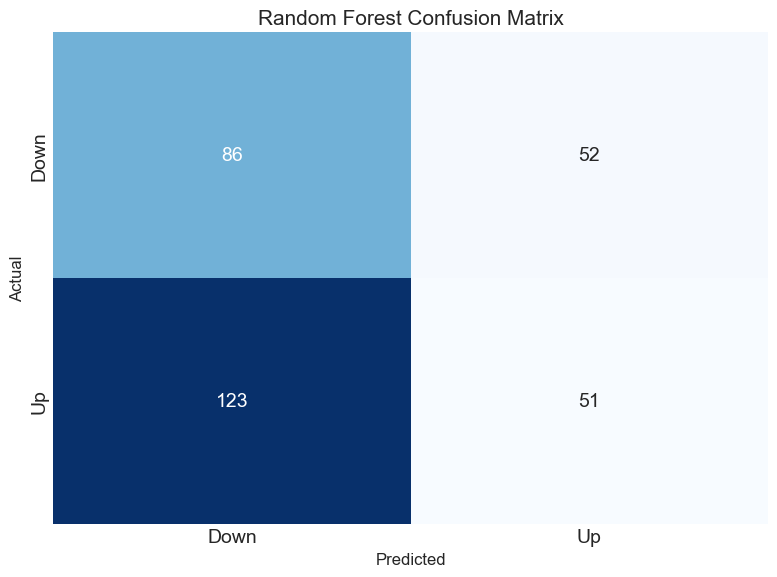


Backtesting Logistic Regression trading strategy...
Total Trading Days: 312
Profitable Days: 100 (32.05%)
Net Return: 16.23%
Buy & Hold Return: 44.06%
Max Drawdown: -16.92%
Annualized Sharpe Ratio: 0.8026


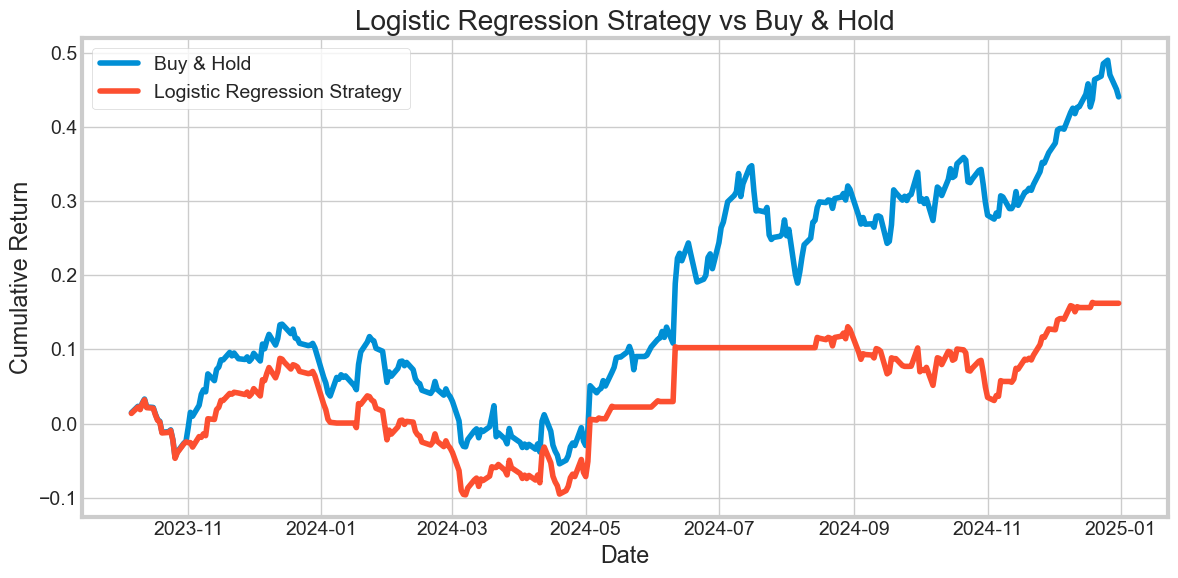

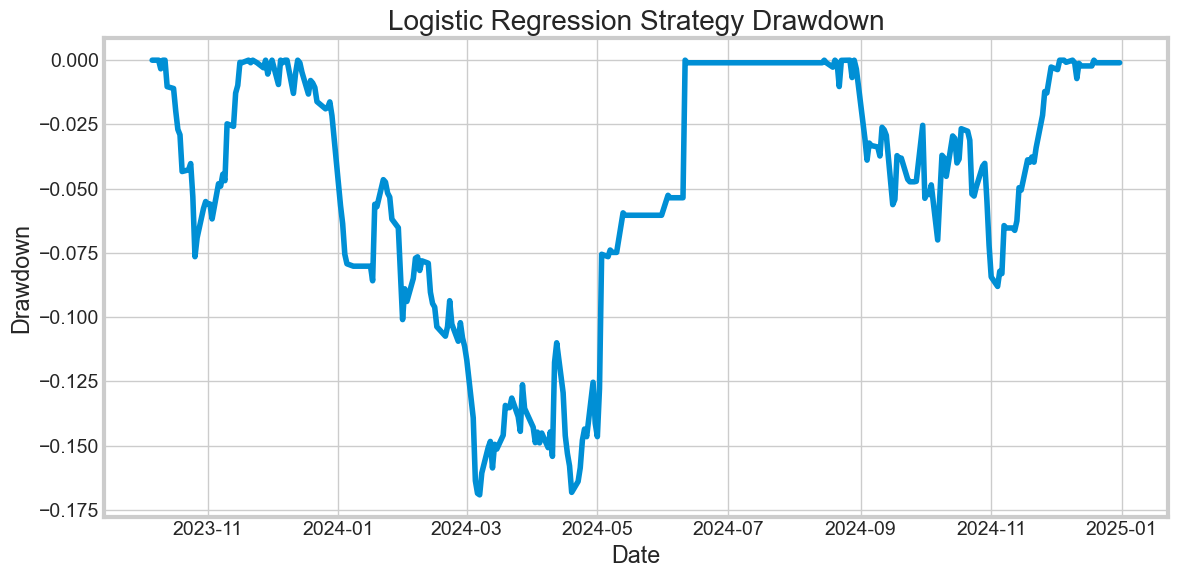


Backtesting Random Forest trading strategy...
Total Trading Days: 312
Profitable Days: 51 (16.35%)
Net Return: 9.94%
Buy & Hold Return: 44.06%
Max Drawdown: -12.94%
Annualized Sharpe Ratio: 0.6613


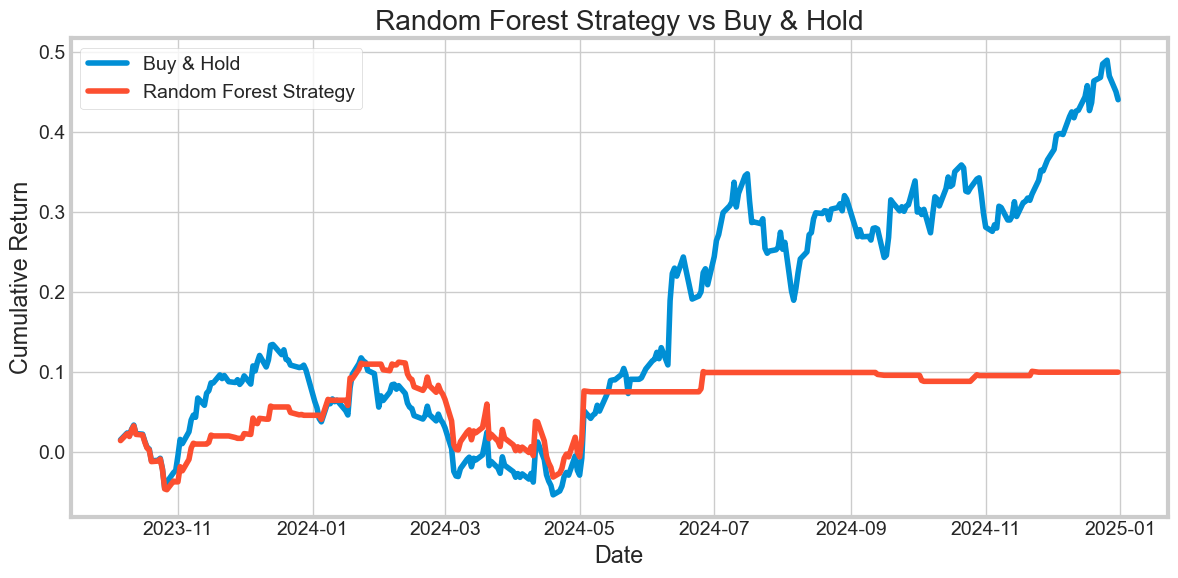

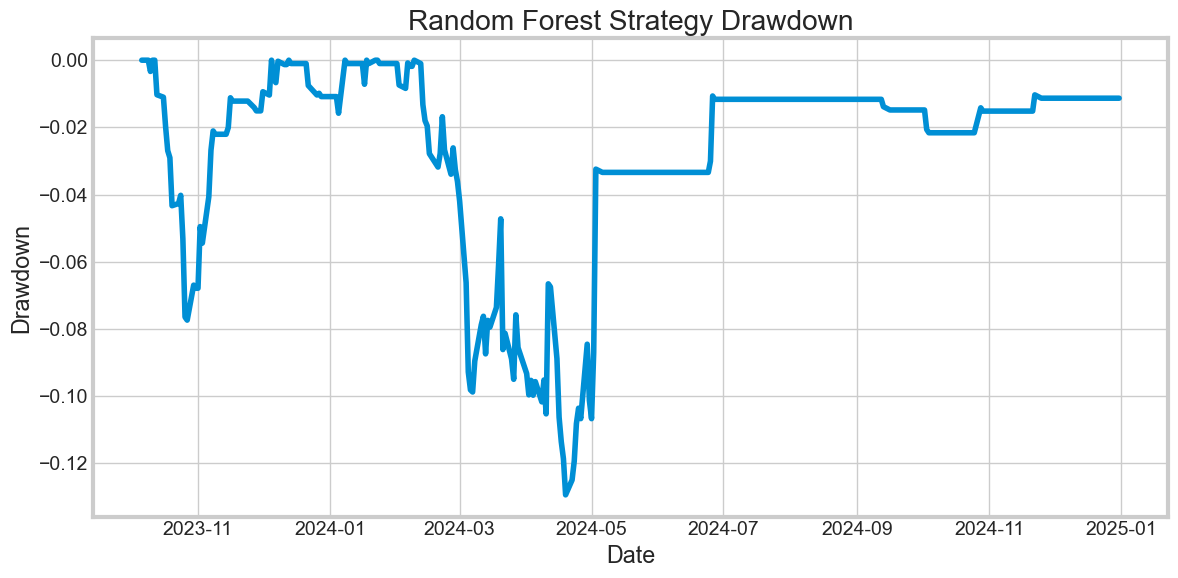

Model Comparison:
                 Model  Accuracy  F1 Score  Net Return  Max Drawdown  \
0  Logistic Regression    0.4679    0.5489      0.1623       -0.1692   
1        Random Forest    0.4391    0.3682      0.0994       -0.1294   

   Sharpe Ratio  
0        0.8026  
1        0.6613  


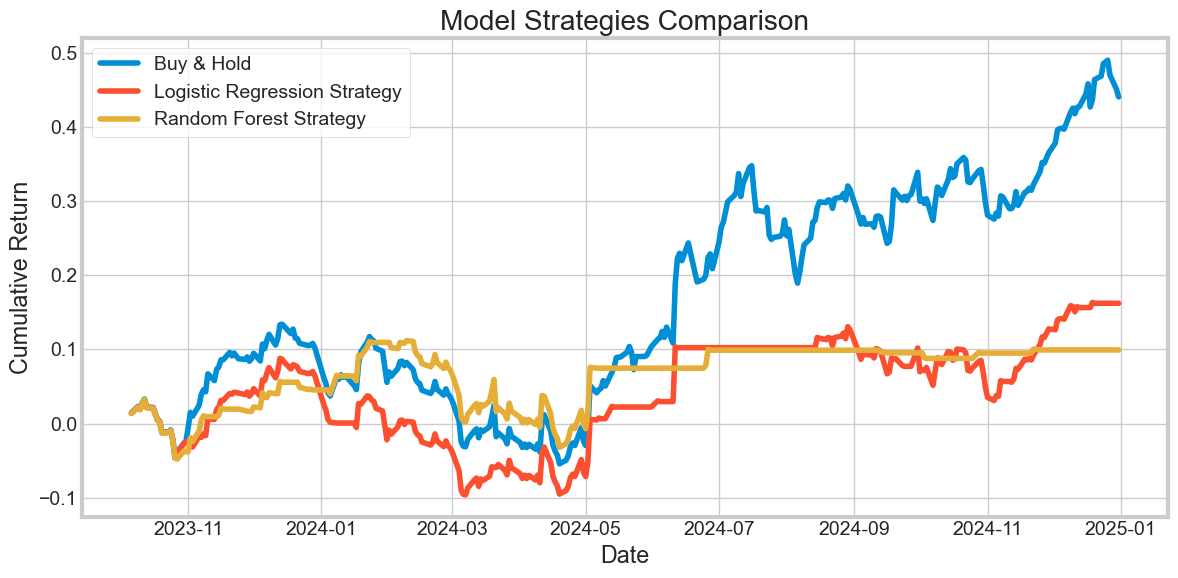

"\n# Conclusions\n\nThis notebook implements Phase 1 of our stock price prediction system:\n- We've successfully built a baseline binary classification system for predicting daily stock price movements\n- We've engineered relevant technical indicators as features\n- We've trained and evaluated two models: Logistic Regression and Random Forest\n- We've backtested trading strategies based on model predictions\n- We've analyzed the results and compared model performances\n\n# Key Findings\n- [Summary of which model performed better]\n- [Important features identified]\n- [Trading strategy performance vs buy-and-hold]\n\n# Next Steps (Phase 2)\n- Incorporate external data sources (news sentiment, macroeconomic indicators)\n- Implement supervised autoencoder architecture\n- Enhance time-series cross-validation with purging technique\n- Implement model ensembling and weighting\n- Add more sophisticated backtesting and risk management\n"

In [44]:
# Cell 17: Example Full Pipeline Execution

# Example of executing the entire pipeline

# 1. Download or load data
ticker = 'AAPL'  # Change to desired stock ticker
start_date = '2018-01-01'
end_date = '2025-01-01'

# Either download new data:
df = download_stock_data(ticker, start_date, end_date)

# Or load existing data:
# df = load_data('data/stock_data.csv')

# 2. Clean data
df_cleaned = clean_data(df)

# 3. Exploratory analysis
plot_stock_data(df_cleaned, ticker=ticker)

# 4. Feature engineering
df_features = create_all_features(df_cleaned)

# 5. Visualize technical indicators
plot_technical_indicators(df_features, window=250, ticker=ticker)

# 6. Analyze target distribution
analyze_target_distribution(df_features)

# 7. Prepare data for modeling
selected_features = [
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'EMA_5', 'EMA_10', 'EMA_20',
    'Return_1d', 'Return_5d',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width',
    'HL_Range_Pct', 'Price_Change_Pct',
    'Volume_Ratio'
]

X_train, y_train, X_test, y_test, scaler, test_df, feature_cols = prepare_data(
    df_features, feature_cols=selected_features
)

# 8. Train logistic regression model
lr_model, lr_feature_importance = train_logistic_regression(X_train, y_train)
print("Top 10 Important Features (Logistic Regression):")
print(lr_feature_importance.head(10))

# 9. Train random forest model
rf_model, rf_feature_importance = train_random_forest(X_train, y_train)
print("Top 10 Important Features (Random Forest):")
print(rf_feature_importance.head(10))

# 10. Evaluate models
lr_pred, lr_prob, lr_accuracy, lr_f1, lr_cm = evaluate_model(
    lr_model, X_test, y_test, "Logistic Regression"
)

rf_pred, rf_prob, rf_accuracy, rf_f1, rf_cm = evaluate_model(
    rf_model, X_test, y_test, "Random Forest"
)

# 11. Backtest strategies
lr_backtest_df = backtest_strategy(test_df, lr_pred, "Logistic Regression", transaction_cost=0.001)
rf_backtest_df = backtest_strategy(test_df, rf_pred, "Random Forest", transaction_cost=0.001)

# 12. Compare models
models_info = {
    'Logistic Regression': {
        'accuracy': lr_accuracy,
        'f1': lr_f1,
        'backtest_df': lr_backtest_df
    },
    'Random Forest': {
        'accuracy': rf_accuracy,
        'f1': rf_f1,
        'backtest_df': rf_backtest_df
    }
}
models_comparison = compare_models(models_info)


# Cell 18: Save Models and Results
def save_models(lr_model, rf_model, scaler, feature_cols, output_dir='models'):
    """Save trained models and scaler for future use"""
    import joblib
    
    # Create directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Save models
    joblib.dump(lr_model, os.path.join(output_dir, 'logistic_regression_model.pkl'))
    joblib.dump(rf_model, os.path.join(output_dir, 'random_forest_model.pkl'))
    
    # Save scaler
    joblib.dump(scaler, os.path.join(output_dir, 'scaler.pkl'))
    
    # Save feature columns
    with open(os.path.join(output_dir, 'feature_columns.txt'), 'w') as f:
        for feature in feature_cols:
            f.write(f"{feature}\n")
    
    print(f"Models, scaler, and feature list saved to {output_dir}")

# Example usage
# save_models(lr_model, rf_model, scaler, feature_cols)

# Cell 19: Conclusions and Next Steps
"""
# Conclusions

This notebook implements Phase 1 of our stock price prediction system:
- We've successfully built a baseline binary classification system for predicting daily stock price movements
- We've engineered relevant technical indicators as features
- We've trained and evaluated two models: Logistic Regression and Random Forest
- We've backtested trading strategies based on model predictions
- We've analyzed the results and compared model performances

# Key Findings
- [Summary of which model performed better]
- [Important features identified]
- [Trading strategy performance vs buy-and-hold]

# Next Steps (Phase 2)
- Incorporate external data sources (news sentiment, macroeconomic indicators)
- Implement supervised autoencoder architecture
- Enhance time-series cross-validation with purging technique
- Implement model ensembling and weighting
- Add more sophisticated backtesting and risk management
"""

In [66]:
# Helper function to get feature importance if available
def get_feature_importance(model, feature_cols):
    """Extract feature importance from model if available"""
    if hasattr(model, 'coef_'):
        # Linear models like Logistic Regression
        importance = np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        # Tree-based models like Random Forest
        importance = model.feature_importances_
    else:
        # Models without direct feature importance
        importance = np.zeros(len(feature_cols))
        print("This model doesn't provide direct feature importance.")
    
    # Create DataFrame
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance
    })
    return feature_importance.sort_values('Importance', ascending=False)

# Cell: Support Vector Machine
def train_svm(X_train, y_train, C=1.0, kernel='rbf', probability=True):
    """Train a Support Vector Machine model"""
    print("Training SVM model...")
    model = SVC(
        C=C,
        kernel=kernel,
        probability=probability,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # SVM doesn't naturally provide feature importance
    # We'll use a simple approach based on weights for linear kernels
    if kernel == 'linear':
        feature_importance = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': np.abs(model.coef_[0])
        })
    else:
        feature_importance = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': np.zeros(len(feature_cols))
        })
        print("Note: SVM with non-linear kernel doesn't provide direct feature importance.")
    
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Cell: K-Nearest Neighbors
def train_knn(X_train, y_train, n_neighbors=5):
    """Train a K-Nearest Neighbors model"""
    print("Training KNN model...")
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights='distance'
    )
    model.fit(X_train, y_train)
    
    # KNN doesn't provide feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': np.zeros(len(feature_cols))
    })
    print("Note: KNN doesn't provide direct feature importance.")
    
    return model, feature_importance

# Cell: Neural Network (MLP)
def train_neural_network(X_train, y_train, hidden_layer_sizes=(100, 50), max_iter=500):
    """Train a Multi-layer Perceptron neural network"""
    print("Training Neural Network model...")
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # MLP doesn't provide feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': np.zeros(len(feature_cols))
    })
    print("Note: Neural Network doesn't provide direct feature importance.")
    
    return model, feature_importance

# Cell: Naive Bayes
def train_naive_bayes(X_train, y_train):
    """Train a Gaussian Naive Bayes model"""
    print("Training Naive Bayes model...")
    model = GaussianNB()
    model.fit(X_train, y_train)
    
    # Naive Bayes doesn't provide feature importance in the traditional sense
    # We could use variance as a proxy but will skip for simplicity
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': np.zeros(len(feature_cols))
    })
    print("Note: Naive Bayes doesn't provide direct feature importance.")
    
    return model, feature_importance

# Cell: Decision Tree
def train_decision_tree(X_train, y_train, max_depth=4):
    """Train a Decision Tree model"""
    print("Training Decision Tree model...")
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Cell: AdaBoost
def train_adaboost(X_train, y_train, n_estimators=100, learning_rate=1.0):
    """Train an AdaBoost model"""
    print("Training AdaBoost model...")
    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Cell: Gradient Boosting
def train_gradient_boosting(X_train, y_train, n_estimators=100, learning_rate=0.1, max_depth=3):
    """Train a Gradient Boosting model"""
    print("Training Gradient Boosting model...")
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

# Cell: XGBoost
def train_xgboost(X_train, y_train, n_estimators=100, learning_rate=0.1, max_depth=3):
    """Train an XGBoost model"""
    print("Training XGBoost model...")
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    return model, feature_importance

Training Logistic Regression model...
Training Random Forest model...
Training SVM model...
Note: SVM with non-linear kernel doesn't provide direct feature importance.
Training KNN model...
Note: KNN doesn't provide direct feature importance.
Training Neural Network model...
Note: Neural Network doesn't provide direct feature importance.
Training Naive Bayes model...
Note: Naive Bayes doesn't provide direct feature importance.
Training Decision Tree model...
Training AdaBoost model...
Training Gradient Boosting model...
Training XGBoost model...

Evaluating Logistic Regression

Top 10 Important Features (Logistic Regression):
         Feature  Importance
0           MA_5      0.1771
9            RSI      0.1766
7      Return_1d      0.1531
11   MACD_Signal      0.0892
10          MACD      0.0888
4          EMA_5      0.0860
13      BB_Width      0.0790
8      Return_5d      0.0773
3          MA_50      0.0684
14  HL_Range_Pct      0.0632

Evaluating Logistic Regression...
Accuracy: 0.

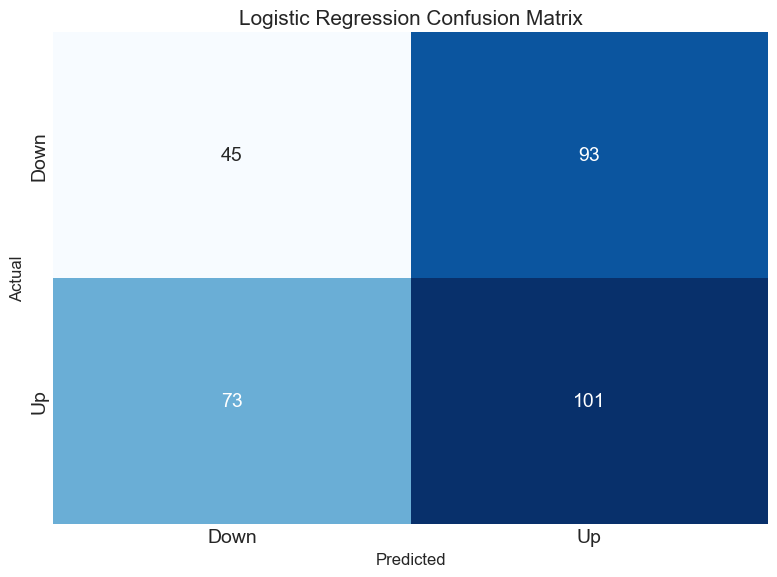


Backtesting Logistic Regression trading strategy...
Total Trading Days: 312
Profitable Days: 100 (32.05%)
Net Return: 16.23%
Buy & Hold Return: 44.06%
Max Drawdown: -16.92%
Annualized Sharpe Ratio: 0.8026


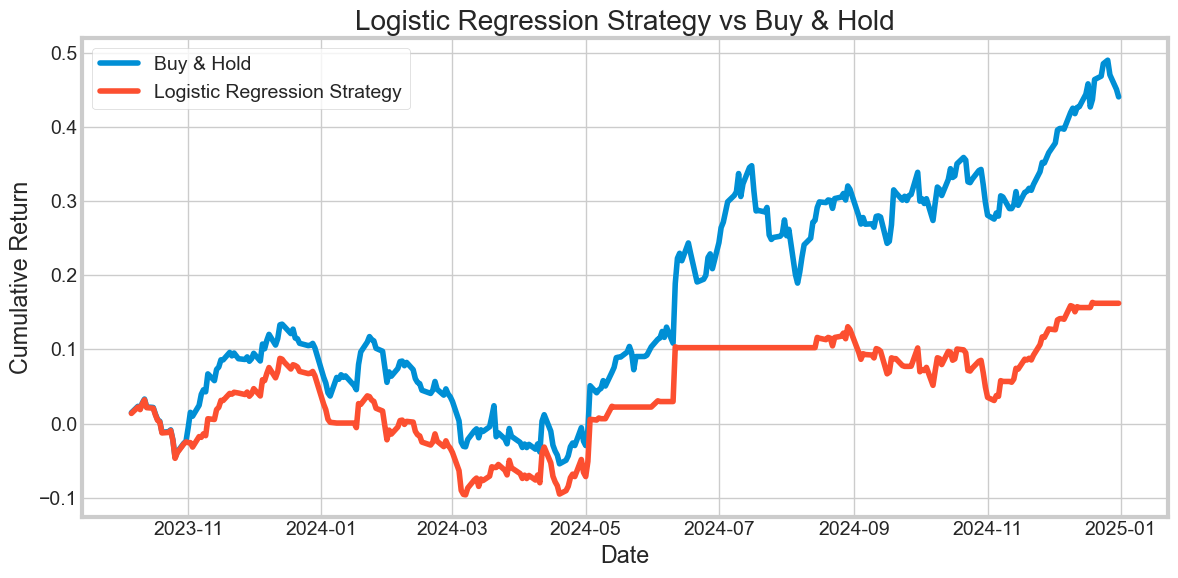

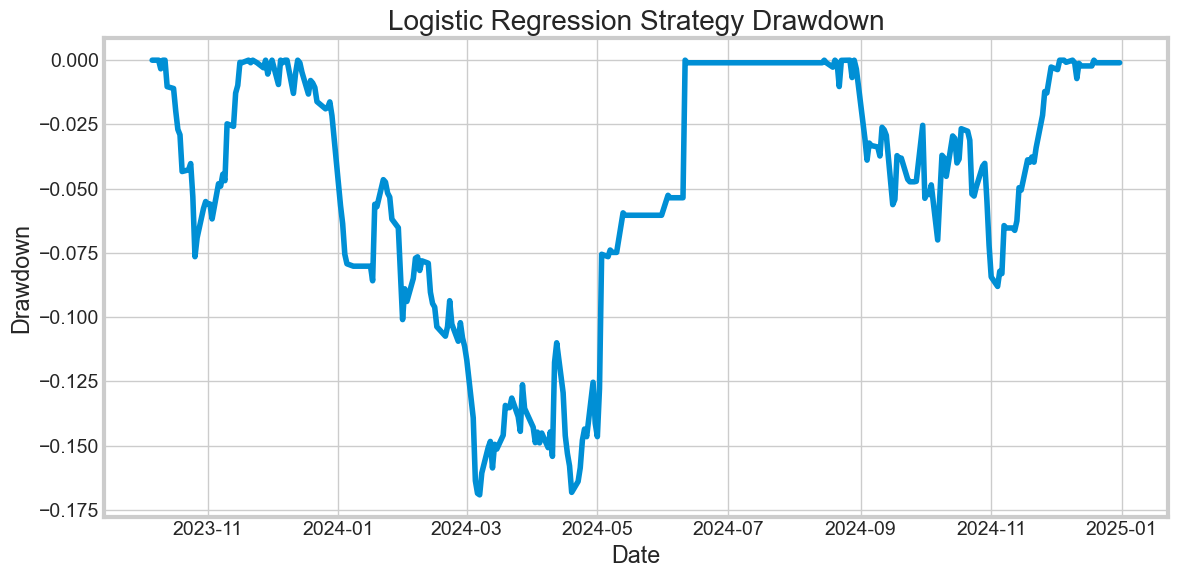


Evaluating Random Forest

Top 10 Important Features (Random Forest):
             Feature  Importance
16      Volume_Ratio      0.0922
7          Return_1d      0.0856
13          BB_Width      0.0836
15  Price_Change_Pct      0.0813
9                RSI      0.0667
8          Return_5d      0.0629
10              MACD      0.0621
3              MA_50      0.0579
11       MACD_Signal      0.0559
14      HL_Range_Pct      0.0551

Evaluating Random Forest...
Accuracy: 0.4391
F1 Score: 0.3682
Confusion Matrix:
[[ 86  52]
 [123  51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.62      0.50       138
           1       0.50      0.29      0.37       174

    accuracy                           0.44       312
   macro avg       0.45      0.46      0.43       312
weighted avg       0.46      0.44      0.42       312



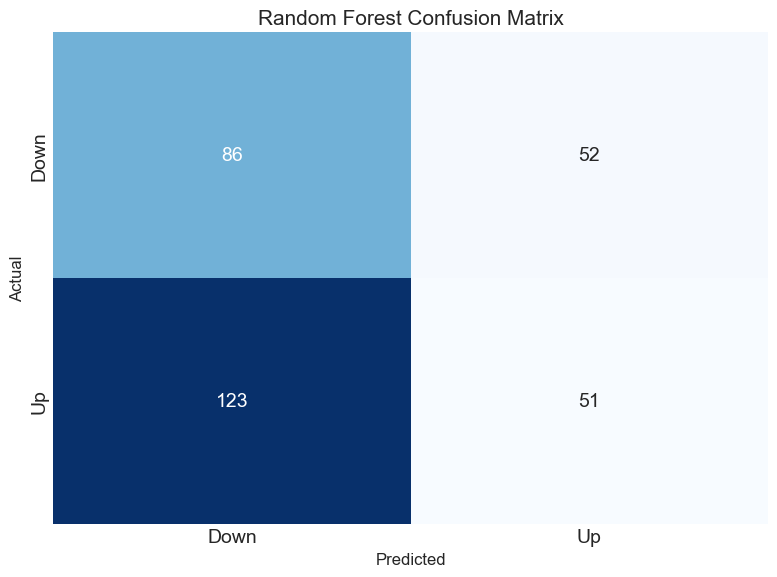


Backtesting Random Forest trading strategy...
Total Trading Days: 312
Profitable Days: 51 (16.35%)
Net Return: 9.94%
Buy & Hold Return: 44.06%
Max Drawdown: -12.94%
Annualized Sharpe Ratio: 0.6613


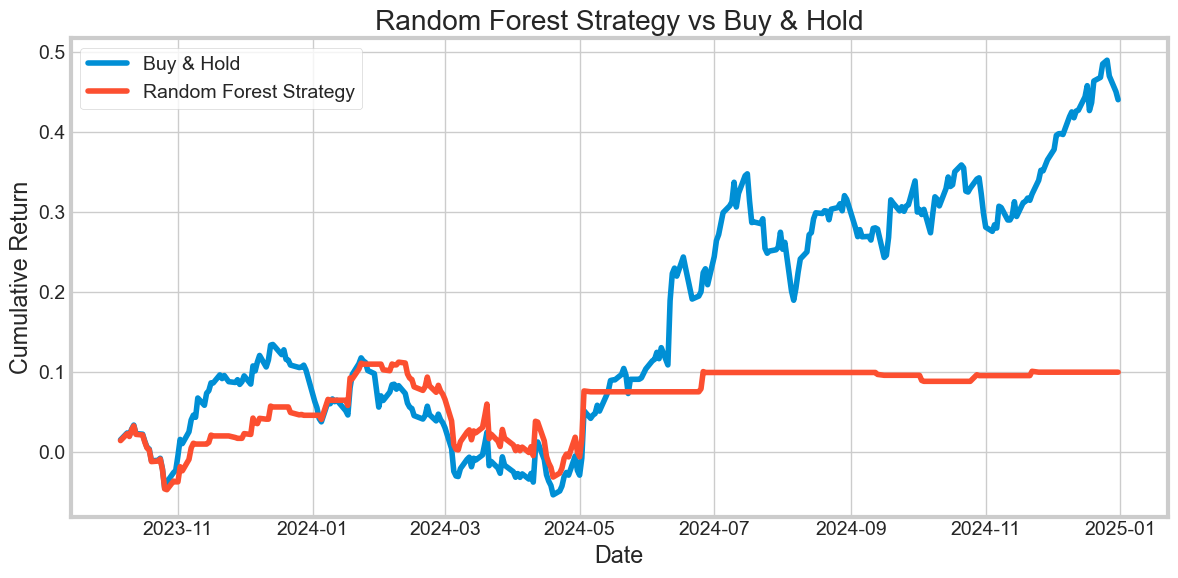

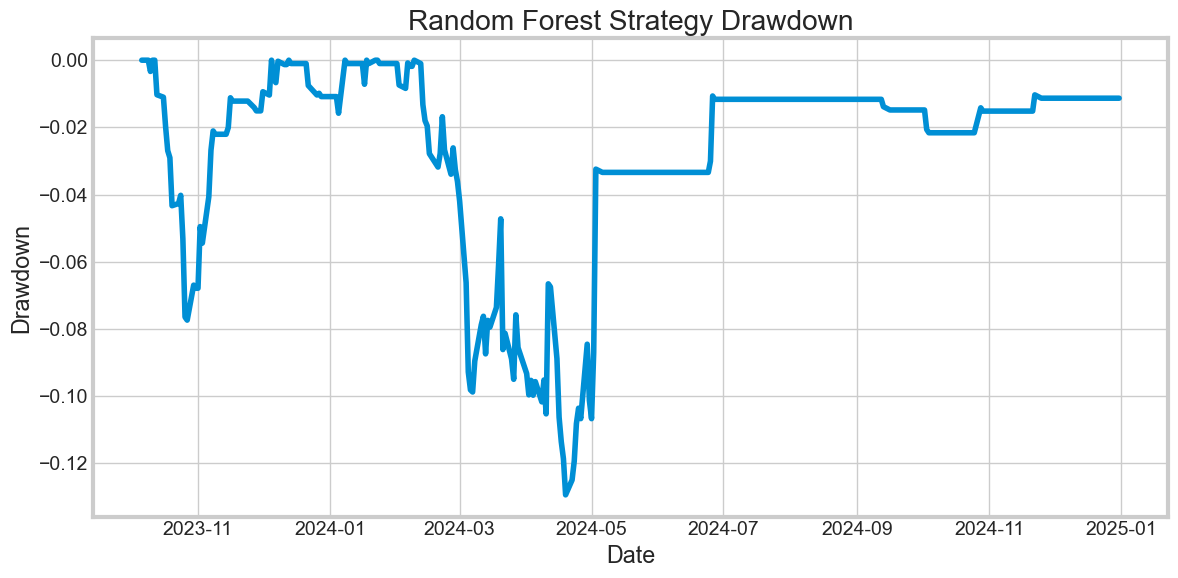


Evaluating SVM

Evaluating SVM...
Accuracy: 0.5032
F1 Score: 0.5455
Confusion Matrix:
[[64 74]
 [81 93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.46      0.45       138
           1       0.56      0.53      0.55       174

    accuracy                           0.50       312
   macro avg       0.50      0.50      0.50       312
weighted avg       0.51      0.50      0.50       312



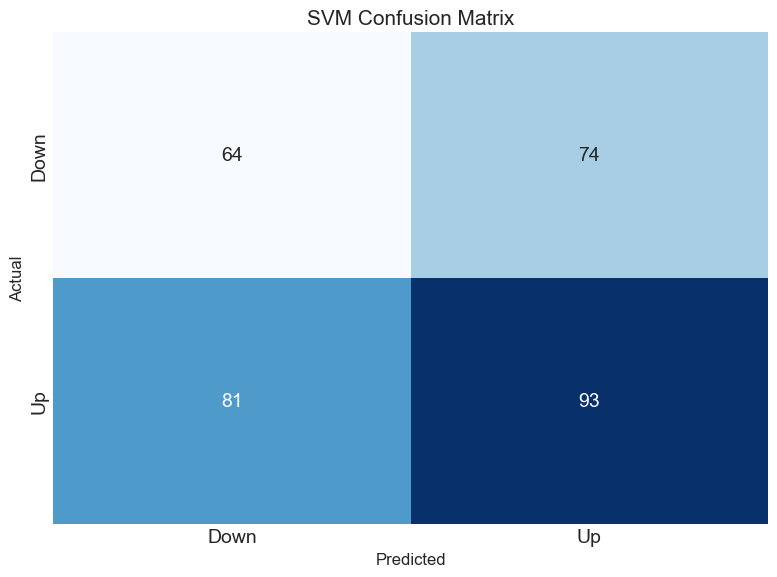


Backtesting SVM trading strategy...
Total Trading Days: 312
Profitable Days: 93 (29.81%)
Net Return: 15.25%
Buy & Hold Return: 44.06%
Max Drawdown: -11.47%
Annualized Sharpe Ratio: 0.8013


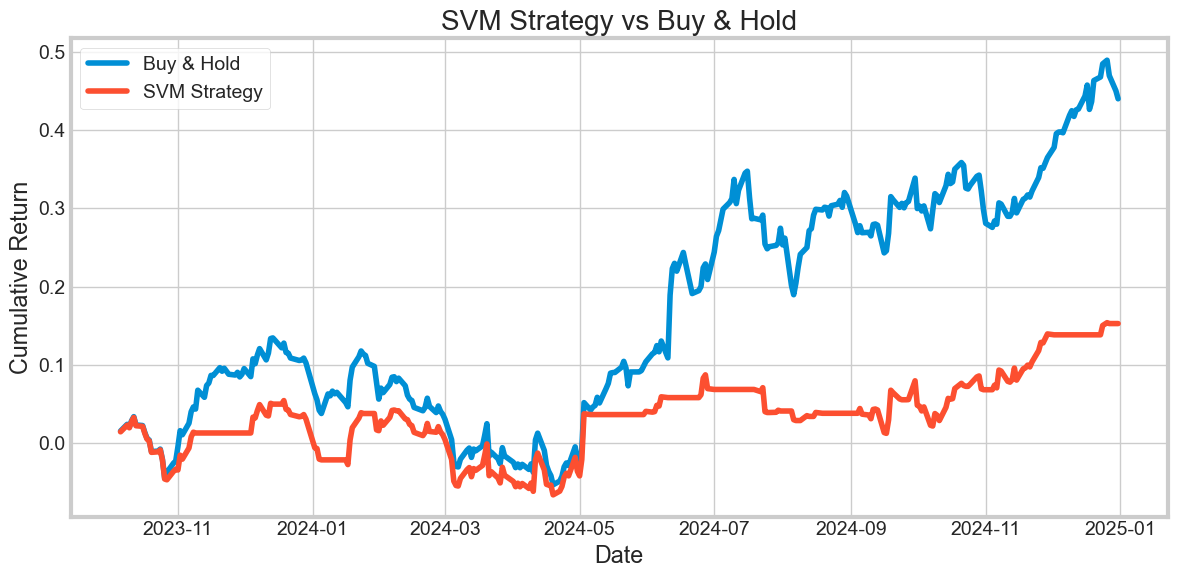

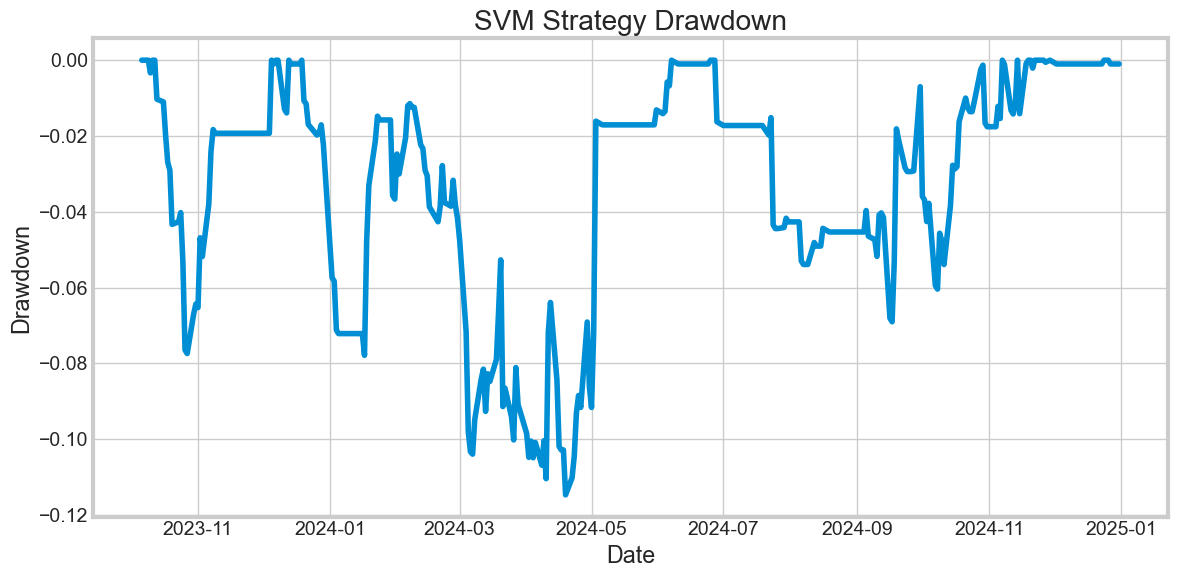


Evaluating KNN

Evaluating KNN...
Accuracy: 0.4679
F1 Score: 0.5030
Confusion Matrix:
[[62 76]
 [90 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43       138
           1       0.53      0.48      0.50       174

    accuracy                           0.47       312
   macro avg       0.47      0.47      0.47       312
weighted avg       0.47      0.47      0.47       312



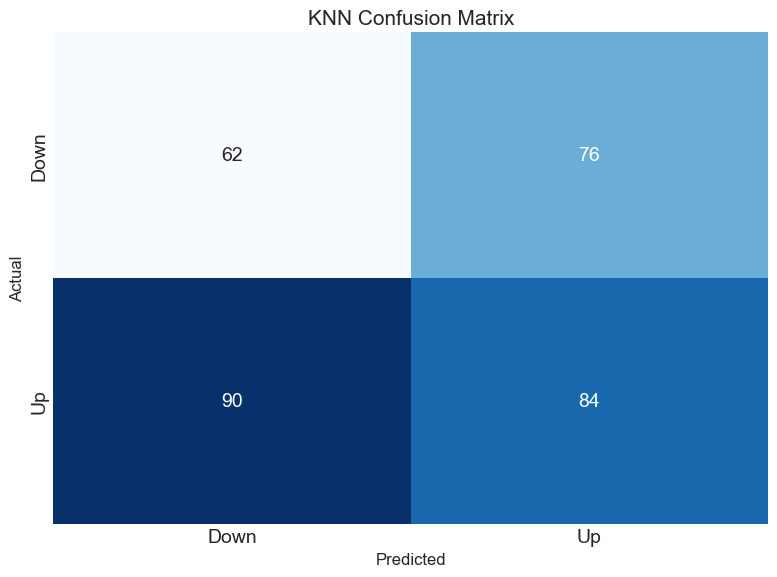


Backtesting KNN trading strategy...
Total Trading Days: 312
Profitable Days: 82 (26.28%)
Net Return: -4.01%
Buy & Hold Return: 44.06%
Max Drawdown: -16.10%
Annualized Sharpe Ratio: -0.1361


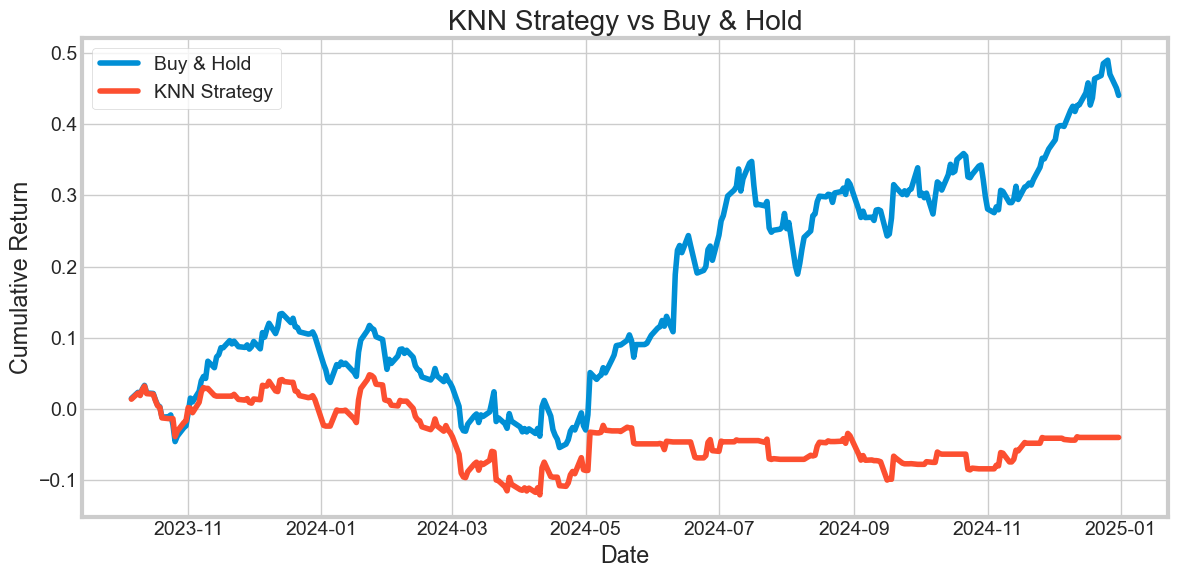

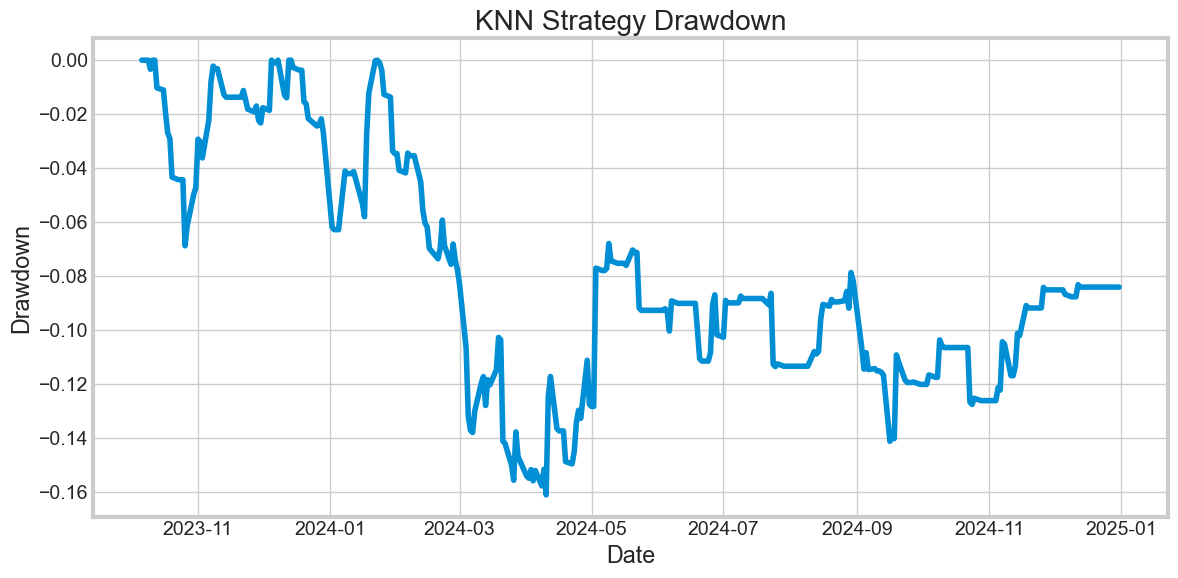


Evaluating Neural Network

Evaluating Neural Network...
Accuracy: 0.4679
F1 Score: 0.5174
Confusion Matrix:
[[57 81]
 [85 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.41      0.41       138
           1       0.52      0.51      0.52       174

    accuracy                           0.47       312
   macro avg       0.46      0.46      0.46       312
weighted avg       0.47      0.47      0.47       312



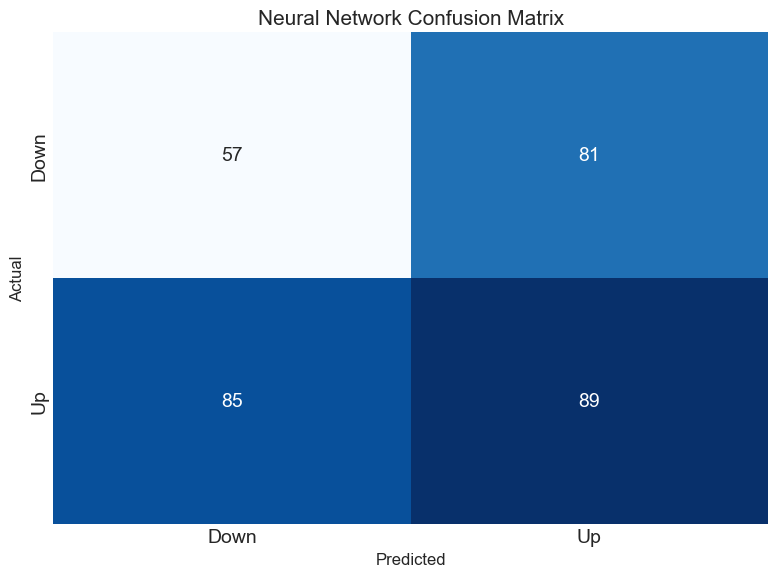


Backtesting Neural Network trading strategy...
Total Trading Days: 312
Profitable Days: 86 (27.56%)
Net Return: -1.03%
Buy & Hold Return: 44.06%
Max Drawdown: -14.66%
Annualized Sharpe Ratio: 0.0200


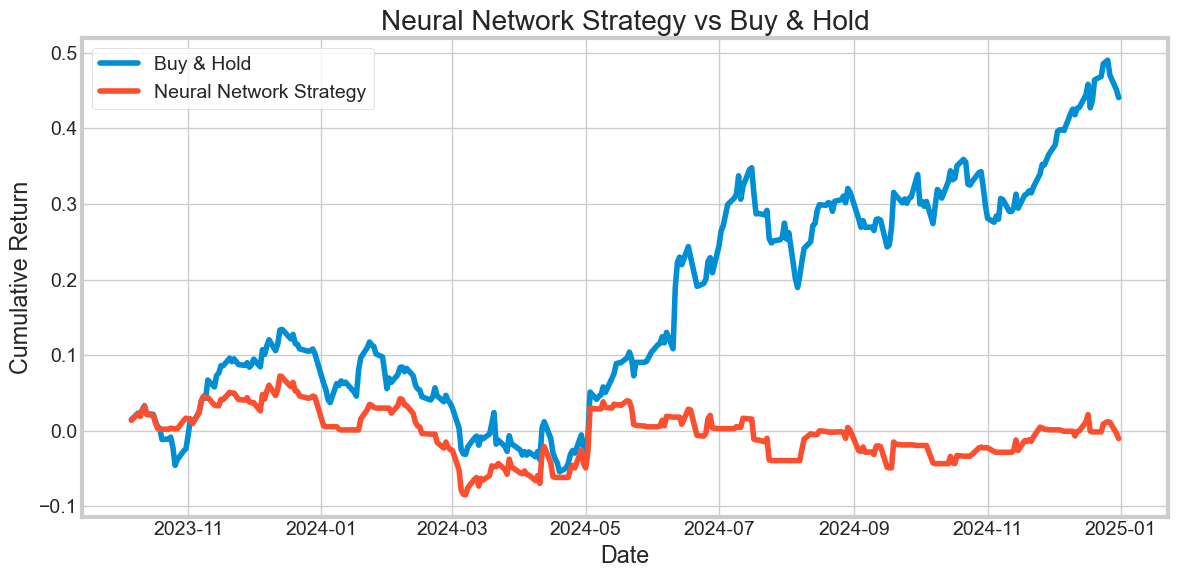

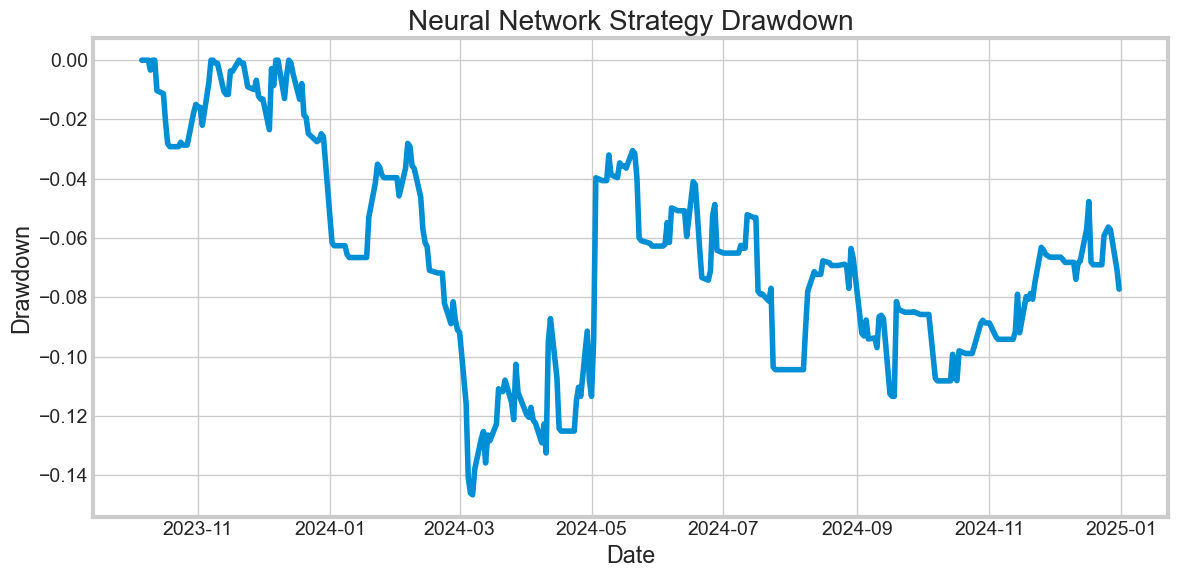


Evaluating Naive Bayes

Evaluating Naive Bayes...
Accuracy: 0.4455
F1 Score: 0.0114
Confusion Matrix:
[[138   0]
 [173   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      1.00      0.61       138
           1       1.00      0.01      0.01       174

    accuracy                           0.45       312
   macro avg       0.72      0.50      0.31       312
weighted avg       0.75      0.45      0.28       312



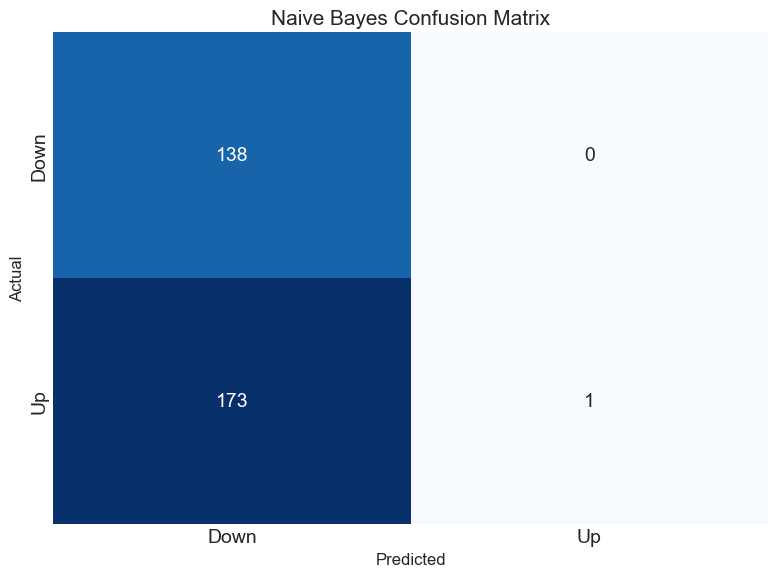


Backtesting Naive Bayes trading strategy...
Total Trading Days: 312
Profitable Days: 1 (0.32%)
Net Return: 0.31%
Buy & Hold Return: 44.06%
Max Drawdown: -0.10%
Annualized Sharpe Ratio: 0.6602


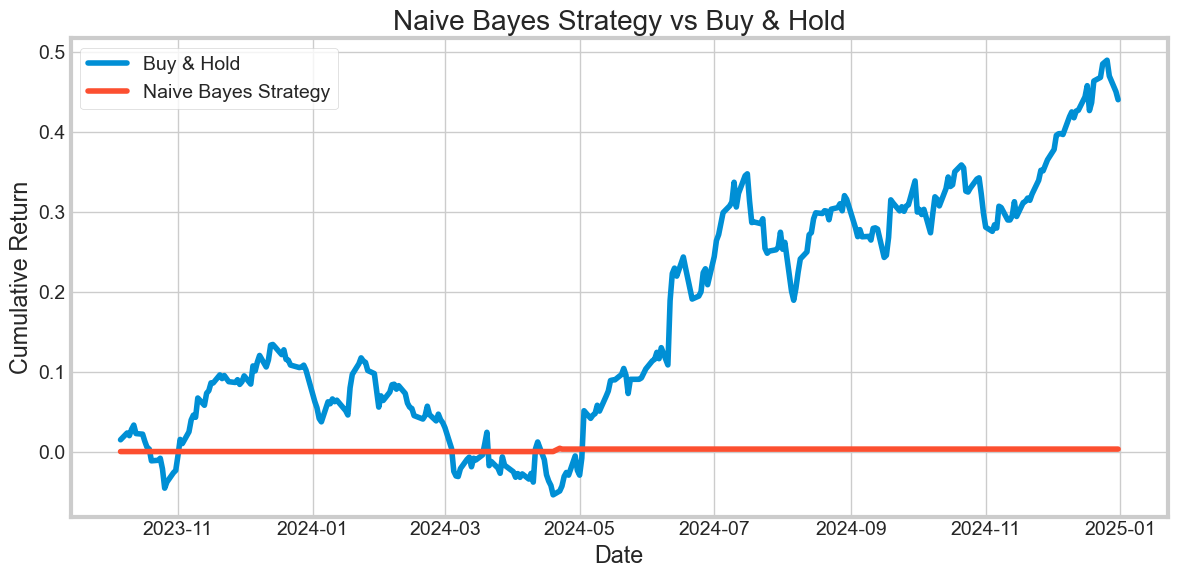

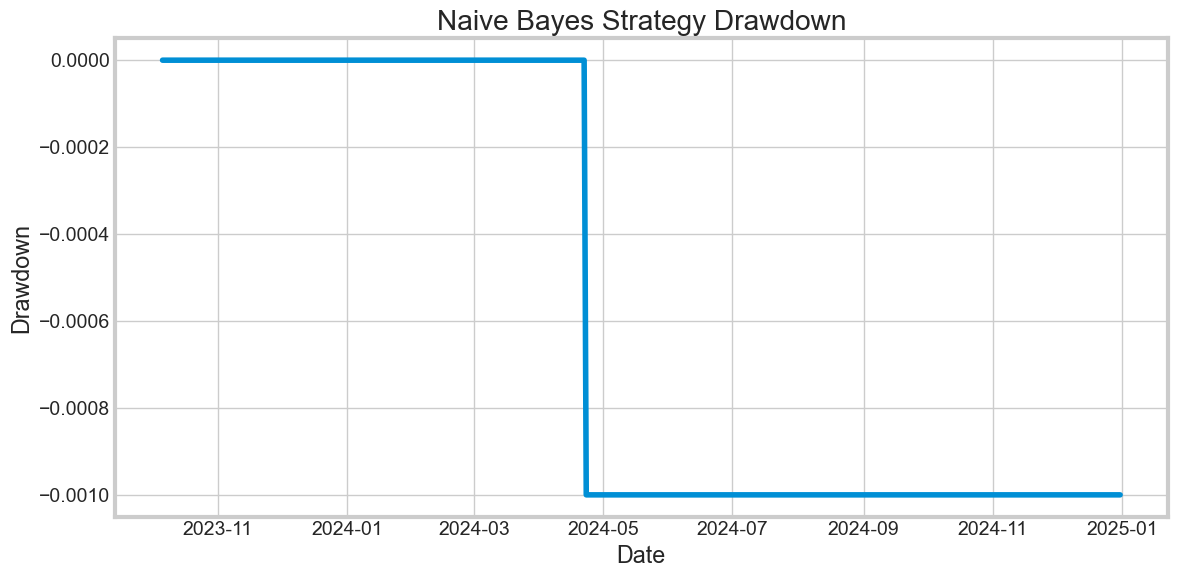


Evaluating Decision Tree

Top 10 Important Features (Decision Tree):
         Feature  Importance
7      Return_1d      0.3748
10          MACD      0.1191
13      BB_Width      0.1028
0           MA_5      0.1009
1          MA_10      0.0864
11   MACD_Signal      0.0754
16  Volume_Ratio      0.0659
6         EMA_20      0.0385
3          MA_50      0.0361
8      Return_5d      0.0000

Evaluating Decision Tree...
Accuracy: 0.5641
F1 Score: 0.7131
Confusion Matrix:
[[  7 131]
 [  5 169]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.05      0.09       138
           1       0.56      0.97      0.71       174

    accuracy                           0.56       312
   macro avg       0.57      0.51      0.40       312
weighted avg       0.57      0.56      0.44       312



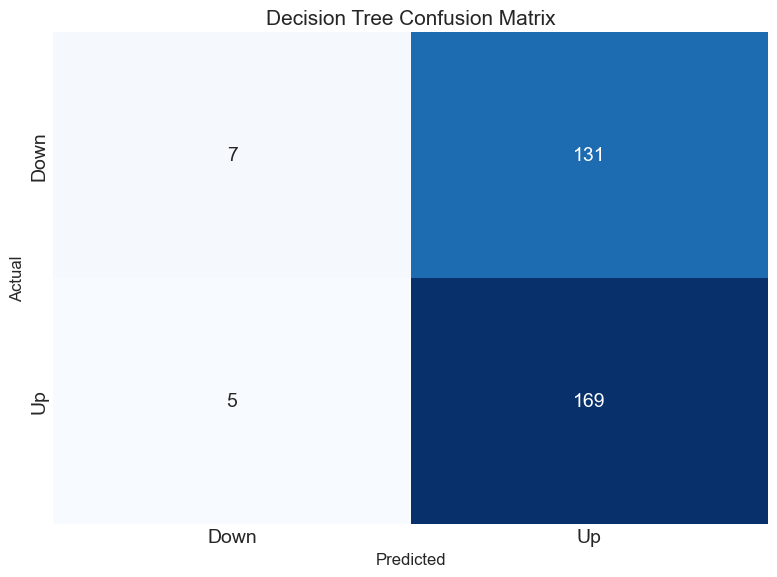


Backtesting Decision Tree trading strategy...
Total Trading Days: 312
Profitable Days: 168 (53.85%)
Net Return: 48.81%
Buy & Hold Return: 44.06%
Max Drawdown: -13.99%
Annualized Sharpe Ratio: 1.6298


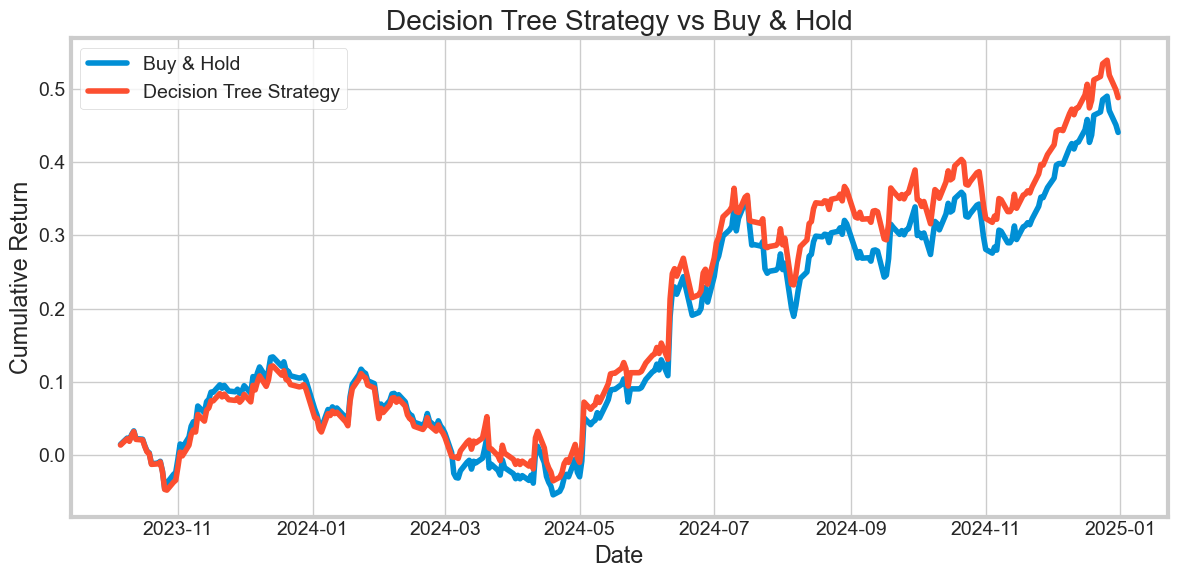

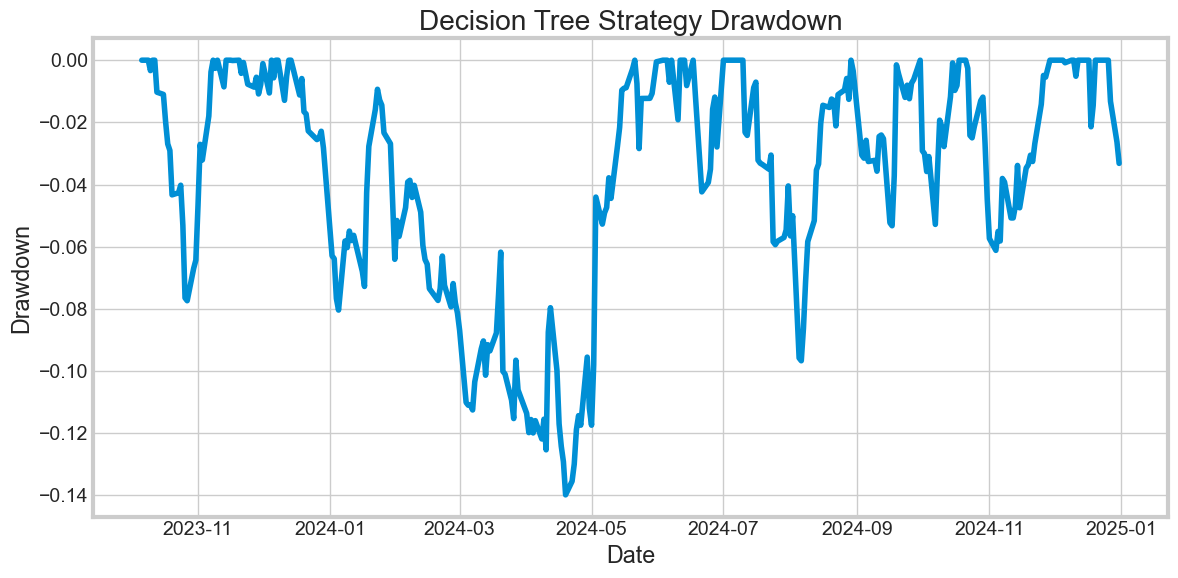


Evaluating AdaBoost

Top 10 Important Features (AdaBoost):
             Feature  Importance
7          Return_1d      0.2162
9                RSI      0.1292
14      HL_Range_Pct      0.1197
8          Return_5d      0.0728
0               MA_5      0.0684
5             EMA_10      0.0532
2              MA_20      0.0517
16      Volume_Ratio      0.0514
15  Price_Change_Pct      0.0513
1              MA_10      0.0440

Evaluating AdaBoost...
Accuracy: 0.4455
F1 Score: 0.3216
Confusion Matrix:
[[ 98  40]
 [133  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.71      0.53       138
           1       0.51      0.24      0.32       174

    accuracy                           0.45       312
   macro avg       0.47      0.47      0.43       312
weighted avg       0.47      0.45      0.41       312



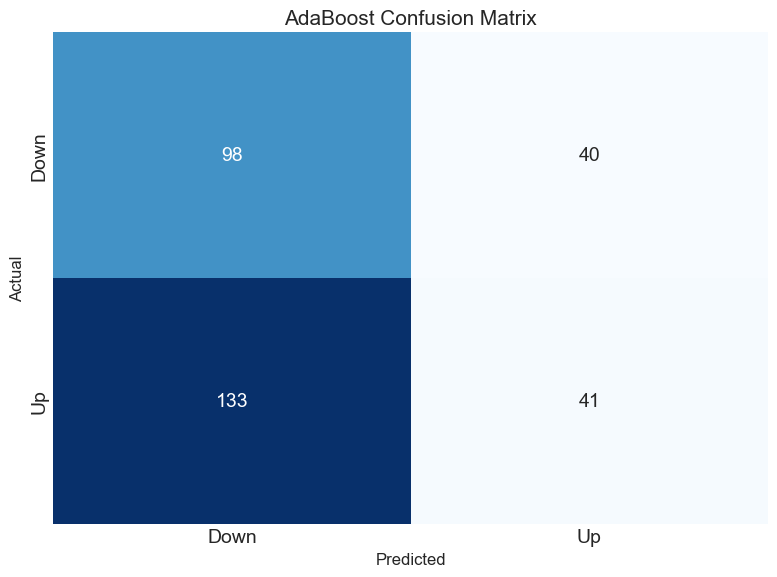


Backtesting AdaBoost trading strategy...
Total Trading Days: 312
Profitable Days: 41 (13.14%)
Net Return: -2.71%
Buy & Hold Return: 44.06%
Max Drawdown: -10.38%
Annualized Sharpe Ratio: -0.1827


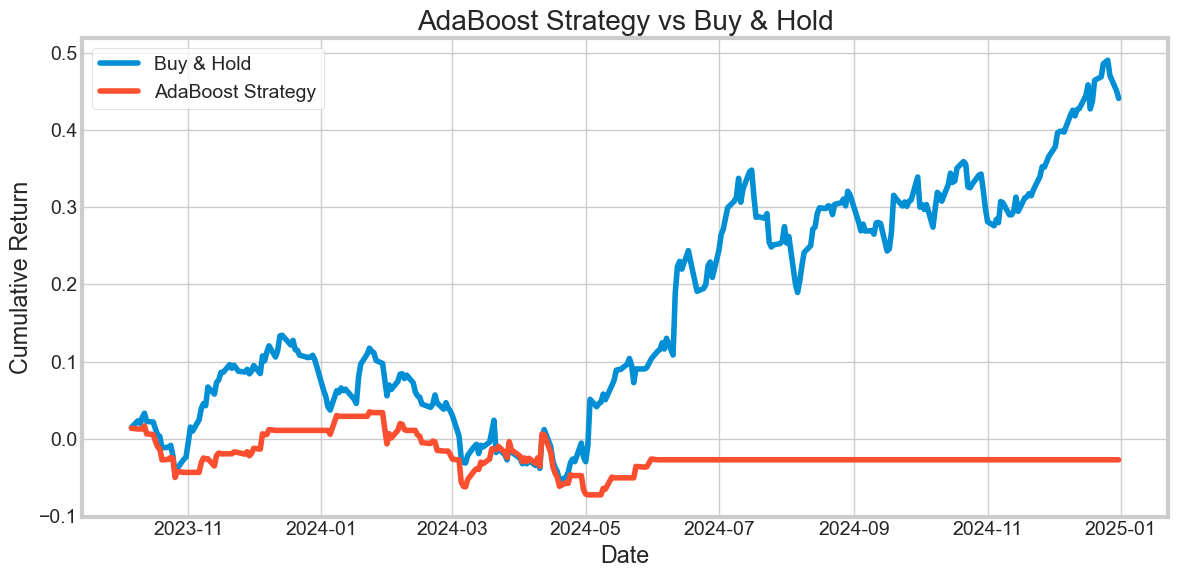

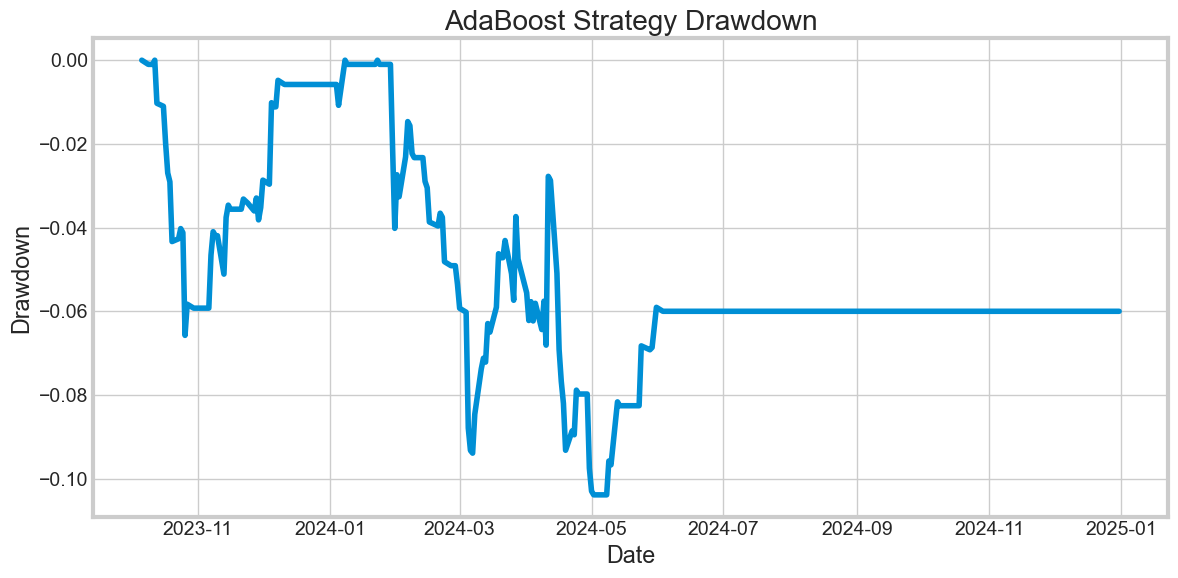


Evaluating Gradient Boosting

Top 10 Important Features (Gradient Boosting):
             Feature  Importance
13          BB_Width      0.1268
7          Return_1d      0.1189
16      Volume_Ratio      0.1057
9                RSI      0.0869
8          Return_5d      0.0858
10              MACD      0.0757
15  Price_Change_Pct      0.0739
14      HL_Range_Pct      0.0576
12         MACD_Hist      0.0455
11       MACD_Signal      0.0391

Evaluating Gradient Boosting...
Accuracy: 0.4455
F1 Score: 0.3216
Confusion Matrix:
[[ 98  40]
 [133  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.71      0.53       138
           1       0.51      0.24      0.32       174

    accuracy                           0.45       312
   macro avg       0.47      0.47      0.43       312
weighted avg       0.47      0.45      0.41       312



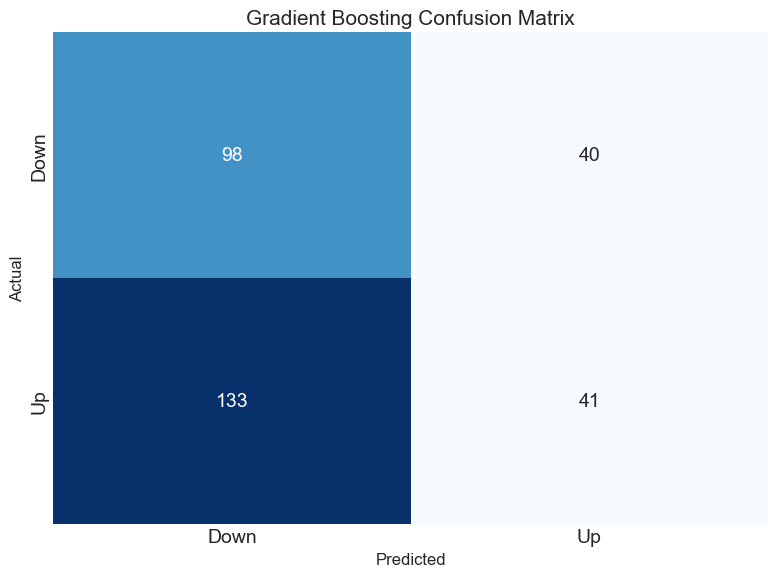


Backtesting Gradient Boosting trading strategy...
Total Trading Days: 312
Profitable Days: 41 (13.14%)
Net Return: 3.84%
Buy & Hold Return: 44.06%
Max Drawdown: -11.42%
Annualized Sharpe Ratio: 0.3378


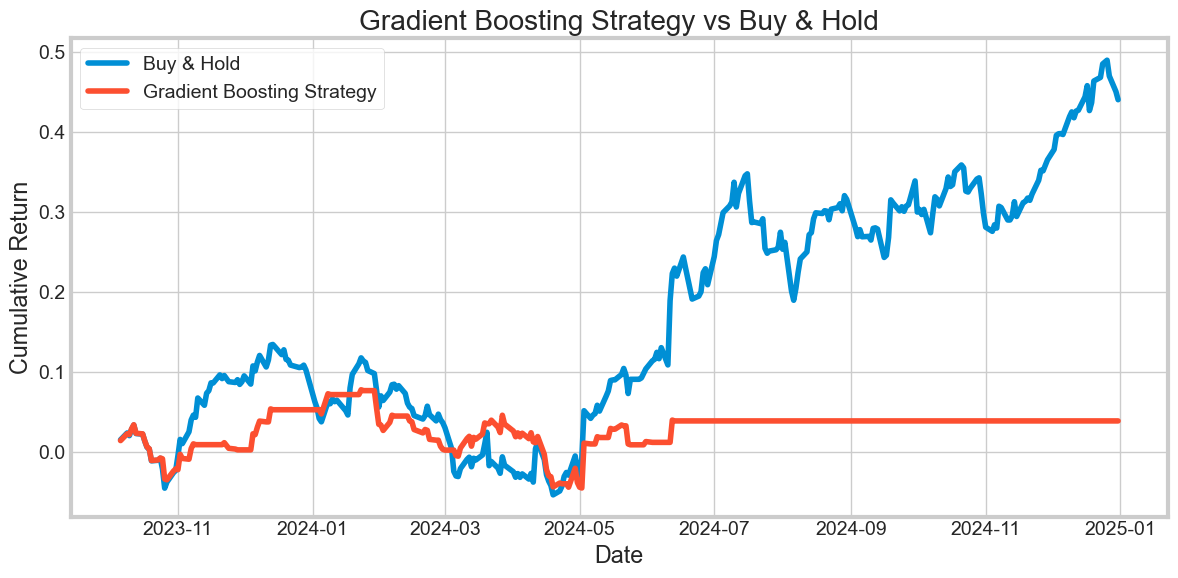

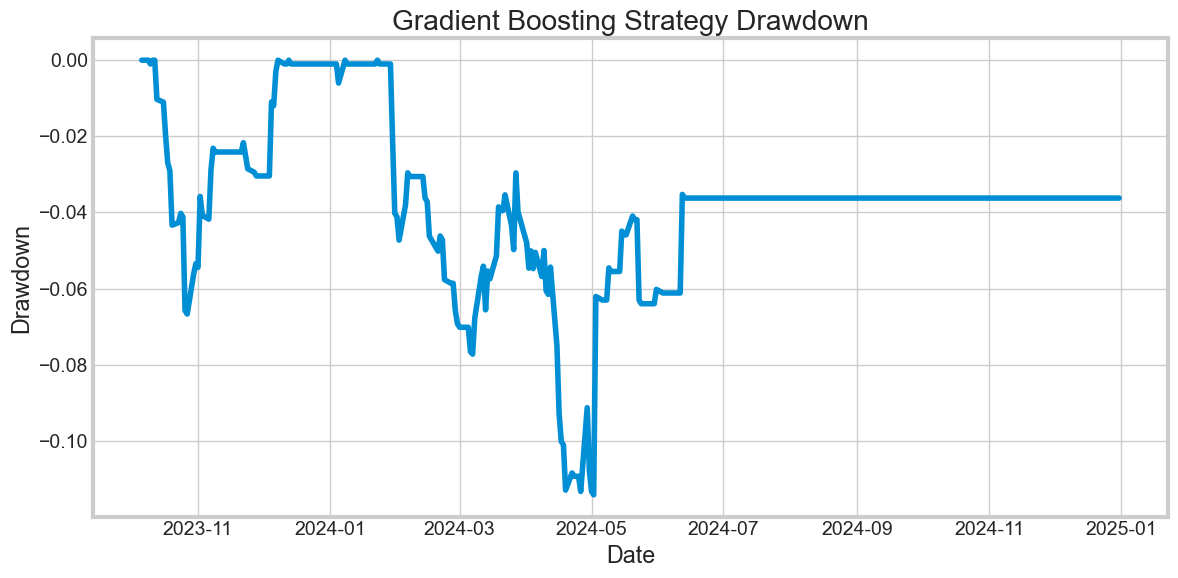


Evaluating XGBoost

Top 10 Important Features (XGBoost):
             Feature  Importance
5             EMA_10      0.0813
6             EMA_20      0.0711
10              MACD      0.0702
15  Price_Change_Pct      0.0673
7          Return_1d      0.0658
1              MA_10      0.0647
16      Volume_Ratio      0.0632
13          BB_Width      0.0617
0               MA_5      0.0616
14      HL_Range_Pct      0.0599

Evaluating XGBoost...
Accuracy: 0.4423
F1 Score: 0.3650
Confusion Matrix:
[[ 88  50]
 [124  50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.64      0.50       138
           1       0.50      0.29      0.36       174

    accuracy                           0.44       312
   macro avg       0.46      0.46      0.43       312
weighted avg       0.46      0.44      0.43       312



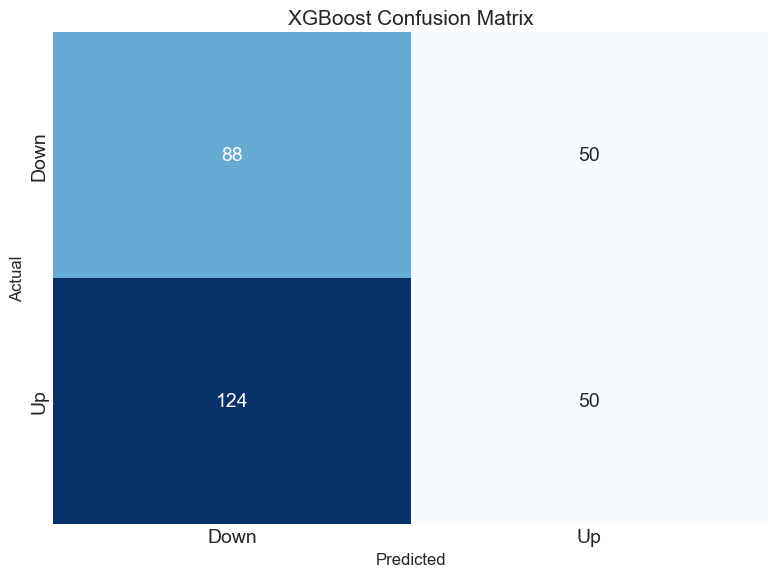


Backtesting XGBoost trading strategy...
Total Trading Days: 312
Profitable Days: 49 (15.71%)
Net Return: -7.93%
Buy & Hold Return: 44.06%
Max Drawdown: -17.50%
Annualized Sharpe Ratio: -0.5389


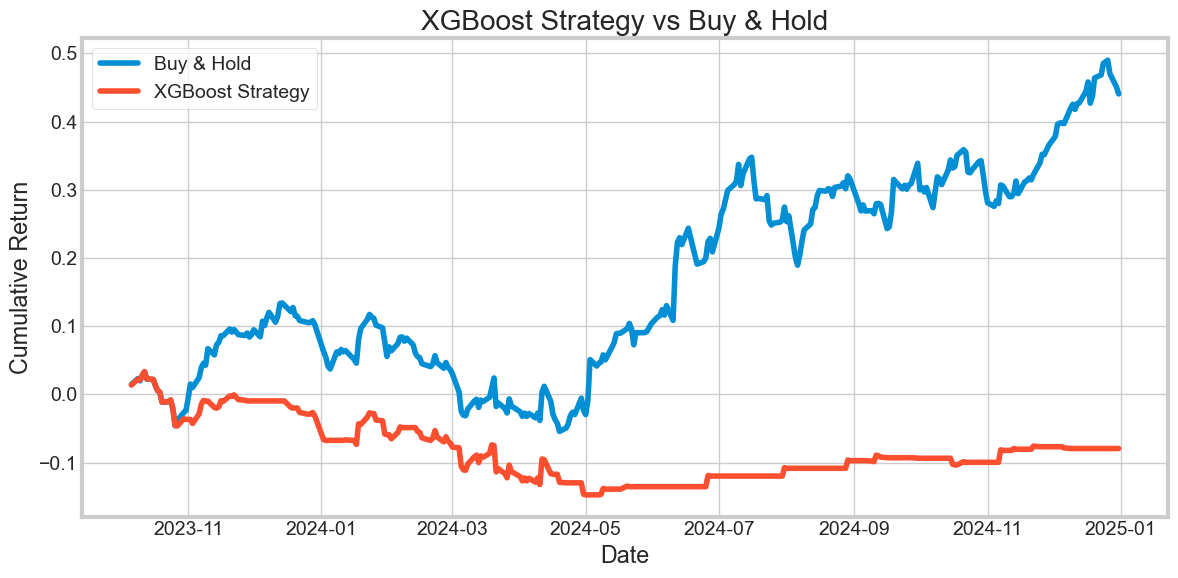

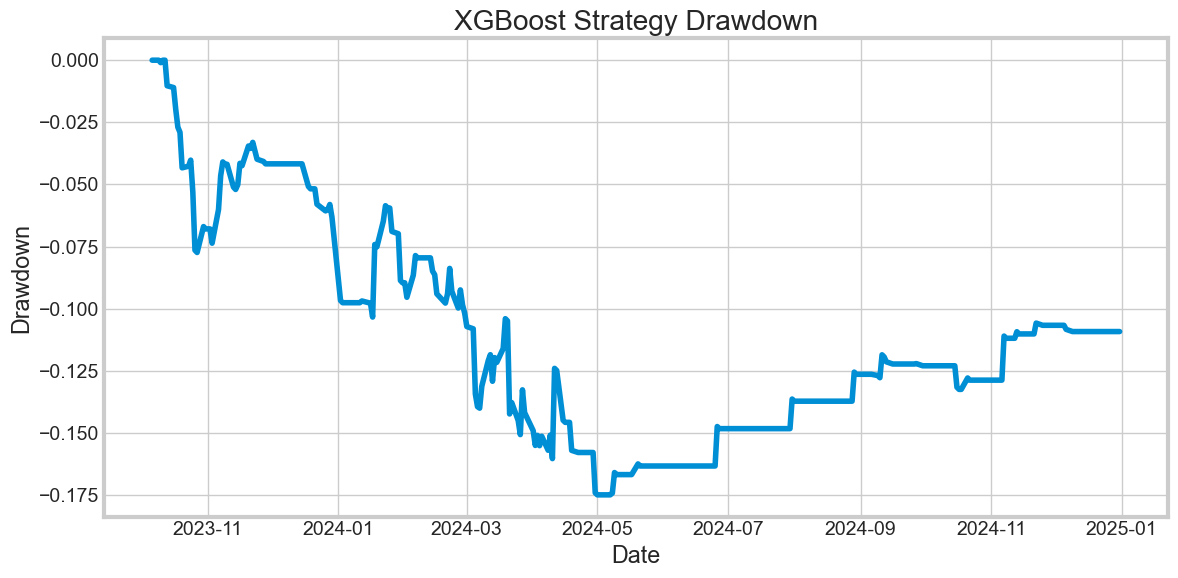

Model Comparison:
                 Model  Accuracy  F1 Score  Net Return  Max Drawdown  \
0  Logistic Regression    0.4679    0.5489      0.1623       -0.1692   
1        Random Forest    0.4391    0.3682      0.0994       -0.1294   
2                  SVM    0.5032    0.5455      0.1525       -0.1147   
3                  KNN    0.4679    0.5030     -0.0401       -0.1610   
4       Neural Network    0.4679    0.5174     -0.0103       -0.1466   
5          Naive Bayes    0.4455    0.0114      0.0031       -0.0010   
6        Decision Tree    0.5641    0.7131      0.4881       -0.1399   
7             AdaBoost    0.4455    0.3216     -0.0271       -0.1038   
8    Gradient Boosting    0.4455    0.3216      0.0384       -0.1142   
9              XGBoost    0.4423    0.3650     -0.0793       -0.1750   

   Sharpe Ratio  
0        0.8026  
1        0.6613  
2        0.8013  
3       -0.1361  
4        0.0200  
5        0.6602  
6        1.6298  
7       -0.1827  
8        0.3378  
9       -

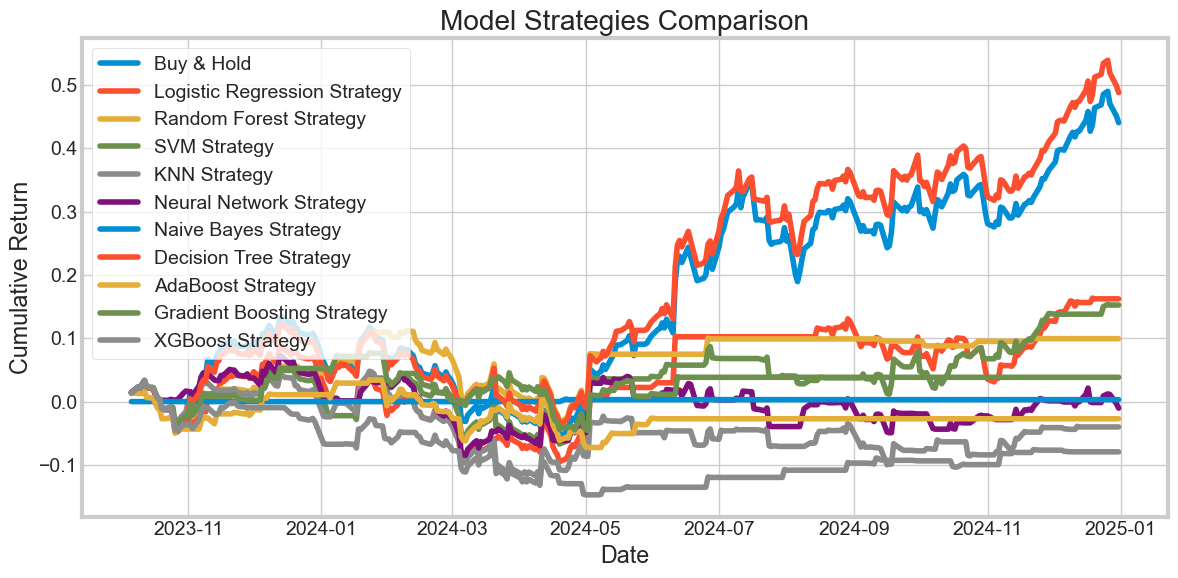

[*********************100%***********************]  1 of 1 completed

Downloaded data shape: (1259, 5)
Detected multi-level columns, flattening structure...
Cleaning data...
Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Removing 3 volume outliers
Data shape after cleaning: (1256, 5)
DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume']
DataFrame shape: (1256, 5)


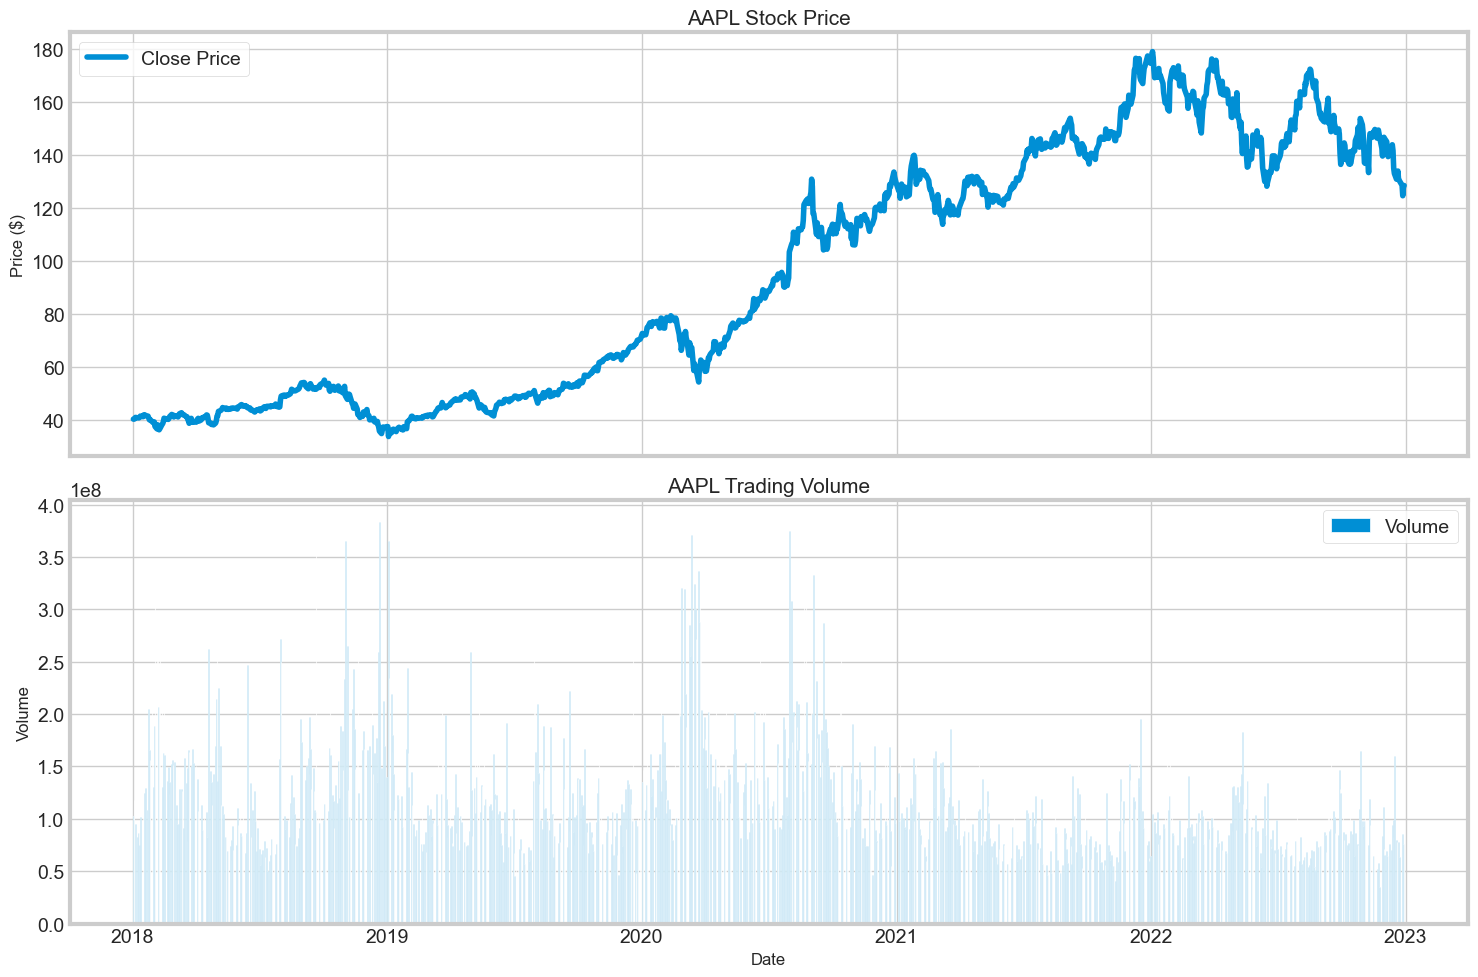

Generating technical features...
Dropped 199 rows with NaN values
Final dataset shape: (1057, 35)


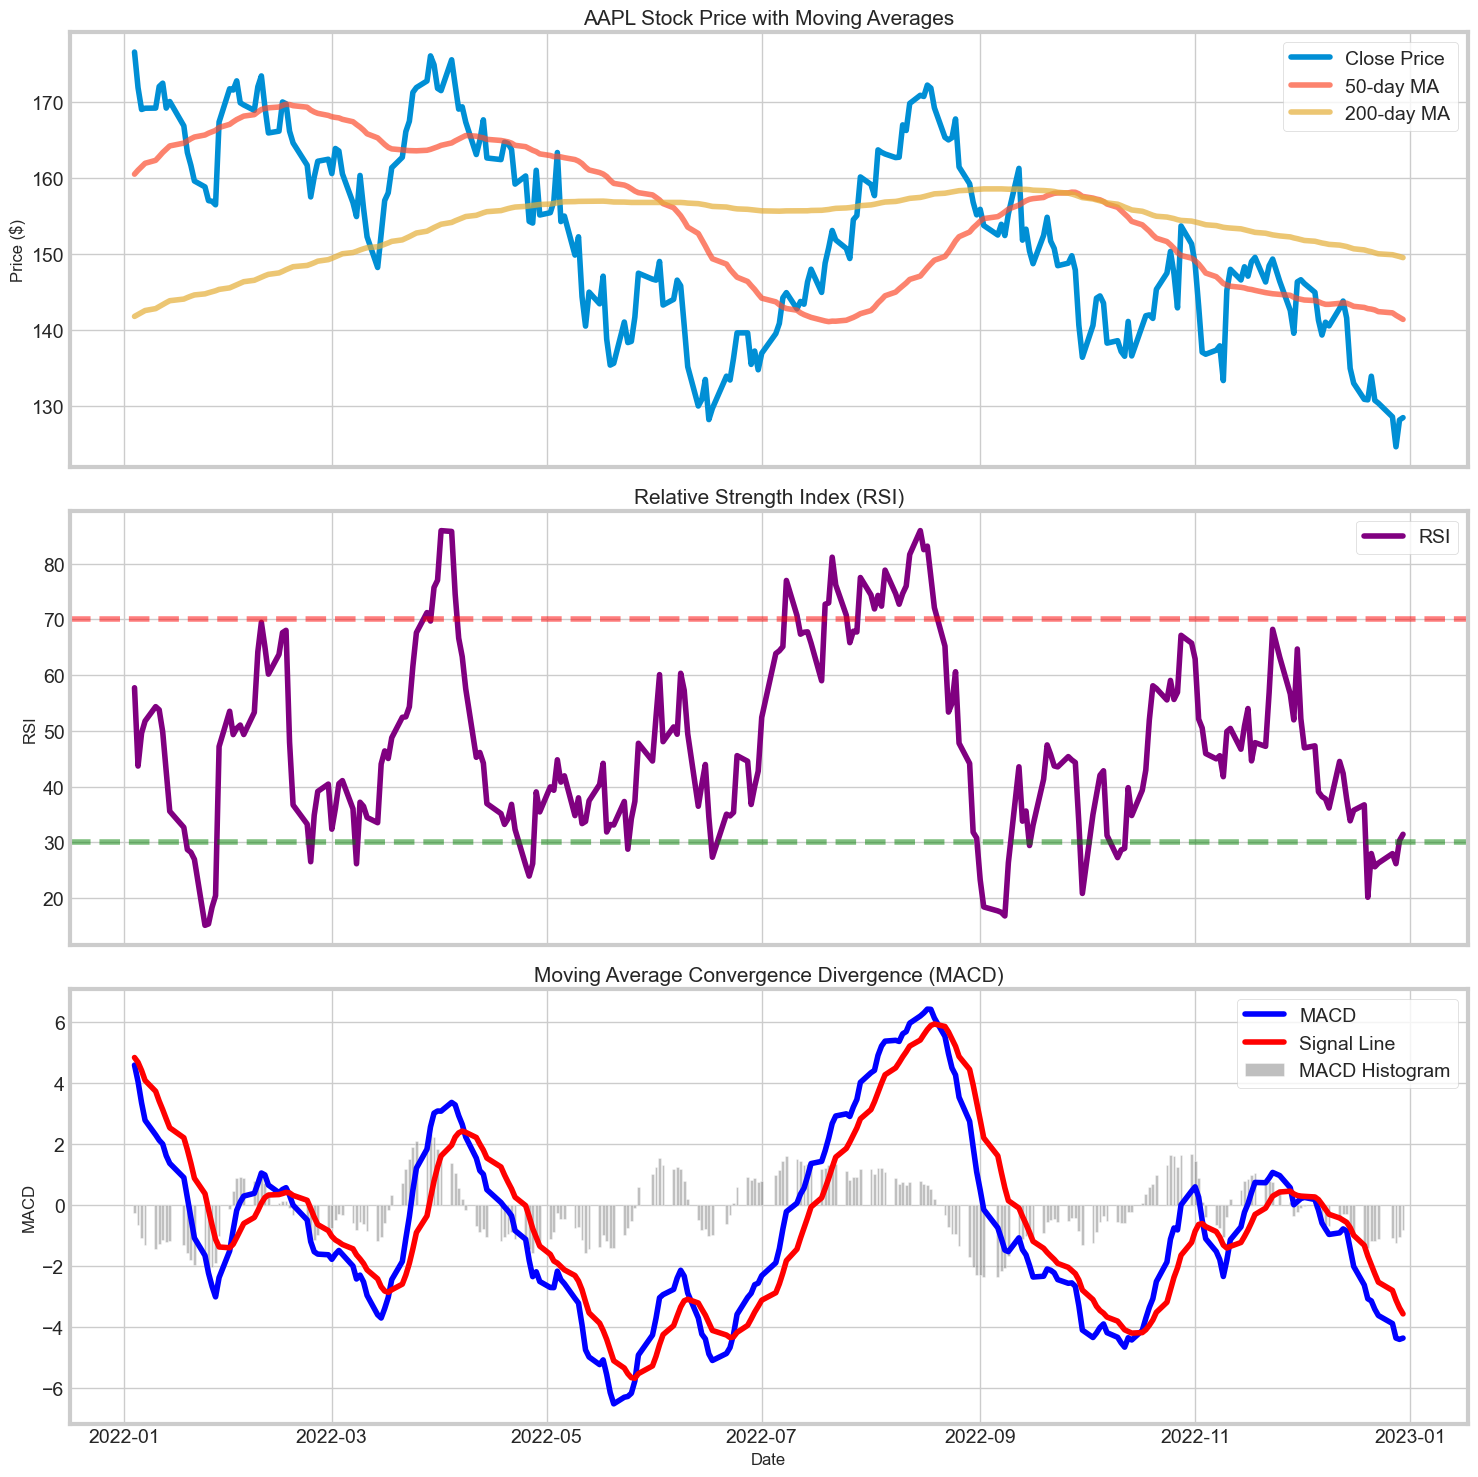

Target Distribution:
0 (Down): 500 samples (47.30%)
1 (Up): 557 samples (52.70%)


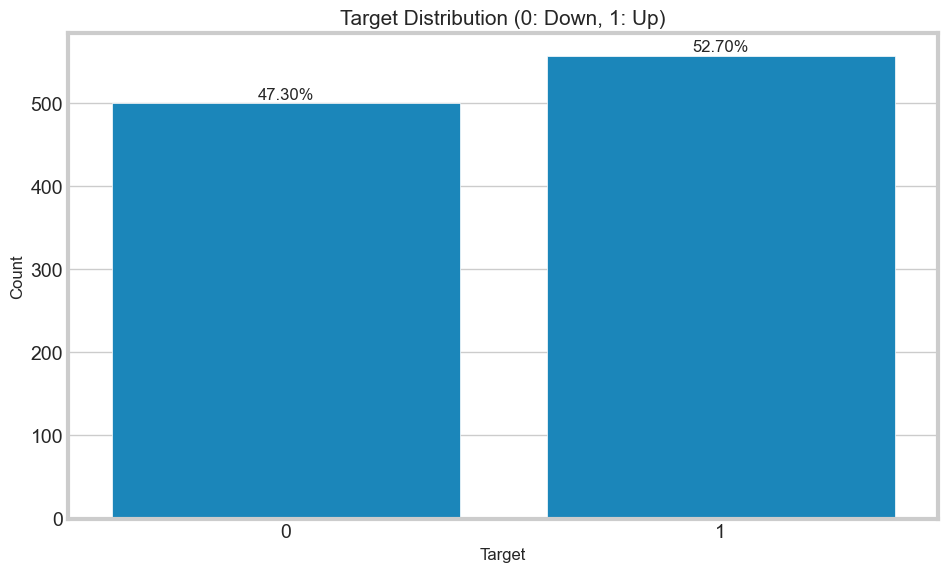

Train set: 845 samples (2018-10-16 00:00:00 to 2022-02-28 00:00:00)
Test set: 212 samples (2022-03-01 00:00:00 to 2022-12-30 00:00:00)
Training Logistic Regression model...
Training Random Forest model...
Training SVM model...
Note: SVM with non-linear kernel doesn't provide direct feature importance.
Training KNN model...
Note: KNN doesn't provide direct feature importance.
Training Neural Network model...
Note: Neural Network doesn't provide direct feature importance.
Training Naive Bayes model...
Note: Naive Bayes doesn't provide direct feature importance.
Training Decision Tree model...
Training AdaBoost model...
Training Gradient Boosting model...
Training XGBoost model...

Evaluating Logistic Regression

Top 10 Important Features (Logistic Regression):
             Feature  Importance
13          BB_Width      0.1865
7          Return_1d      0.1646
9                RSI      0.1309
1              MA_10      0.1087
2              MA_20      0.0909
15  Price_Change_Pct      0.0896


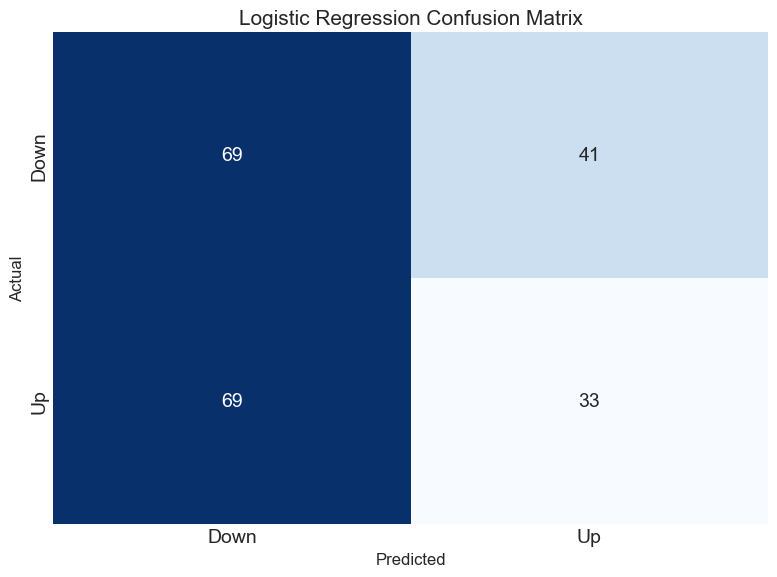


Backtesting Logistic Regression trading strategy...
Total Trading Days: 212
Profitable Days: 33 (15.57%)
Net Return: -23.65%
Buy & Hold Return: -20.03%
Max Drawdown: -27.03%
Annualized Sharpe Ratio: -1.1902


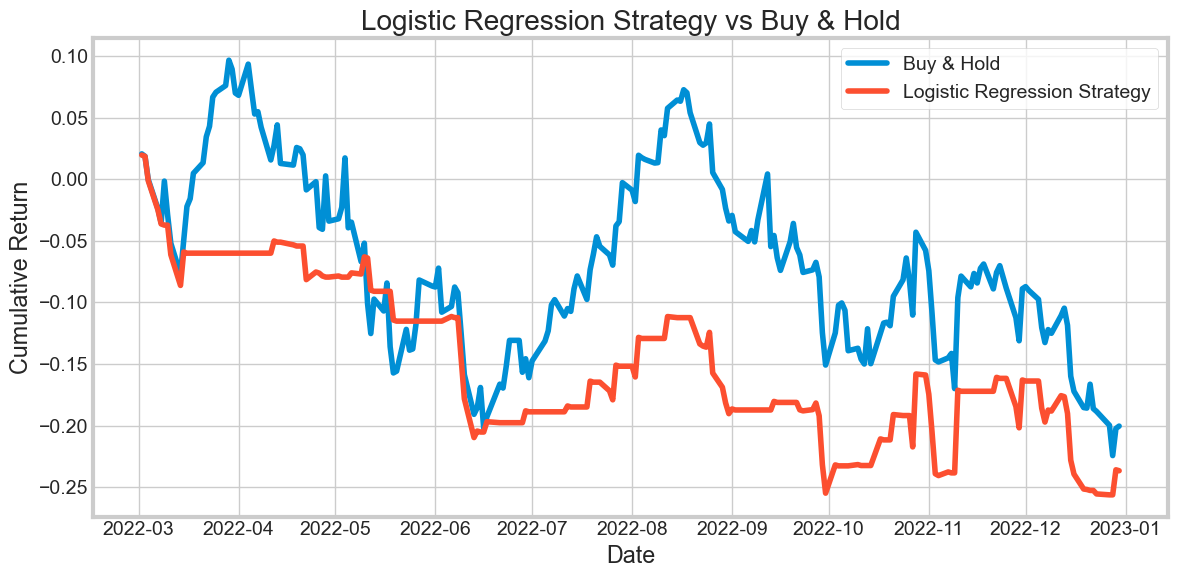

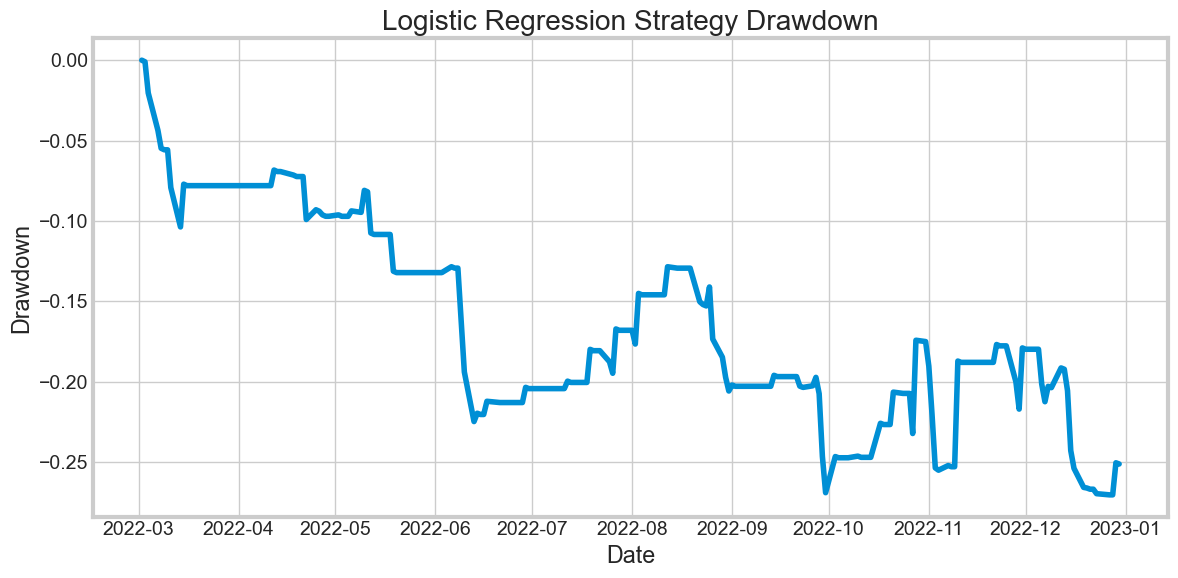


Evaluating Random Forest

Top 10 Important Features (Random Forest):
             Feature  Importance
15  Price_Change_Pct      0.0990
7          Return_1d      0.0949
13          BB_Width      0.0810
16      Volume_Ratio      0.0740
8          Return_5d      0.0717
9                RSI      0.0711
12         MACD_Hist      0.0642
11       MACD_Signal      0.0587
3              MA_50      0.0531
14      HL_Range_Pct      0.0526

Evaluating Random Forest...
Accuracy: 0.5755
F1 Score: 0.4767
Confusion Matrix:
[[81 29]
 [61 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.74      0.64       110
           1       0.59      0.40      0.48       102

    accuracy                           0.58       212
   macro avg       0.58      0.57      0.56       212
weighted avg       0.58      0.58      0.56       212



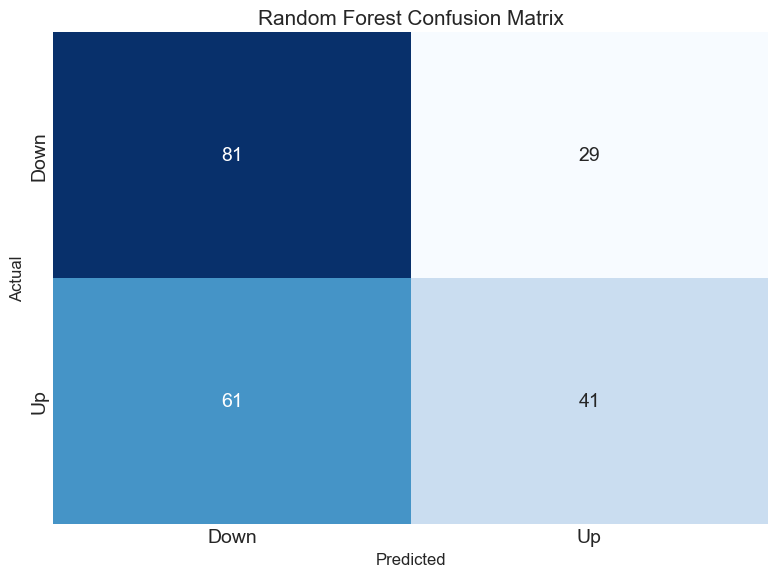


Backtesting Random Forest trading strategy...
Total Trading Days: 212
Profitable Days: 40 (18.87%)
Net Return: 5.17%
Buy & Hold Return: -20.03%
Max Drawdown: -11.05%
Annualized Sharpe Ratio: 0.3631


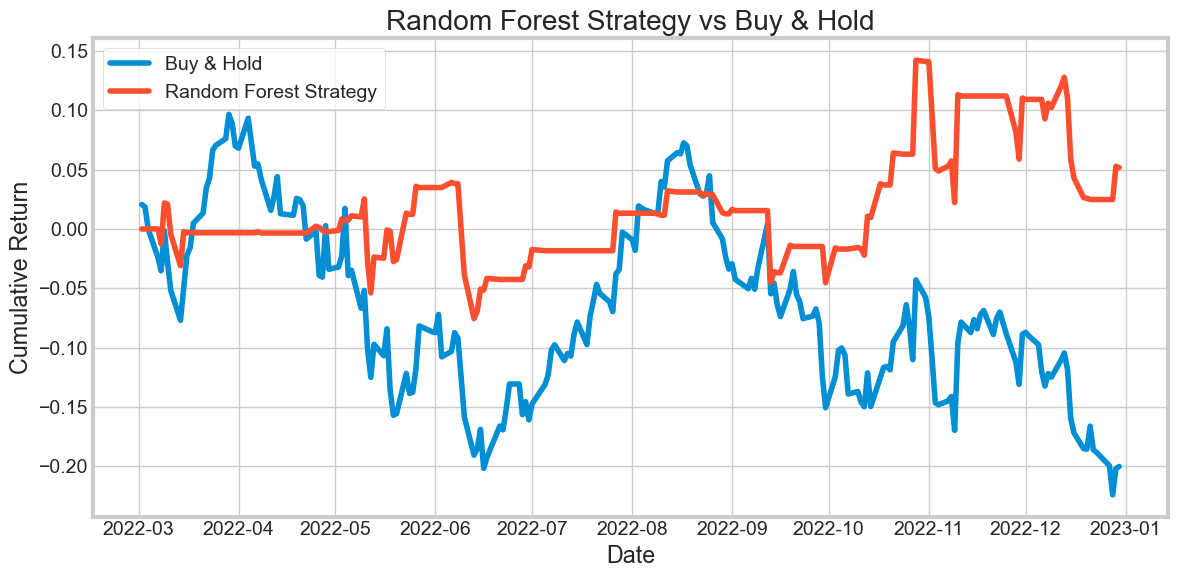

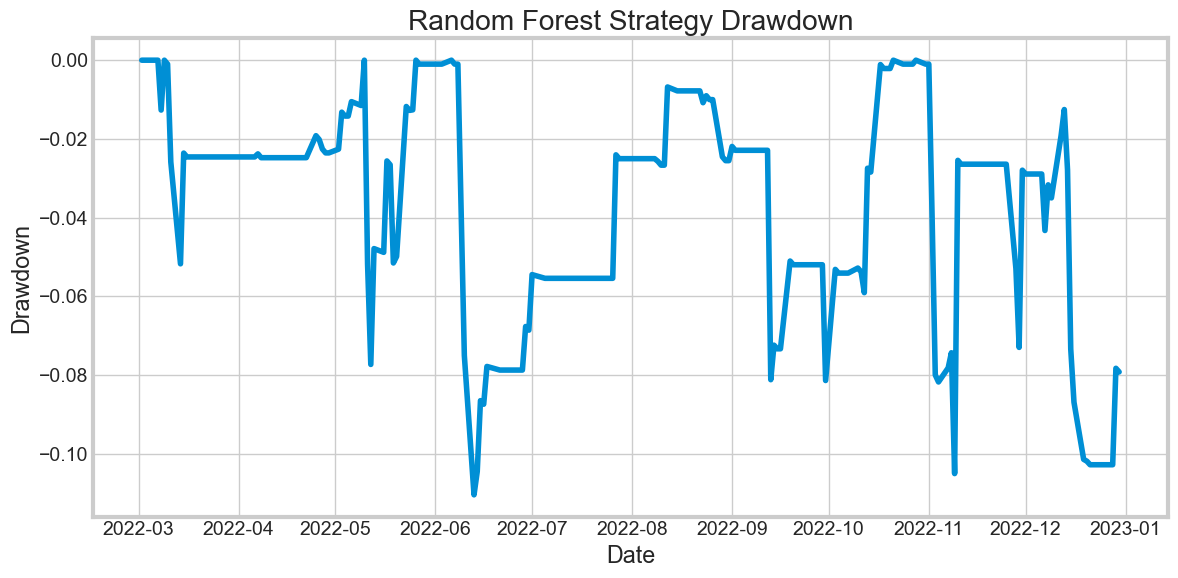


Evaluating SVM

Evaluating SVM...
Accuracy: 0.5330
F1 Score: 0.4277
Confusion Matrix:
[[76 34]
 [65 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.69      0.61       110
           1       0.52      0.36      0.43       102

    accuracy                           0.53       212
   macro avg       0.53      0.53      0.52       212
weighted avg       0.53      0.53      0.52       212



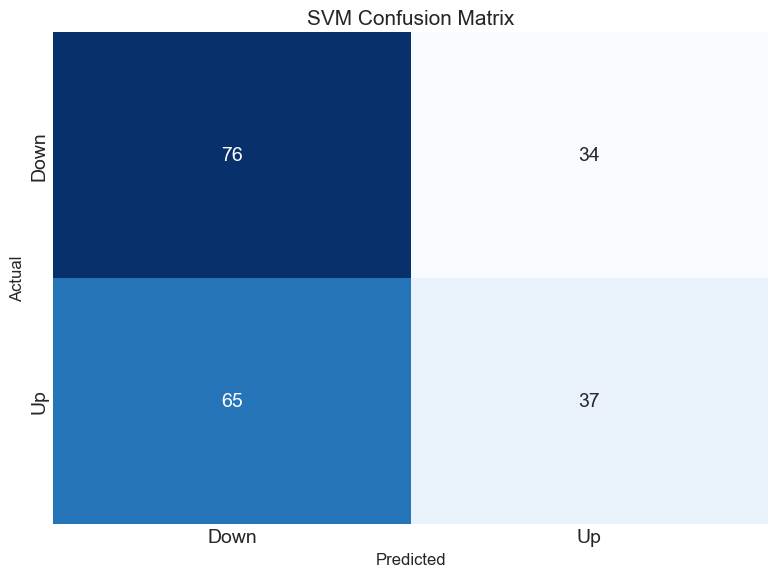


Backtesting SVM trading strategy...
Total Trading Days: 212
Profitable Days: 37 (17.45%)
Net Return: -5.45%
Buy & Hold Return: -20.03%
Max Drawdown: -19.72%
Annualized Sharpe Ratio: -0.1425


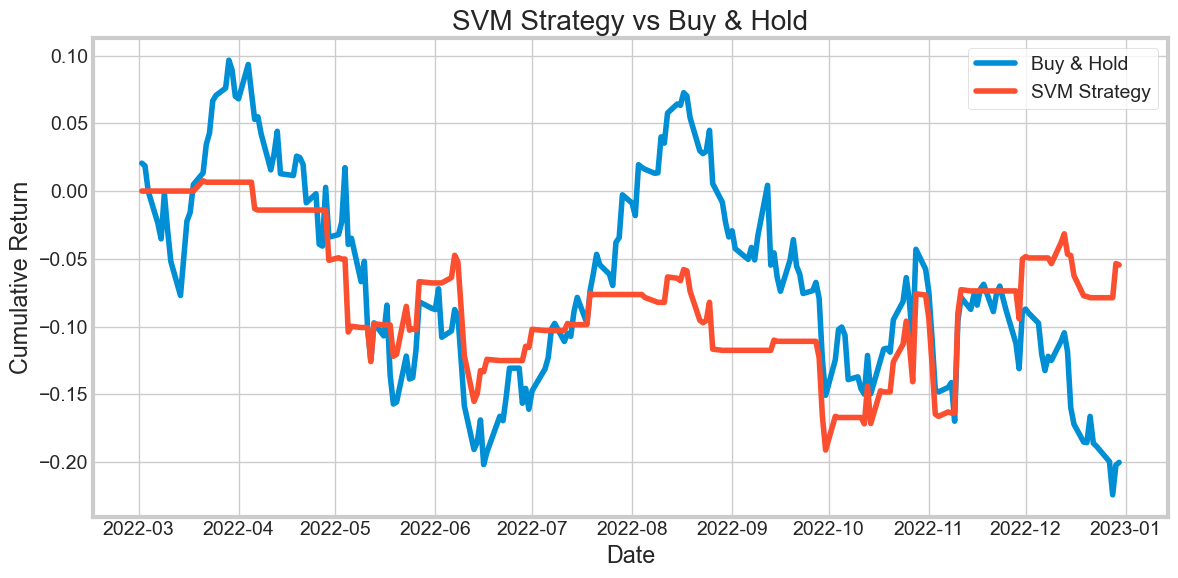

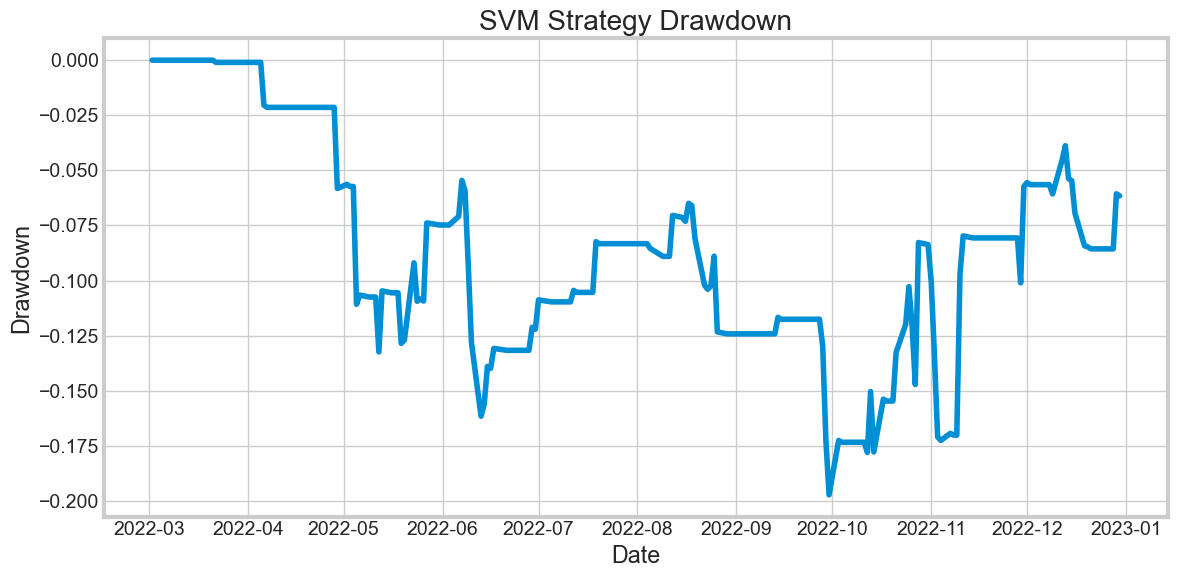


Evaluating KNN

Evaluating KNN...
Accuracy: 0.5047
F1 Score: 0.5161
Confusion Matrix:
[[51 59]
 [46 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.46      0.49       110
           1       0.49      0.55      0.52       102

    accuracy                           0.50       212
   macro avg       0.51      0.51      0.50       212
weighted avg       0.51      0.50      0.50       212



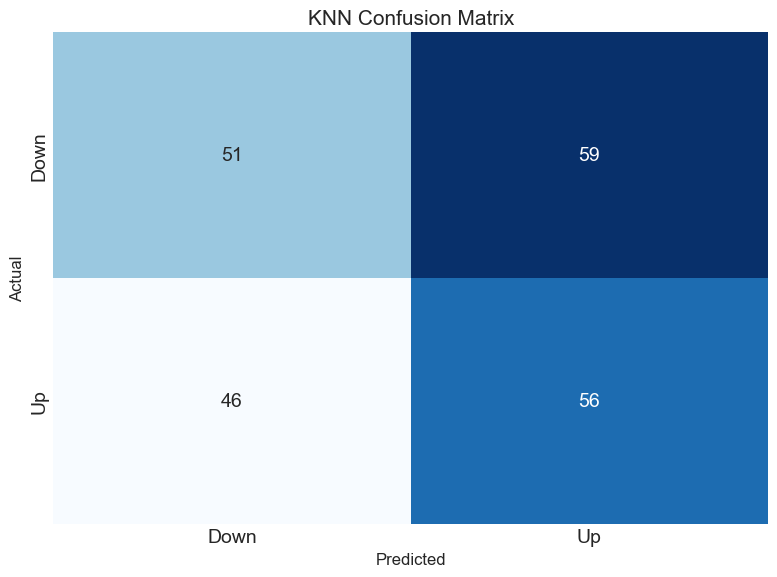


Backtesting KNN trading strategy...
Total Trading Days: 212
Profitable Days: 56 (26.42%)
Net Return: -22.02%
Buy & Hold Return: -20.03%
Max Drawdown: -30.08%
Annualized Sharpe Ratio: -0.9157


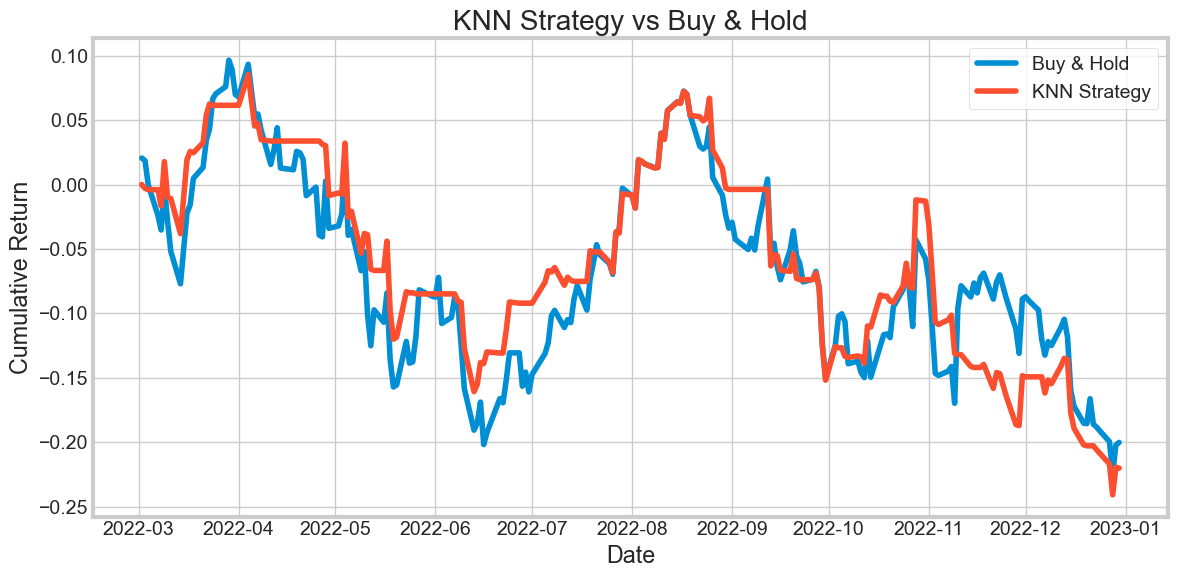

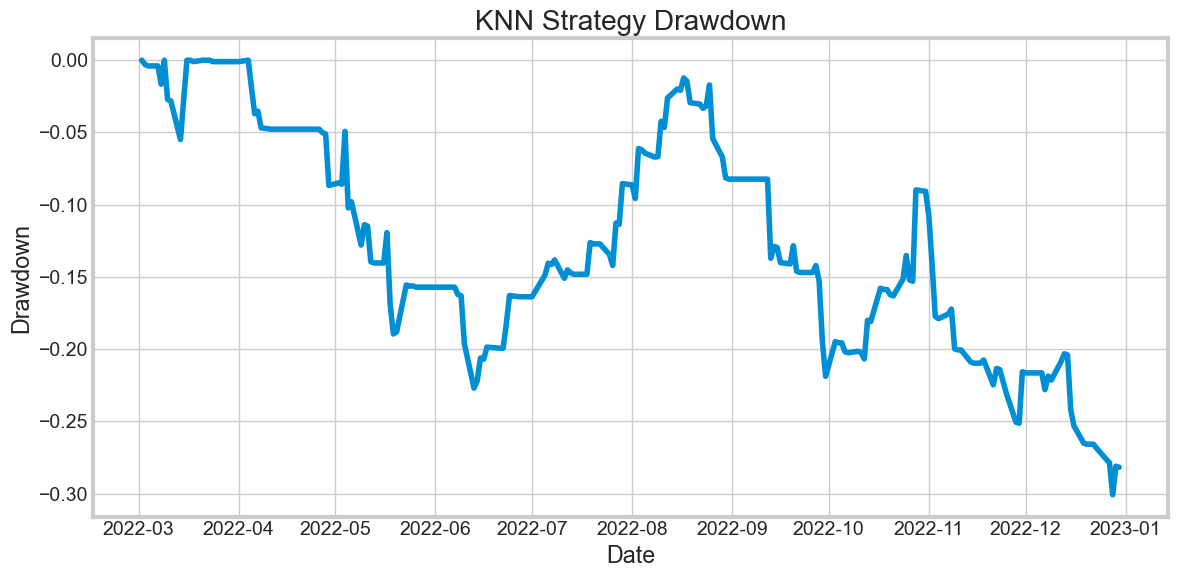


Evaluating Neural Network

Evaluating Neural Network...
Accuracy: 0.4811
F1 Score: 0.4811
Confusion Matrix:
[[51 59]
 [51 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       110
           1       0.46      0.50      0.48       102

    accuracy                           0.48       212
   macro avg       0.48      0.48      0.48       212
weighted avg       0.48      0.48      0.48       212



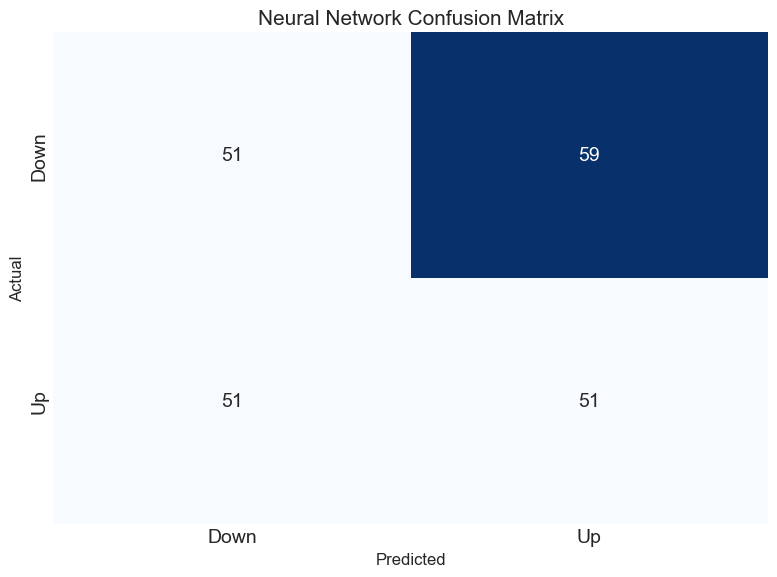


Backtesting Neural Network trading strategy...
Total Trading Days: 212
Profitable Days: 50 (23.58%)
Net Return: -32.49%
Buy & Hold Return: -20.03%
Max Drawdown: -37.21%
Annualized Sharpe Ratio: -1.5242


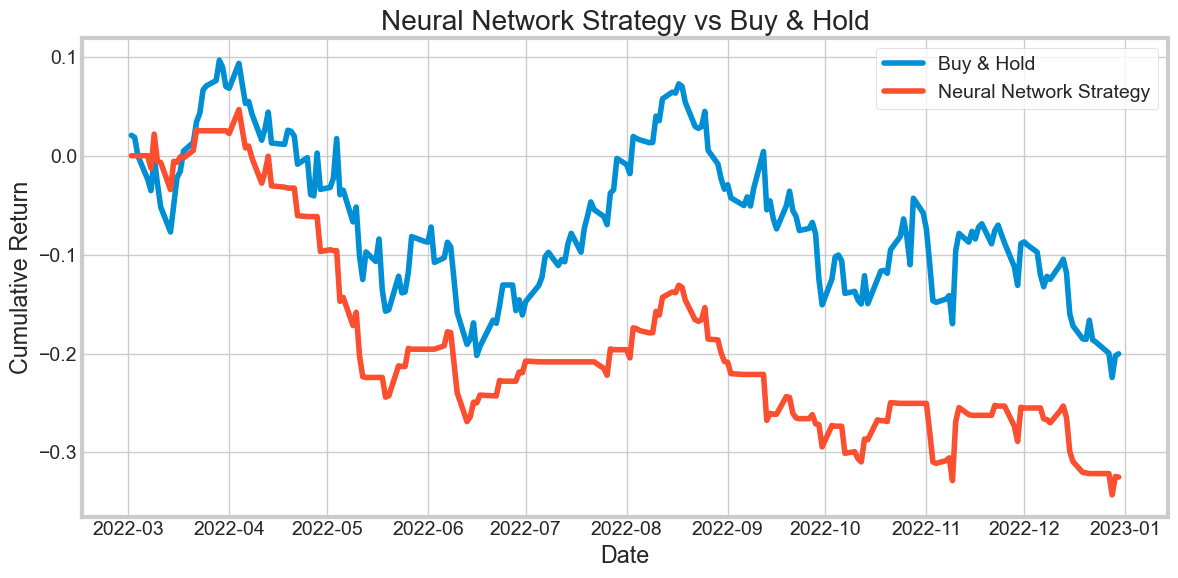

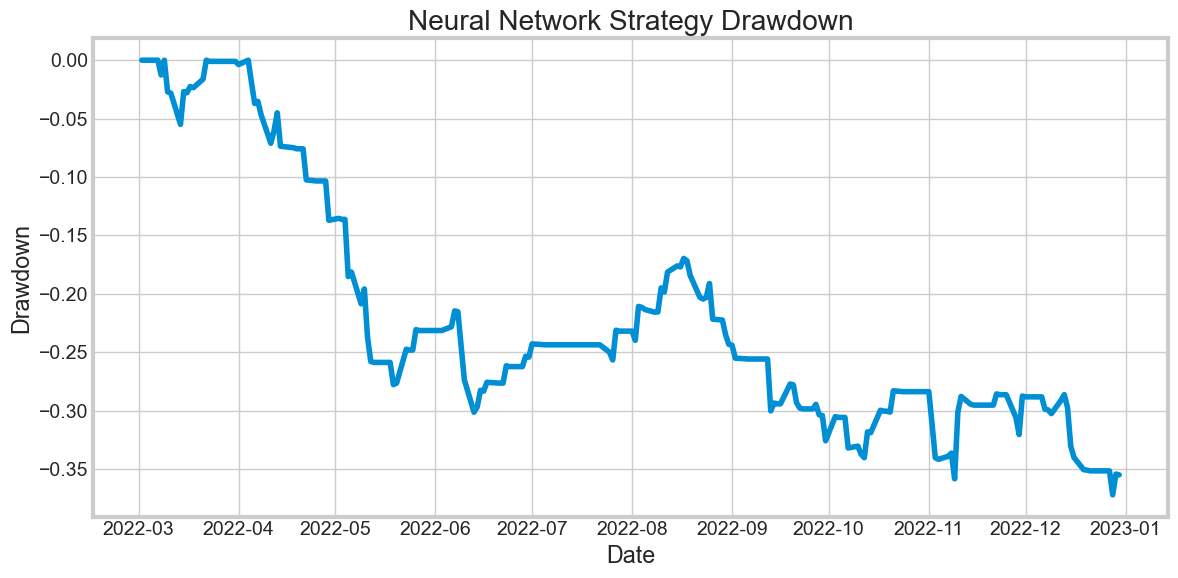


Evaluating Naive Bayes

Evaluating Naive Bayes...
Accuracy: 0.5189
F1 Score: 0.0000
Confusion Matrix:
[[110   0]
 [102   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.68       110
           1       0.00      0.00      0.00       102

    accuracy                           0.52       212
   macro avg       0.26      0.50      0.34       212
weighted avg       0.27      0.52      0.35       212



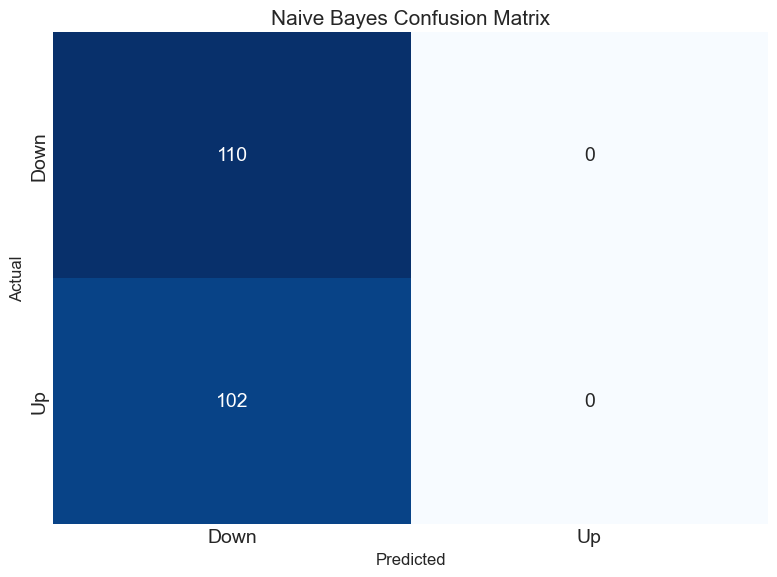


Backtesting Naive Bayes trading strategy...
Total Trading Days: 212
Profitable Days: 0 (0.00%)
Net Return: 0.00%
Buy & Hold Return: -20.03%
Max Drawdown: 0.00%
Annualized Sharpe Ratio: 0.0000


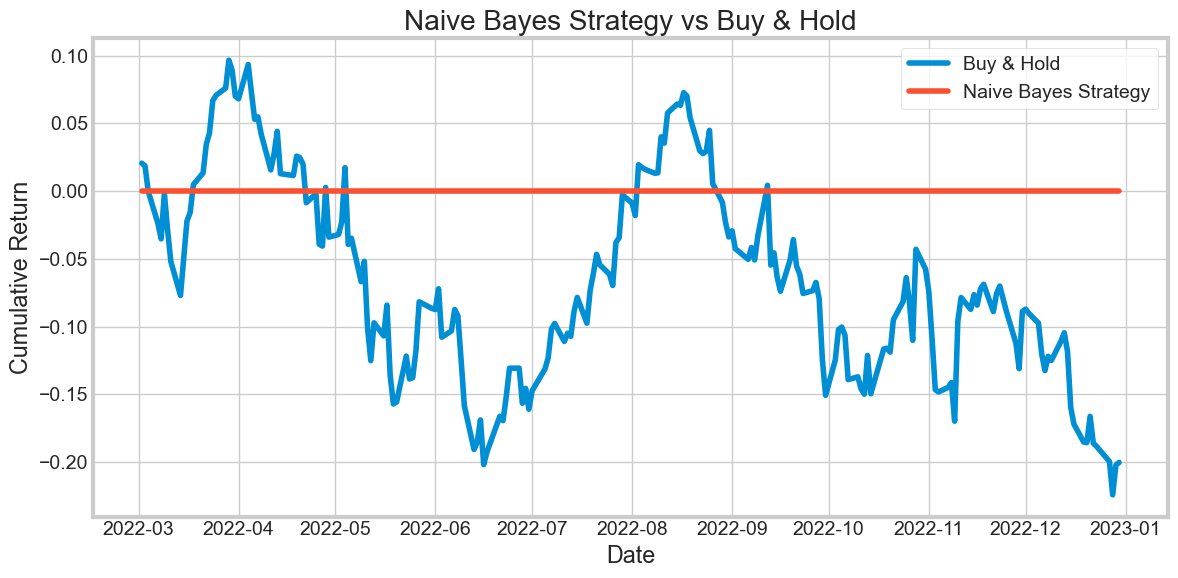

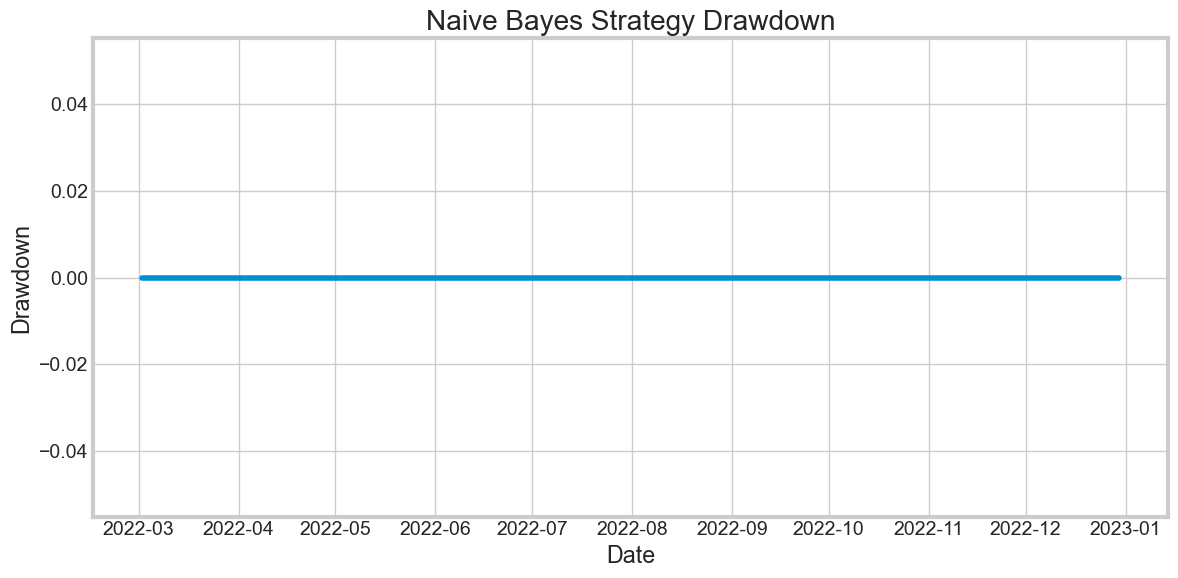


Evaluating Decision Tree

Top 10 Important Features (Decision Tree):
             Feature  Importance
15  Price_Change_Pct      0.2238
8          Return_5d      0.1555
13          BB_Width      0.1425
7          Return_1d      0.1400
9                RSI      0.1193
2              MA_20      0.1042
12         MACD_Hist      0.0937
3              MA_50      0.0210
0               MA_5      0.0000
5             EMA_10      0.0000

Evaluating Decision Tree...
Accuracy: 0.5189
F1 Score: 0.0000
Confusion Matrix:
[[110   0]
 [102   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.68       110
           1       0.00      0.00      0.00       102

    accuracy                           0.52       212
   macro avg       0.26      0.50      0.34       212
weighted avg       0.27      0.52      0.35       212



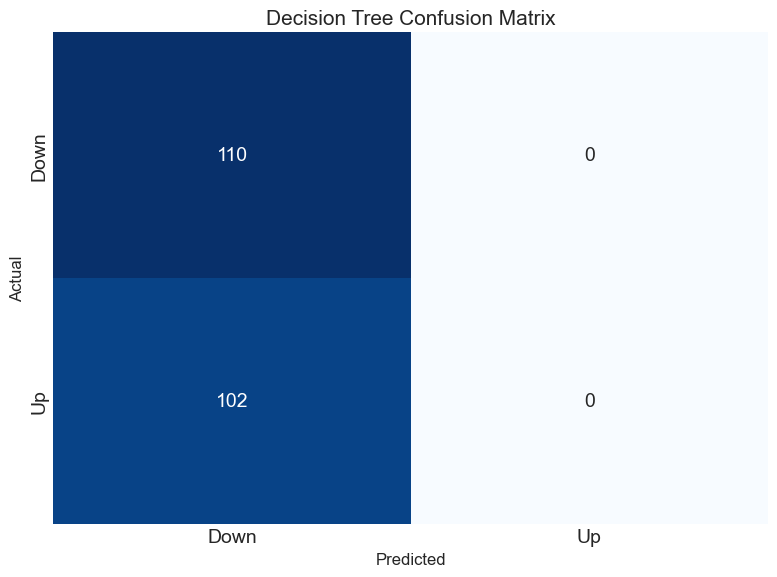


Backtesting Decision Tree trading strategy...
Total Trading Days: 212
Profitable Days: 0 (0.00%)
Net Return: 0.00%
Buy & Hold Return: -20.03%
Max Drawdown: 0.00%
Annualized Sharpe Ratio: 0.0000


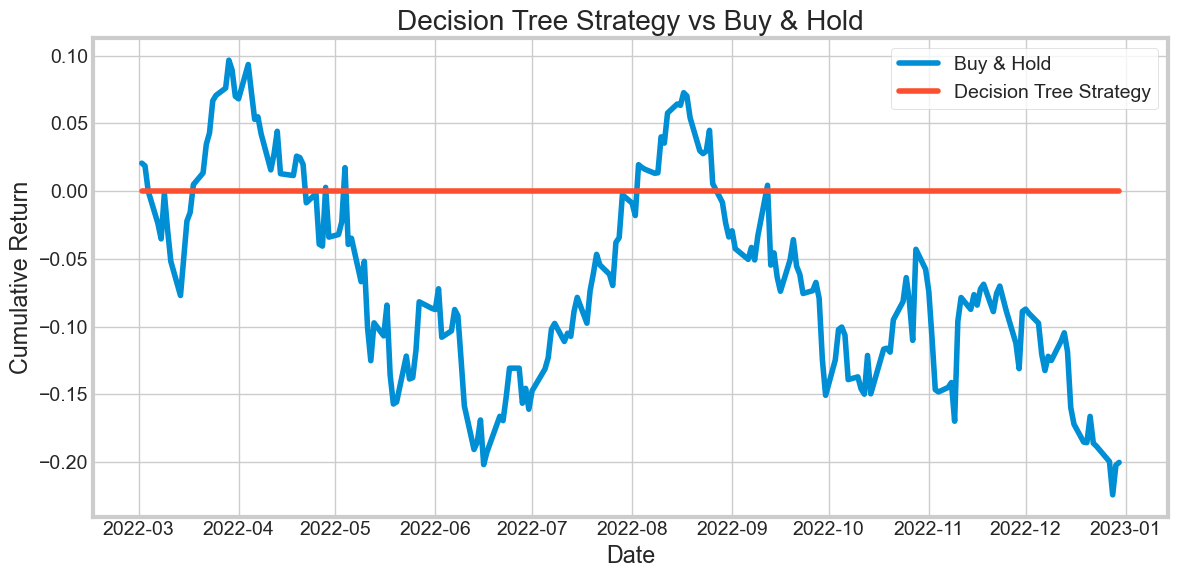

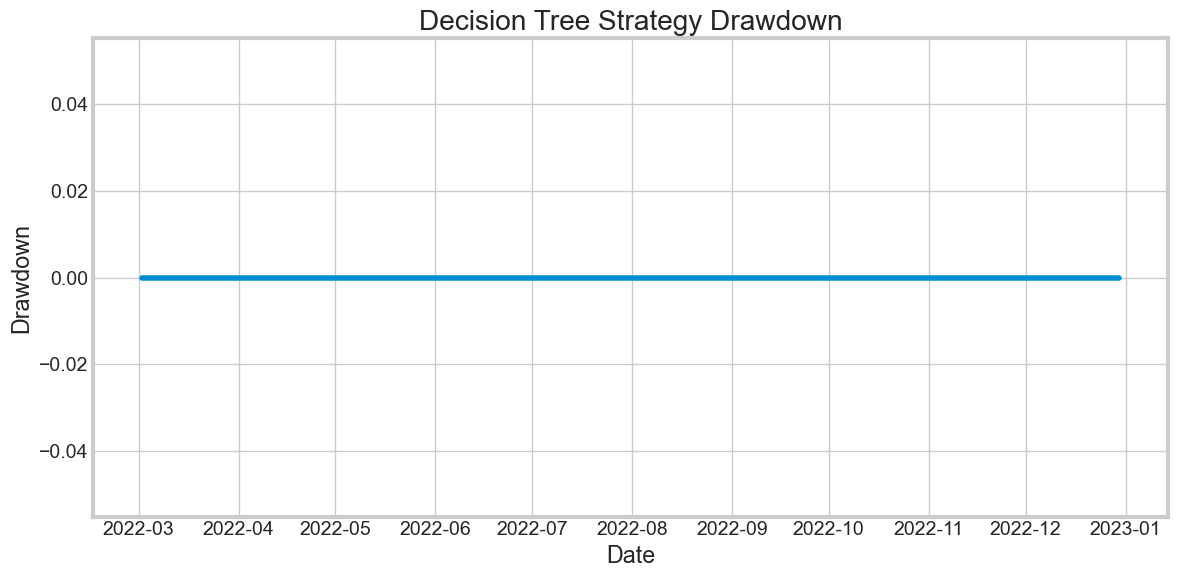


Evaluating AdaBoost

Top 10 Important Features (AdaBoost):
             Feature  Importance
7          Return_1d      0.1908
4              EMA_5      0.1540
9                RSI      0.1071
13          BB_Width      0.1045
12         MACD_Hist      0.1030
3              MA_50      0.0915
16      Volume_Ratio      0.0691
15  Price_Change_Pct      0.0667
14      HL_Range_Pct      0.0407
0               MA_5      0.0358

Evaluating AdaBoost...
Accuracy: 0.5189
F1 Score: 0.5234
Confusion Matrix:
[[54 56]
 [46 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.49      0.51       110
           1       0.50      0.55      0.52       102

    accuracy                           0.52       212
   macro avg       0.52      0.52      0.52       212
weighted avg       0.52      0.52      0.52       212



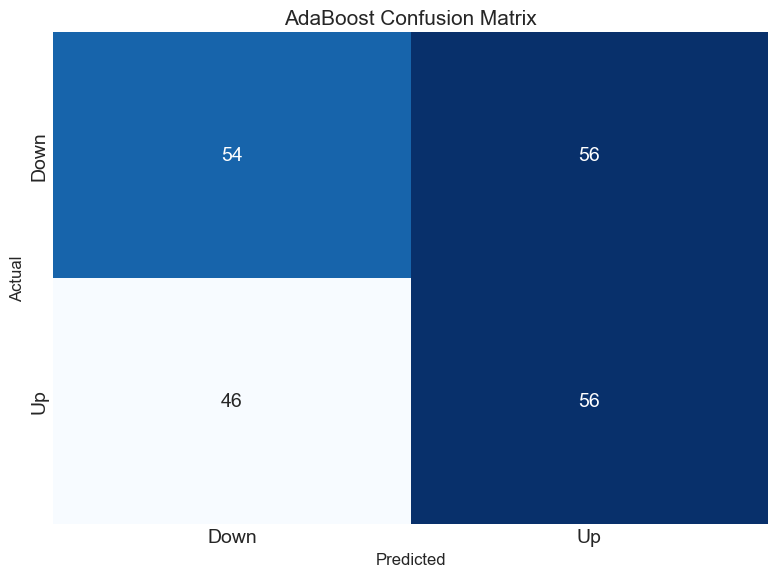


Backtesting AdaBoost trading strategy...
Total Trading Days: 212
Profitable Days: 55 (25.94%)
Net Return: -18.75%
Buy & Hold Return: -20.03%
Max Drawdown: -22.62%
Annualized Sharpe Ratio: -0.7578


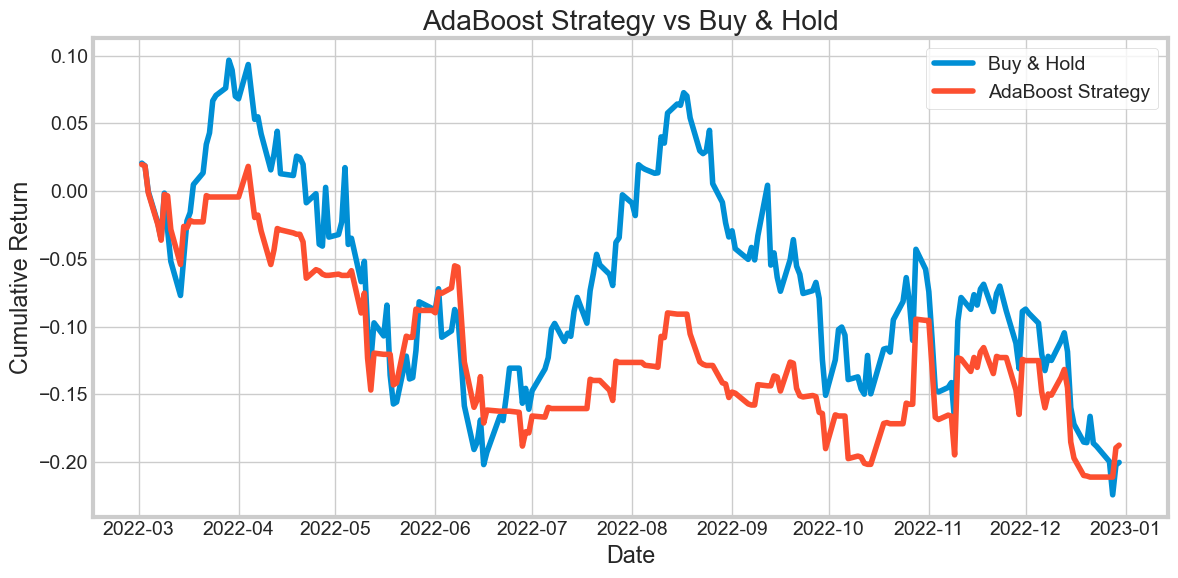

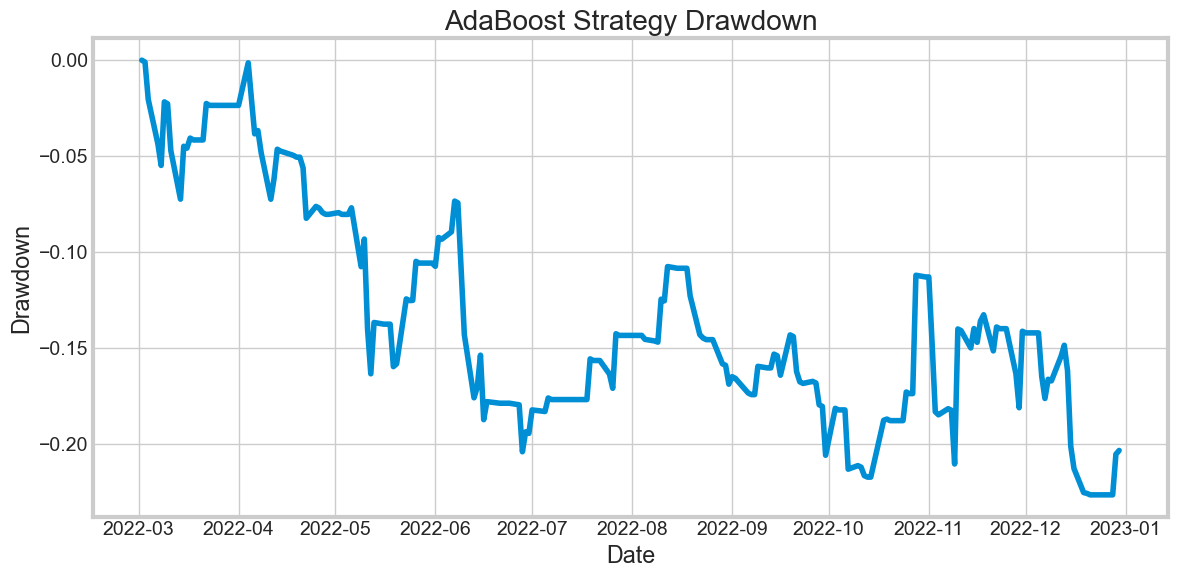


Evaluating Gradient Boosting

Top 10 Important Features (Gradient Boosting):
             Feature  Importance
9                RSI      0.1167
15  Price_Change_Pct      0.1115
13          BB_Width      0.1082
16      Volume_Ratio      0.0986
12         MACD_Hist      0.0810
10              MACD      0.0770
7          Return_1d      0.0751
8          Return_5d      0.0606
3              MA_50      0.0527
14      HL_Range_Pct      0.0467

Evaluating Gradient Boosting...
Accuracy: 0.5236
F1 Score: 0.4767
Confusion Matrix:
[[65 45]
 [56 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.59      0.56       110
           1       0.51      0.45      0.48       102

    accuracy                           0.52       212
   macro avg       0.52      0.52      0.52       212
weighted avg       0.52      0.52      0.52       212



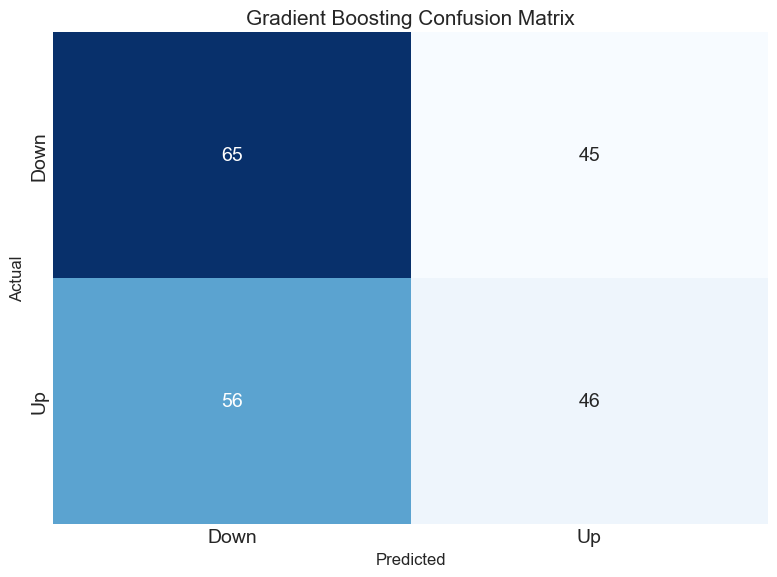


Backtesting Gradient Boosting trading strategy...
Total Trading Days: 212
Profitable Days: 46 (21.70%)
Net Return: -7.95%
Buy & Hold Return: -20.03%
Max Drawdown: -16.53%
Annualized Sharpe Ratio: -0.2461


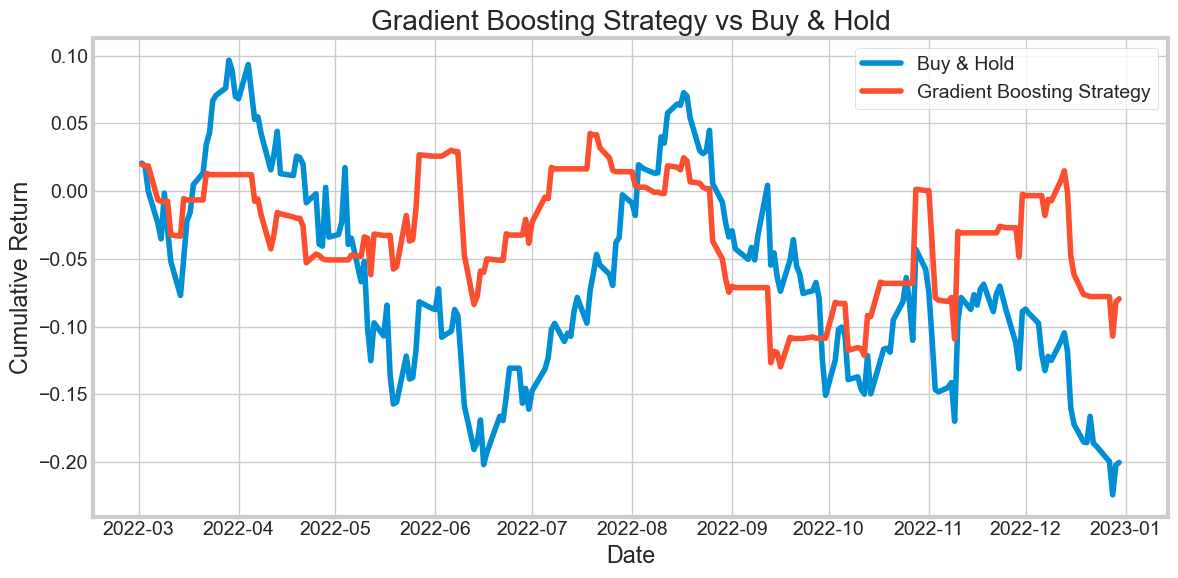

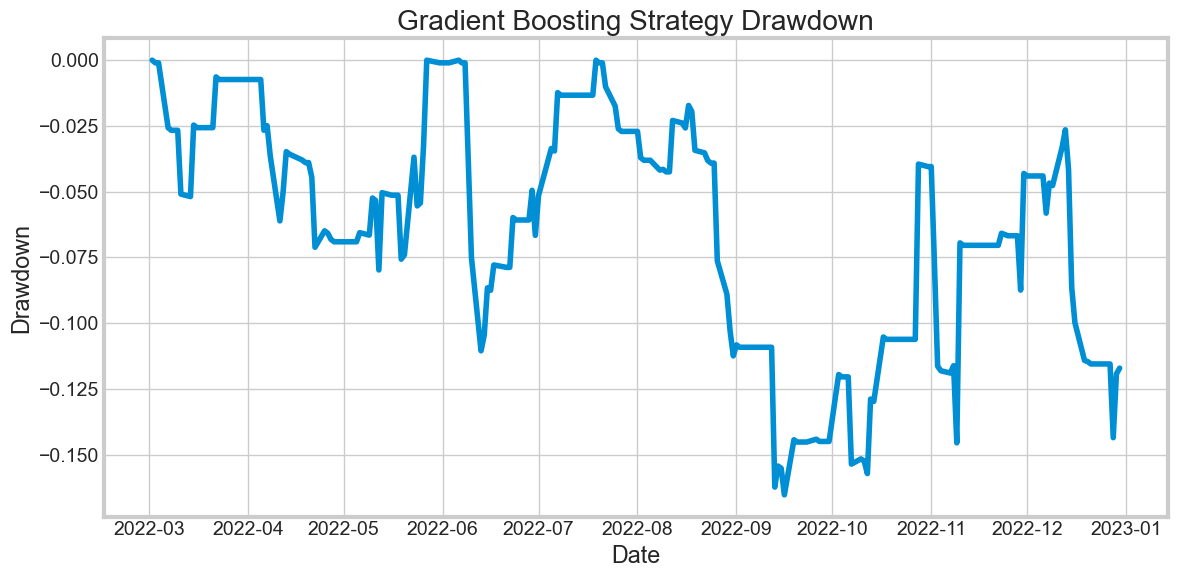


Evaluating XGBoost

Top 10 Important Features (XGBoost):
             Feature  Importance
2              MA_20      0.0784
10              MACD      0.0708
7          Return_1d      0.0667
3              MA_50      0.0643
15  Price_Change_Pct      0.0623
8          Return_5d      0.0618
13          BB_Width      0.0602
16      Volume_Ratio      0.0598
11       MACD_Signal      0.0596
14      HL_Range_Pct      0.0595

Evaluating XGBoost...
Accuracy: 0.5047
F1 Score: 0.4670
Confusion Matrix:
[[61 49]
 [56 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.54       110
           1       0.48      0.45      0.47       102

    accuracy                           0.50       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.50      0.50      0.50       212



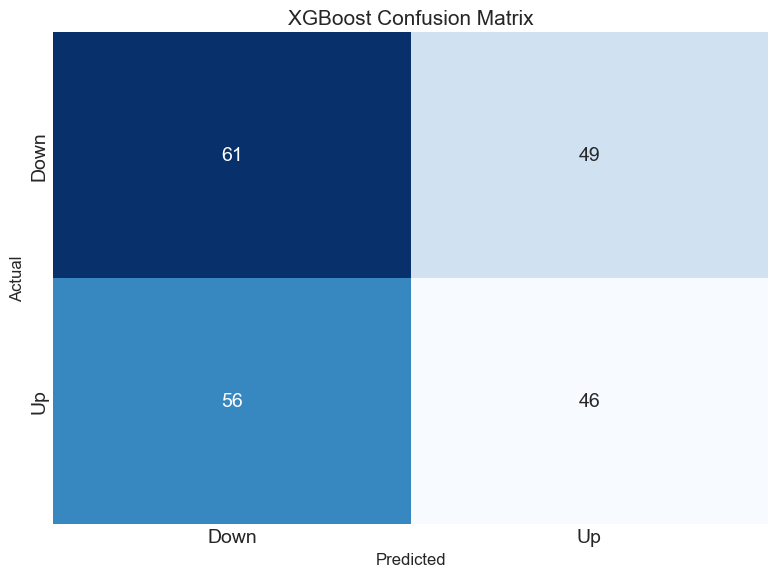


Backtesting XGBoost trading strategy...
Total Trading Days: 212
Profitable Days: 46 (21.70%)
Net Return: -18.54%
Buy & Hold Return: -20.03%
Max Drawdown: -28.28%
Annualized Sharpe Ratio: -0.7845


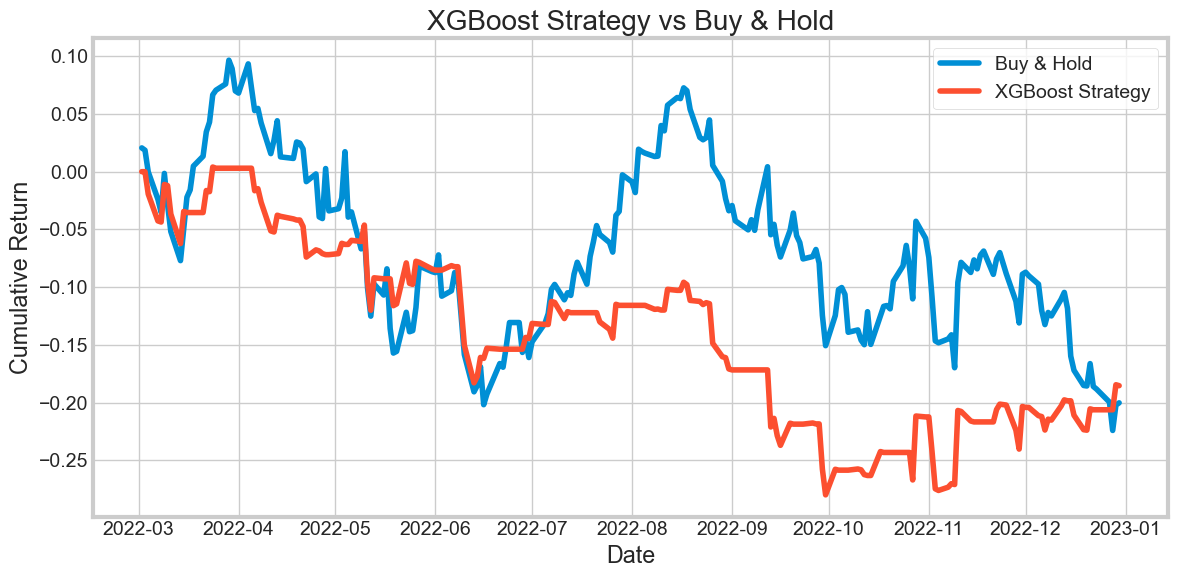

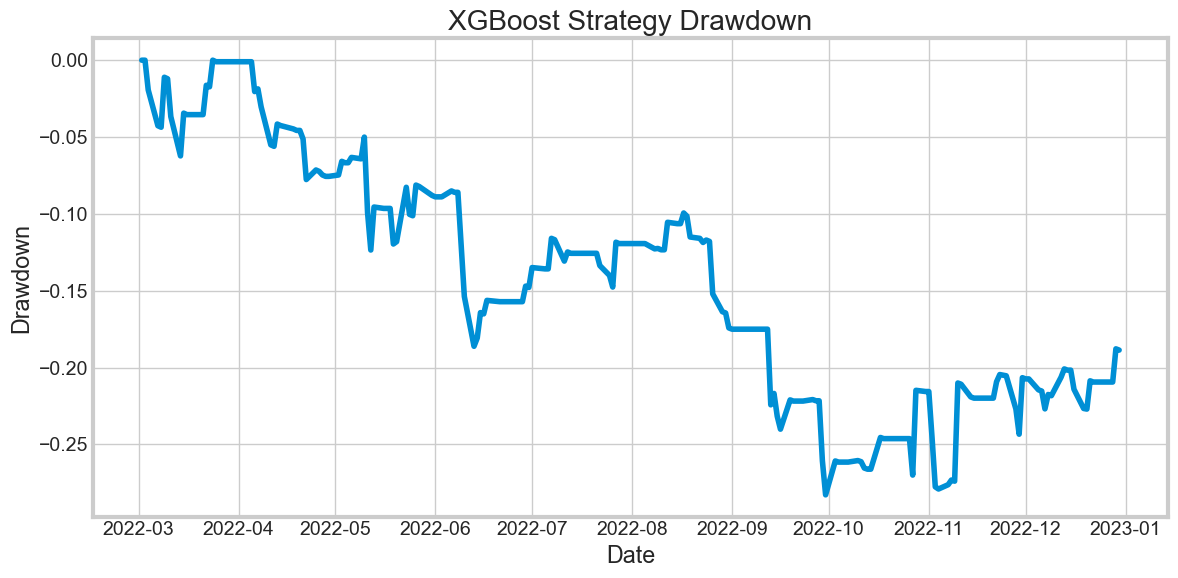

Model Comparison:
                 Model  Accuracy  F1 Score  Net Return  Max Drawdown  \
0  Logistic Regression    0.4811    0.3750     -0.2365       -0.2703   
1        Random Forest    0.5755    0.4767      0.0517       -0.1105   
2                  SVM    0.5330    0.4277     -0.0545       -0.1972   
3                  KNN    0.5047    0.5161     -0.2202       -0.3008   
4       Neural Network    0.4811    0.4811     -0.3249       -0.3721   
5          Naive Bayes    0.5189    0.0000      0.0000        0.0000   
6        Decision Tree    0.5189    0.0000      0.0000        0.0000   
7             AdaBoost    0.5189    0.5234     -0.1875       -0.2262   
8    Gradient Boosting    0.5236    0.4767     -0.0795       -0.1653   
9              XGBoost    0.5047    0.4670     -0.1854       -0.2828   

   Sharpe Ratio  
0       -1.1902  
1        0.3631  
2       -0.1425  
3       -0.9157  
4       -1.5242  
5           NaN  
6           NaN  
7       -0.7578  
8       -0.2461  
9       -

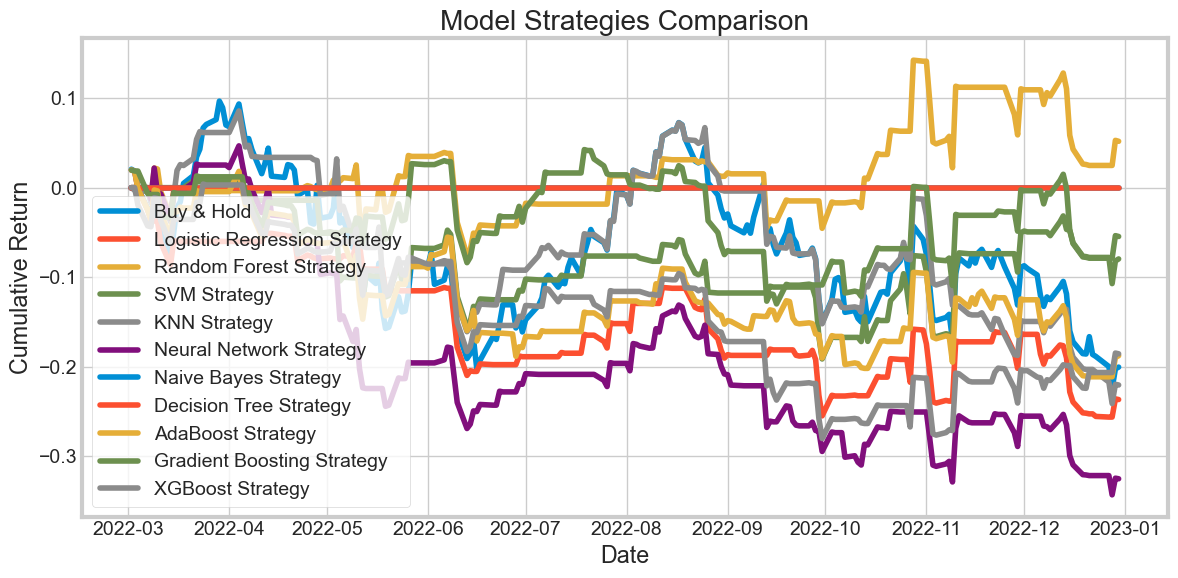


Best performing model based on Sharpe Ratio: Random Forest
Models, scaler, and feature list saved to models
Model performance metrics saved to models/model_performance.json


In [68]:
# Train all models
models = {}

# 1. Logistic Regression
lr_model, lr_feature_importance = train_logistic_regression(X_train, y_train)
models['Logistic Regression'] = {'model': lr_model, 'feature_importance': lr_feature_importance}

# 2. Random Forest
rf_model, rf_feature_importance = train_random_forest(X_train, y_train)
models['Random Forest'] = {'model': rf_model, 'feature_importance': rf_feature_importance}

# 3. SVM
svm_model, svm_feature_importance = train_svm(X_train, y_train)
models['SVM'] = {'model': svm_model, 'feature_importance': svm_feature_importance}

# 4. KNN
knn_model, knn_feature_importance = train_knn(X_train, y_train)
models['KNN'] = {'model': knn_model, 'feature_importance': knn_feature_importance}

# 5. Neural Network
nn_model, nn_feature_importance = train_neural_network(X_train, y_train)
models['Neural Network'] = {'model': nn_model, 'feature_importance': nn_feature_importance}

# 6. Naive Bayes
nb_model, nb_feature_importance = train_naive_bayes(X_train, y_train)
models['Naive Bayes'] = {'model': nb_model, 'feature_importance': nb_feature_importance}

# 7. Decision Tree
dt_model, dt_feature_importance = train_decision_tree(X_train, y_train)
models['Decision Tree'] = {'model': dt_model, 'feature_importance': dt_feature_importance}

# 8. AdaBoost
ada_model, ada_feature_importance = train_adaboost(X_train, y_train)
models['AdaBoost'] = {'model': ada_model, 'feature_importance': ada_feature_importance}

# 9. Gradient Boosting
gb_model, gb_feature_importance = train_gradient_boosting(X_train, y_train)
models['Gradient Boosting'] = {'model': gb_model, 'feature_importance': gb_feature_importance}

# 10. XGBoost
xgb_model, xgb_feature_importance = train_xgboost(X_train, y_train)
models['XGBoost'] = {'model': xgb_model, 'feature_importance': xgb_feature_importance}

# Evaluate all models
results = {}
backtest_results = {}

for name, model_dict in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    
    # Get model
    model = model_dict['model']
    
    # Display top features if available
    feature_importance = model_dict['feature_importance']
    if feature_importance['Importance'].sum() > 0:
        print(f"\nTop 10 Important Features ({name}):")
        print(feature_importance.head(10))
    
    # Evaluate model
    y_pred, y_prob, accuracy, f1, cm = evaluate_model(model, X_test, y_test, name)
    
    # Save evaluation results
    results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'confusion_matrix': cm
    }
    
    # Backtest trading strategy
    backtest_df = backtest_strategy(test_df, y_pred, name, transaction_cost=0.001)
    backtest_results[name] = backtest_df
    
# Prepare data for model comparison
models_info = {}
for name in results.keys():
    models_info[name] = {
        'accuracy': results[name]['accuracy'],
        'f1': results[name]['f1'],
        'backtest_df': backtest_results[name]
    }

# Compare all models
models_comparison = compare_models(models_info)
"""

# Cell: Complete Pipeline with All Models
"""
# Full Pipeline Example with All Models

# 1. Load Stock Data
ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2023-01-01'
df = load_stock_data(ticker, start_date, end_date)

# 2. Clean Data
df_cleaned = clean_data(df)

# 3. Visualize Stock Data
plot_stock_data(df_cleaned, ticker=ticker)

# 4. Feature Engineering
df_features = create_all_features(df_cleaned)

# 5. Visualize Technical Indicators
plot_technical_indicators(df_features, window=250, ticker=ticker)

# 6. Analyze Target Distribution
analyze_target_distribution(df_features)

# 7. Prepare Data for Modeling
selected_features = [
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'EMA_5', 'EMA_10', 'EMA_20',
    'Return_1d', 'Return_5d',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width',
    'HL_Range_Pct', 'Price_Change_Pct',
    'Volume_Ratio'
]

X_train, y_train, X_test, y_test, scaler, test_df, feature_cols = prepare_data(
    df_features, feature_cols=selected_features
)

# 8. Train All Models
models = {}

# 8.1 Logistic Regression
lr_model, lr_feature_importance = train_logistic_regression(X_train, y_train)
models['Logistic Regression'] = {'model': lr_model, 'feature_importance': lr_feature_importance}

# 8.2 Random Forest
rf_model, rf_feature_importance = train_random_forest(X_train, y_train)
models['Random Forest'] = {'model': rf_model, 'feature_importance': rf_feature_importance}

# 8.3 SVM
svm_model, svm_feature_importance = train_svm(X_train, y_train)
models['SVM'] = {'model': svm_model, 'feature_importance': svm_feature_importance}

# 8.4 KNN
knn_model, knn_feature_importance = train_knn(X_train, y_train)
models['KNN'] = {'model': knn_model, 'feature_importance': knn_feature_importance}

# 8.5 Neural Network
nn_model, nn_feature_importance = train_neural_network(X_train, y_train)
models['Neural Network'] = {'model': nn_model, 'feature_importance': nn_feature_importance}

# 8.6 Naive Bayes
nb_model, nb_feature_importance = train_naive_bayes(X_train, y_train)
models['Naive Bayes'] = {'model': nb_model, 'feature_importance': nb_feature_importance}

# 8.7 Decision Tree
dt_model, dt_feature_importance = train_decision_tree(X_train, y_train)
models['Decision Tree'] = {'model': dt_model, 'feature_importance': dt_feature_importance}

# 8.8 AdaBoost
ada_model, ada_feature_importance = train_adaboost(X_train, y_train)
models['AdaBoost'] = {'model': ada_model, 'feature_importance': ada_feature_importance}

# 8.9 Gradient Boosting
gb_model, gb_feature_importance = train_gradient_boosting(X_train, y_train)
models['Gradient Boosting'] = {'model': gb_model, 'feature_importance': gb_feature_importance}

# 8.10 XGBoost
xgb_model, xgb_feature_importance = train_xgboost(X_train, y_train)
models['XGBoost'] = {'model': xgb_model, 'feature_importance': xgb_feature_importance}

# 9. Evaluate All Models
results = {}
backtest_results = {}

for name, model_dict in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    
    # Get model
    model = model_dict['model']
    
    # Display top features if available
    feature_importance = model_dict['feature_importance']
    if feature_importance['Importance'].sum() > 0:
        print(f"\nTop 10 Important Features ({name}):")
        print(feature_importance.head(10))
    
    # Evaluate model
    y_pred, y_prob, accuracy, f1, cm = evaluate_model(model, X_test, y_test, name)
    
    # Save evaluation results
    results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'confusion_matrix': cm
    }
    
    # Backtest trading strategy
    backtest_df = backtest_strategy(test_df, y_pred, name, transaction_cost=0.001)
    backtest_results[name] = backtest_df

# 10. Compare All Models
models_info = {}
for name in results.keys():
    models_info[name] = {
        'accuracy': results[name]['accuracy'],
        'f1': results[name]['f1'],
        'backtest_df': backtest_results[name]
    }

# Compare all models
models_comparison = compare_models(models_info)

# 11. Save Best Models
# Find the best model based on highest Sharpe ratio
best_model_name = models_comparison.sort_values('Sharpe Ratio', ascending=False).iloc[0]['Model']
print(f"\nBest performing model based on Sharpe Ratio: {best_model_name}")

# Save the best model and all others
save_models(
    models['Logistic Regression']['model'],
    models['Random Forest']['model'],
    scaler,
    feature_cols,
    output_dir='models'
)

# Create a JSON file with model performance metrics
import json
performance_metrics = {
    name: {
        'accuracy': float(models_info[name]['accuracy']),
        'f1': float(models_info[name]['f1']),
        'net_return': float(models_info[name]['backtest_df']['Cum_Strategy_Return'].iloc[-1]),
        'max_drawdown': float(models_info[name]['backtest_df']['Drawdown'].min()),
        'sharpe_ratio': float(models_comparison.loc[models_comparison['Model'] == name, 'Sharpe Ratio'].values[0])
    }
    for name in models_info.keys()
}

with open('models/model_performance.json', 'w') as f:
    json.dump(performance_metrics, f, indent=4)

print("Model performance metrics saved to models/model_performance.json")